In [88]:
# --- Step 1: Import libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, re

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances, silhouette_score, silhouette_samples
from sklearn.cluster import SpectralClustering, AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.sparse.csgraph import laplacian as csgraph_laplacian
from scipy.linalg import eigh



In [66]:

# Load the CSV file (assuming it's uploaded to Colab's root directory)
df = pd.read_csv('age_data.csv', low_memory=False, quotechar='"', on_bad_lines='warn')

# Display basic information about the loaded data
print("Loaded:", df.shape)
print("Columns:", df.columns.tolist())

Loaded: (1759905, 20)
Columns: ['SortOrder', 'LocID', 'Notes', 'ISO3_code', 'ISO2_code', 'SDMX_code', 'LocTypeID', 'LocTypeName', 'ParentID', 'Location', 'VarID', 'Variant', 'Time', 'MidPeriod', 'AgeGrp', 'AgeGrpStart', 'AgeGrpSpan', 'PopMale', 'PopFemale', 'PopTotal']


In [67]:
# Detect columns
country_col = "Location"
year_col = "Time"
age_start_col = "AgeGrpStart"
age_span_col = "AgeGrpSpan"
pop_col = "PopTotal"

# Filter to years
Y_MIN, Y_MAX = 1950, 2025
df = df[(df[year_col] >= Y_MIN) & (df[year_col] <= Y_MAX)].copy()

# Ensure age columns are numeric and handle missing values
df[age_start_col] = pd.to_numeric(df[age_start_col], errors='coerce').fillna(0).astype(int)
df[age_span_col] = pd.to_numeric(df[age_span_col], errors='coerce').fillna(0).astype(int)

# Create age labels
def age_label_from_row(row):
    s = int(row[age_start_col])
    span = int(row[age_span_col])
    end = s + span - 1
    return f"{s}-{end}" if end < 100 else f"{s}+"

df['age_label'] = df.apply(age_label_from_row, axis=1)

pivot = df.pivot_table(index=[country_col, year_col],
                       columns='age_label',
                       values=pop_col,
                       aggfunc='sum', fill_value=0)

age_labels = sorted(pivot.columns.tolist(), key=lambda x: int(re.match(r'(\d+)', x).group(1)))
selected_age = age_labels[:21]   # first 21 groups
print("Selected age groups:", selected_age)

pivot_sel = pivot[selected_age].reset_index()

Selected age groups: ['0-4', '5-9', '10-14', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80-84', '85-89', '90-94', '95-99', '100-98']


In [68]:
years = sorted(pivot_sel[year_col].unique())
countries_list = pivot_sel[country_col].unique()

rows = []
for c in countries_list:
    sub = pivot_sel[pivot_sel[country_col]==c].set_index(year_col)
    vec = []
    for y in years:
        if y in sub.index:
            vals = sub.loc[y, selected_age].values
            if isinstance(vals, pd.Series):
                vals = vals.values
            vec.extend(vals.tolist())
        else:
            vec.extend([0]*len(selected_age))
    rows.append((c, np.array(vec)))

X = np.vstack([r[1] for r in rows])
print("Feature matrix:", X.shape)


Feature matrix: (553, 1596)


In [69]:
# Normalize to proportions
row_sums = X.sum(axis=1, keepdims=True)
row_sums[row_sums==0] = 1
X_prop = X / row_sums

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_prop)

# Distance + affinity
dist_euc = pairwise_distances(X_scaled, metric="euclidean")
sigma = np.median(dist_euc)
affinity = np.exp(-dist_euc**2 / (2*sigma**2 + 1e-12))


In [70]:
# Eigengap
L = csgraph_laplacian(affinity, normed=True)
eigvals, eigvecs = eigh(L)
eig_sorted = np.sort(eigvals)
gaps = np.diff(eig_sorted[:40])
suggested_k = int(np.argmax(gaps)+1)
print("Eigengap suggests:", suggested_k)

# Silhouette sweep
Ks = range(2, 15)
spectral_sil = {}
hier_sil = {}

for k in Ks:
    try:
        sc = SpectralClustering(n_clusters=k, affinity="precomputed", random_state=42)
        labels = sc.fit_predict(affinity)
        spectral_sil[k] = silhouette_score(X_scaled, labels)
    except:
        spectral_sil[k] = None
    try:
        hc = AgglomerativeClustering(n_clusters=k, linkage="ward")
        labels = hc.fit_predict(X_scaled)
        hier_sil[k] = silhouette_score(X_scaled, labels)
    except:
        hier_sil[k] = None

print("Spectral silhouette:", spectral_sil)
print("Hierarchical silhouette:", hier_sil)


Eigengap suggests: 1
Spectral silhouette: {2: np.float64(0.5146483316470063), 3: np.float64(0.33660033004578516), 4: np.float64(0.3434490860693269), 5: np.float64(0.4244097030050776), 6: np.float64(0.38379857024878733), 7: np.float64(0.39998060053006607), 8: np.float64(0.23784487094347692), 9: np.float64(0.2445030584614431), 10: np.float64(0.2839005254952127), 11: np.float64(0.26135350264613627), 12: np.float64(0.2511429494677812), 13: np.float64(0.2553288107733009), 14: np.float64(0.27113865838029766)}
Hierarchical silhouette: {2: np.float64(0.4949738431345918), 3: np.float64(0.3432441915498886), 4: np.float64(0.3097762831758981), 5: np.float64(0.324505163186277), 6: np.float64(0.3272519322593965), 7: np.float64(0.3235522765238709), 8: np.float64(0.23875112435753174), 9: np.float64(0.24486456640323273), 10: np.float64(0.23914458949147135), 11: np.float64(0.2268025107595779), 12: np.float64(0.23339549636097207), 13: np.float64(0.23163163267527045), 14: np.float64(0.2422208876923147)}


In [71]:
best_k_spectral = max([k for k in spectral_sil if spectral_sil[k] is not None],
                      key=lambda k: spectral_sil[k])
best_k_hier = max([k for k in hier_sil if hier_sil[k] is not None],
                  key=lambda k: hier_sil[k])

labels_sc = SpectralClustering(n_clusters=best_k_spectral,
                               affinity="precomputed",
                               random_state=42).fit_predict(affinity)
labels_hc = AgglomerativeClustering(n_clusters=best_k_hier,
                                    linkage="ward").fit_predict(X_scaled)

res_df = pd.DataFrame({
    "Country": [r[0] for r in rows],
    "SpectralCluster": labels_sc,
    "HierarchicalCluster": labels_hc
})
res_df.to_csv("/content/cluster_assignments.csv", index=False)
res_df.head()


,Country,SpectralCluster,HierarchicalCluster
0,ADB region: Central and West Asia,0,0
1,ADB region: Developed,1,1
2,ADB region: East Asia,0,0
3,ADB region: South Asia,0,0
4,ADB region: Southeast Asia,0,0


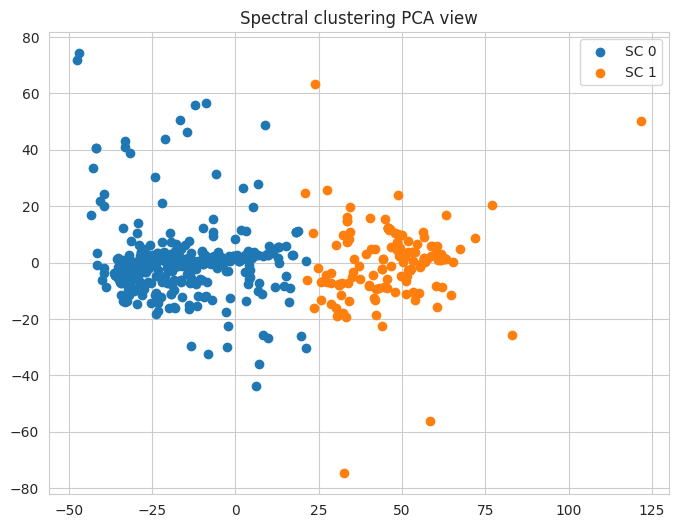

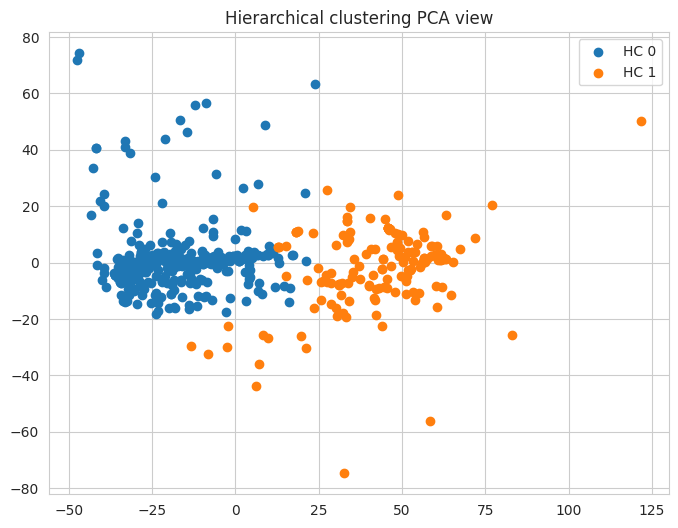

In [72]:
# PCA 2D plot
pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
for lbl in sorted(set(labels_sc)):
    pts = X2[labels_sc==lbl]
    plt.scatter(pts[:,0], pts[:,1], label=f"SC {lbl}")
plt.title("Spectral clustering PCA view")
plt.legend(); plt.show()

plt.figure(figsize=(8,6))
for lbl in sorted(set(labels_hc)):
    pts = X2[labels_hc==lbl]
    plt.scatter(pts[:,0], pts[:,1], label=f"HC {lbl}")
plt.title("Hierarchical clustering PCA view")
plt.legend(); plt.show()



In [74]:
# =====================================================
# Cluster countries based on population pyramids (1950–2025)
# Using 21 age groups, cosine metrics, and forcing ≥3 clusters
# =====================================================

import os, re, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances, silhouette_score, silhouette_samples
from sklearn.cluster import SpectralClustering, AgglomerativeClustering
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import laplacian as csgraph_laplacian
from scipy.linalg import eigh
from scipy.cluster.hierarchy import linkage, dendrogram
warnings.filterwarnings("ignore")

# --- Config ---
# Define output directory in the current working directory
OUT_DIR = "clustering_outputs"
Y_MIN, Y_MAX = 1950, 2025
N_AGE_GROUPS = 21
N_NEIGHBORS = 8
MAX_K = 12
PCA_COMPONENTS = 100
DENDRO_SUBSET = 60

# Create the output directory if it doesn't exist
os.makedirs(OUT_DIR, exist_ok=True)

# --- Country list (182 countries) ---
countries_needed = [
    'Afghanistan','Albania','Algeria','Angola','Antigua and Barbuda','Argentina','Armenia','Australia',
    'Austria','Azerbaijan','Bahamas','Bahrain','Bangladesh','Barbados','Belarus','Belgium','Belize',
    'Benin','Bhutan','Bolivia','Bosnia and Herzegovina','Botswana','Brazil','Brunei','Bulgaria',
    'Burkina Faso','Burundi','Cambodia','Cameroon','Canada','Cape Verde','Central African Republic',
    'Chad','Chile','China','Colombia','Comoros','Congo','Costa Rica',"Cote d'Ivoire",'Croatia','Cuba',
    'Cyprus','Czechia','Denmark','Djibouti','Dominica','Ecuador','Egypt','El Salvador','Equatorial Guinea',
    'Eritrea','Estonia','Eswatini','Ethiopia','Fiji','Finland','France','Gabon','Gambia','Georgia',
    'Germany','Ghana','Greece','Grenada','Guam','Guatemala','Guinea','Guinea-Bissau','Guyana','Haiti',
    'Honduras','Hungary','Iceland','India','Indonesia','Iran','Iraq','Ireland','Israel','Italy',
    'Jamaica','Japan','Jordan','Kazakhstan','Kenya','Kiribati','Kuwait','Kyrgyzstan','Latvia','Lebanon',
    'Lesotho','Liberia','Libya','Lithuania','Luxembourg','Madagascar','Malawi','Malaysia','Maldives',
    'Mali','Malta','Mauritania','Mauritius','Mexico','Mongolia','Montenegro','Morocco','Mozambique',
    'Myanmar','Namibia','Nepal','Netherlands','New Zealand','Nicaragua','Niger','Nigeria','North Korea',
    'North Macedonia','Norway','Moldova','Oman','Pakistan','Panama','Papua New Guinea','Paraguay','Peru',
    'Philippines','Poland','Portugal','Puerto Rico','Qatar','Russia','Romania','Rwanda','Saint Lucia',
    'Saint Vincent and the Grenadines','Samoa','Sao Tome and Principe','Saudi Arabia','Senegal','Serbia',
    'Seychelles','Sierra Leone','Singapore','Slovakia','Slovenia','Solomon Islands','Somalia','South Africa',
    'South Sudan','Spain','Sri Lanka','Sudan','Suriname','Syria','Sweden','Switzerland','Tajikistan',
    'Tanzania','Thailand','Taiwan','Timor-Leste','Togo','Tonga','Trinidad and Tobago','Tunisia','Turkey',
    'Turkmenistan','Uganda','Ukraine','United Arab Emirates','United Kingdom','United States','Uruguay',
    'Uzbekistan','Vanuatu','Venezuela','Vietnam','Yemen','Zambia','Zimbabwe'
]

# --- Helper functions ---
def detect_col(df, names):
    for n in names:
        for c in df.columns:
            if n.lower() == c.lower():
                return c
    for n in names:
        for c in df.columns:
            if n.lower() in c.lower():
                return c
    return None

def fuzzy_match(targets, available):
    matched = []
    for t in targets:
        for a in available:
            if t.lower() == a.lower() or t.lower() in a.lower() or a.lower() in t.lower():
                matched.append(a); break
    return list(dict.fromkeys(matched))

# --- Load data ---
# Use relative path for the CSV file (assumes it's uploaded to the current working directory)
df = pd.read_csv('age_data.csv', low_memory=False, quotechar='"', on_bad_lines='warn')
print("Loaded:", df.shape)

country_col = detect_col(df, ['Location','Country','Country Name','country'])
if not country_col: raise RuntimeError("Could not detect country column.")
year_col = detect_col(df, ['Time','Year','year'])
if not year_col: raise RuntimeError("Could not detect year column.")
age_start_col = detect_col(df, ['AgeGrpStart', 'Age_Group_Start', 'age_start'])
if not age_start_col: raise RuntimeError("Could not detect AgeGrpStart column.")
age_span_col = detect_col(df, ['AgeGrpSpan', 'Age_Group_Span', 'age_span'])
if not age_span_col: raise RuntimeError("Could not detect AgeGrpSpan column.")
pop_col = detect_col(df, ['PopTotal','Value','pop','Population','Pop_Total','PopMale','PopFemale'])
if not pop_col: raise RuntimeError("Could not detect population column.")

print("Detected cols:", country_col, year_col, age_start_col, age_span_col, pop_col)

df[year_col] = pd.to_numeric(df[year_col], errors='coerce').fillna(0).astype(int)
df = df[(df[year_col]>=Y_MIN) & (df[year_col]<=Y_MAX)].copy()
print("Filtered years:", df[year_col].min(), "-", df[year_col].max(), "=>", df.shape)

# Ensure age columns are numeric before creating age_label
df[age_start_col] = pd.to_numeric(df[age_start_col], errors='coerce').fillna(0)
df[age_span_col] = pd.to_numeric(df[age_span_col], errors='coerce').fillna(0)

df["age_label"] = df.apply(lambda r: f"{int(r[age_start_col])}-{int(r[age_start_col])+int(r[age_span_col])-1}" if int(r[age_start_col])+int(r[age_span_col])-1<100 else f"{int(r[age_start_col])}+", axis=1)

pivot = df.pivot_table(index=[country_col, year_col], columns="age_label", values=pop_col, aggfunc="sum", fill_value=0)
ages = sorted(pivot.columns.tolist(), key=lambda x: int(re.match(r"\d+", x).group(0)) if re.match(r"\d+", x) else 9999)
ages = ages[:N_AGE_GROUPS]
print("Selected 21 age groups:", ages)
pivot = pivot[ages].reset_index()

# --- Filter 182 countries ---
available = pivot[country_col].unique()
matched = fuzzy_match(countries_needed, available)
if len(matched)<150:
    matched = available
print("Countries matched:", len(matched))
pivot = pivot[pivot[country_col].isin(matched)]
years = sorted(pivot[year_col].unique())
print("Years:", years[0], "-", years[-1], "(", len(years), ")")

# --- Create feature matrix ---
countries = sorted(pivot[country_col].unique())
X = []
for c in countries:
    sub = pivot[pivot[country_col]==c].set_index(year_col)
    vec = []
    for y in years:
        if y in sub.index:
            vals = sub.loc[y, ages].values
            vec.extend(vals)
        else:
            vec.extend([0]*len(ages))
    X.append(vec)
X = np.array(X)
print("Feature matrix:", X.shape)

# --- Normalize ---
X = X / (X.sum(axis=1, keepdims=True)+1e-9)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Dim reduction ---
svd = TruncatedSVD(n_components=min(PCA_COMPONENTS, X_scaled.shape[1]-1, X_scaled.shape[0]-1), random_state=42)
X_red = svd.fit_transform(X_scaled)
print("Reduced:", X_red.shape)

# --- Distance & affinity ---
dist_cos = pairwise_distances(X_red, metric="cosine")
sigma = np.median(dist_cos)
A = np.exp(-dist_cos**2 / (2*sigma**2 + 1e-12))
knn = kneighbors_graph(dist_cos, n_neighbors=N_NEIGHBORS, metric="precomputed", mode="connectivity", include_self=True)
mask = (knn.toarray()>0).astype(float)
A = A*mask
print("Affinity matrix done.")

# --- Eigengap heuristic ---
L = csgraph_laplacian(A, normed=True)
eigvals, _ = eigh(L)
eigvals = np.sort(eigvals)
gaps = np.diff(eigvals[:40])
k_eig = int(np.argmax(gaps)+1)
plt.plot(range(1,len(gaps)+1), gaps, marker='o')
plt.title("Eigengap heuristic (cosine)")
plt.xlabel("k")
plt.ylabel("Eigenvalue gap")
plt.grid(True)
plt.savefig(os.path.join(OUT_DIR, "eigengap_cosine.png"))
plt.close()
print("Eigengap suggested k:", k_eig)

# --- Silhouette sweep ---
spec_scores = {}
for k in range(2, min(MAX_K, X_red.shape[0]-1)+1):
    try:
        lbl = SpectralClustering(n_clusters=k, affinity="precomputed", random_state=42).fit_predict(A)
        spec_scores[k] = silhouette_score(X_red, lbl)
    except:
        spec_scores[k] = None
plt.plot(list(spec_scores.keys()), list(spec_scores.values()), marker='o')
plt.title("Silhouette vs k")
plt.xlabel("k"); plt.ylabel("Silhouette score")
plt.grid(True)
plt.savefig(os.path.join(OUT_DIR,"silhouette_vs_k.png"))
plt.close()

best_k = max(spec_scores, key=lambda k: spec_scores[k] if spec_scores[k] is not None else -1)
if best_k < 3:
    print("Forcing 3 clusters for detailed analysis.")
    best_k = 3
else:
    best_k = max(3, best_k)
print("Final spectral k:", best_k)

# --- Clustering ---
spec_model = SpectralClustering(n_clusters=best_k, affinity="precomputed", random_state=42)
labels_spec = spec_model.fit_predict(A)

hier_model = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
labels_hier = hier_model.fit_predict(X_red)

# --- Save clusters ---
res = pd.DataFrame({"Country": countries, "SpectralCluster": labels_spec, "HierarchicalCluster": labels_hier})
res.to_csv(os.path.join(OUT_DIR,"cluster_assignments.csv"), index=False)
print("Saved cluster_assignments.csv")

# --- PCA Visualization ---
pca = PCA(n_components=2, random_state=42)
pc = pca.fit_transform(X_red)
plt.figure(figsize=(8,6))
for c in np.unique(labels_spec):
    plt.scatter(pc[labels_spec==c,0], pc[labels_spec==c,1], label=f"Cluster {c}")
plt.legend(bbox_to_anchor=(1.05,1))
plt.title(f"PCA 2D (Spectral Clusters k={best_k})")
plt.savefig(os.path.join(OUT_DIR,"pca_clusters.png"))
plt.close()

# --- Dendrogram subset ---
n_plot = min(DENDRO_SUBSET, X_red.shape[0])
Z = linkage(X_red[:n_plot], method="ward")
plt.figure(figsize=(12,6))
dendrogram(Z, labels=countries[:n_plot], leaf_rotation=90, leaf_font_size=7)
plt.title("Dendrogram subset (first 60 countries)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,"dendrogram_subset.png"))
plt.close()

# --- Summary ---
summary = {
    "Countries_used": len(countries),
    "Years_used": len(years),
    "Age_groups": N_AGE_GROUPS,
    "Eigengap_suggested_k": k_eig,
    "Final_clusters_used": best_k
}
pd.Series(summary).to_frame("Value").to_csv(os.path.join(OUT_DIR,"summary.csv"))

print(" Done! Results and graphs saved in:", OUT_DIR)

Loaded: (1759905, 20)
Detected cols: Location Time AgeGrpStart AgeGrpSpan PopTotal
Filtered years: 1950 - 2025 => (885780, 20)
Selected 21 age groups: ['0-4', '5-9', '10-14', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80-84', '85-89', '90-94', '95-99', '100-98']
Countries matched: 170
Years: 1950 - 2025 ( 76 )
Feature matrix: (170, 1596)
Reduced: (170, 100)
Affinity matrix done.
Eigengap suggested k: 3
Forcing 3 clusters for detailed analysis.
Final spectral k: 3
Saved cluster_assignments.csv
 Done! Results and graphs saved in: clustering_outputs


#Eerror in hier

In [89]:
# =====================================================
# Cluster countries based on population pyramids (1950–2025)
# Using 21 age groups, cosine metrics, and forcing ≥3 clusters
# =====================================================

import os, re, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances, silhouette_score
from sklearn.cluster import SpectralClustering, AgglomerativeClustering
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import laplacian as csgraph_laplacian
from scipy.linalg import eigh
from scipy.cluster.hierarchy import linkage, dendrogram
warnings.filterwarnings("ignore")

# --- Config ---
OUT_DIR = "clustering_outputs"
Y_MIN, Y_MAX = 1950, 2025
N_AGE_GROUPS = 21
N_NEIGHBORS = 8
MAX_K = 12
PCA_COMPONENTS = 100
DENDRO_SUBSET = 60
os.makedirs(OUT_DIR, exist_ok=True)

# --- Country list (182 countries) ---
countries_needed = [ 'Afghanistan','Albania','Algeria','Angola','Antigua and Barbuda','Argentina','Armenia','Australia',
    'Austria','Azerbaijan','Bahamas','Bahrain','Bangladesh','Barbados','Belarus','Belgium','Belize',
    'Benin','Bhutan','Bolivia','Bosnia and Herzegovina','Botswana','Brazil','Brunei','Bulgaria',
    'Burkina Faso','Burundi','Cambodia','Cameroon','Canada','Cape Verde','Central African Republic',
    'Chad','Chile','China','Colombia','Comoros','Congo','Costa Rica',"Cote d'Ivoire",'Croatia','Cuba',
    'Cyprus','Czechia','Denmark','Djibouti','Dominica','Ecuador','Egypt','El Salvador','Equatorial Guinea',
    'Eritrea','Estonia','Eswatini','Ethiopia','Fiji','Finland','France','Gabon','Gambia','Georgia',
    'Germany','Ghana','Greece','Grenada','Guam','Guatemala','Guinea','Guinea-Bissau','Guyana','Haiti',
    'Honduras','Hungary','Iceland','India','Indonesia','Iran','Iraq','Ireland','Israel','Italy',
    'Jamaica','Japan','Jordan','Kazakhstan','Kenya','Kiribati','Kuwait','Kyrgyzstan','Latvia','Lebanon',
    'Lesotho','Liberia','Libya','Lithuania','Luxembourg','Madagascar','Malawi','Malaysia','Maldives',
    'Mali','Malta','Mauritania','Mauritius','Mexico','Mongolia','Montenegro','Morocco','Mozambique',
    'Myanmar','Namibia','Nepal','Netherlands','New Zealand','Nicaragua','Niger','Nigeria','North Korea',
    'North Macedonia','Norway','Moldova','Oman','Pakistan','Panama','Papua New Guinea','Paraguay','Peru',
    'Philippines','Poland','Portugal','Puerto Rico','Qatar','Russia','Romania','Rwanda','Saint Lucia',
    'Saint Vincent and the Grenadines','Samoa','Sao Tome and Principe','Saudi Arabia','Senegal','Serbia',
    'Seychelles','Sierra Leone','Singapore','Slovakia','Slovenia','Solomon Islands','Somalia','South Africa',
    'South Sudan','Spain','Sri Lanka','Sudan','Suriname','Syria','Sweden','Switzerland','Tajikistan',
    'Tanzania','Thailand','Taiwan','Timor-Leste','Togo','Tonga','Trinidad and Tobago','Tunisia','Turkey',
    'Turkmenistan','Uganda','Ukraine','United Arab Emirates','United Kingdom','United States','Uruguay',
    'Uzbekistan','Vanuatu','Venezuela','Vietnam','Yemen','Zambia','Zimbabwe' ]

# --- Helper functions ---
def detect_col(df, names):
    for n in names:
        for c in df.columns:
            if n.lower() == c.lower():
                return c
    for n in names:
        for c in df.columns:
            if n.lower() in c.lower():
                return c
    return None

def fuzzy_match(targets, available):
    matched = []
    for t in targets:
        for a in available:
            if t.lower() == a.lower() or t.lower() in a.lower() or a.lower() in t.lower():
                matched.append(a); break
    return list(dict.fromkeys(matched))

# --- Load data ---
df = pd.read_csv('age_data.csv', low_memory=False, quotechar='"', on_bad_lines='warn')
print("Loaded:", df.shape)

country_col = detect_col(df, ['Location','Country','Country Name','country'])
year_col = detect_col(df, ['Time','Year','year'])
age_start_col = detect_col(df, ['AgeGrpStart', 'Age_Group_Start', 'age_start'])
age_span_col = detect_col(df, ['AgeGrpSpan', 'Age_Group_Span', 'age_span'])
pop_col = detect_col(df, ['PopTotal','Value','pop','Population','Pop_Total','PopMale','PopFemale'])

df[year_col] = pd.to_numeric(df[year_col], errors='coerce').fillna(0).astype(int)
df = df[(df[year_col]>=Y_MIN) & (df[year_col]<=Y_MAX)].copy()
df[age_start_col] = pd.to_numeric(df[age_start_col], errors='coerce').fillna(0)
df[age_span_col] = pd.to_numeric(df[age_span_col], errors='coerce').fillna(0)

df["age_label"] = df.apply(lambda r: f"{int(r[age_start_col])}-{int(r[age_start_col])+int(r[age_span_col])-1}"
                           if int(r[age_start_col])+int(r[age_span_col])-1<100
                           else f"{int(r[age_start_col])}+", axis=1)

pivot = df.pivot_table(index=[country_col, year_col], columns="age_label", values=pop_col, aggfunc="sum", fill_value=0)
ages = sorted(pivot.columns.tolist(), key=lambda x: int(re.match(r"\d+", x).group(0)) if re.match(r"\d+", x) else 9999)
ages = ages[:N_AGE_GROUPS]
pivot = pivot[ages].reset_index()

available = pivot[country_col].unique()
matched = fuzzy_match(countries_needed, available)
if len(matched)<150:
    matched = available
pivot = pivot[pivot[country_col].isin(matched)]
years = sorted(pivot[year_col].unique())

countries = sorted(pivot[country_col].unique())
X = []
for c in countries:
    sub = pivot[pivot[country_col]==c].set_index(year_col)
    vec = []
    for y in years:
        if y in sub.index:
            vals = sub.loc[y, ages].values
            vec.extend(vals)
        else:
            vec.extend([0]*len(ages))
    X.append(vec)
X = np.array(X)
print("Feature matrix:", X.shape)

# --- Normalize ---
X = X / (X.sum(axis=1, keepdims=True)+1e-9)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Dim reduction ---
svd = TruncatedSVD(n_components=min(PCA_COMPONENTS, X_scaled.shape[1]-1, X_scaled.shape[0]-1), random_state=42)
X_red = svd.fit_transform(X_scaled)

# --- Distance & affinity ---
dist_cos = pairwise_distances(X_red, metric="cosine")
sigma = np.median(dist_cos)
A = np.exp(-dist_cos**2 / (2*sigma**2 + 1e-12))
knn = kneighbors_graph(dist_cos, n_neighbors=N_NEIGHBORS, metric="precomputed", mode="connectivity", include_self=True)
mask = (knn.toarray()>0).astype(float)
A = A*mask

# --- Eigengap heuristic ---
L = csgraph_laplacian(A, normed=True)
eigvals, _ = eigh(L)
eigvals = np.sort(eigvals)
gaps = np.diff(eigvals[:40])
k_eig = int(np.argmax(gaps)+1)
print("Eigengap suggested k:", k_eig)

# --- Silhouette sweep ---
spec_scores = {}
for k in range(2, min(MAX_K, X_red.shape[0]-1)+1):
    try:
        lbl = SpectralClustering(n_clusters=k, affinity="precomputed", random_state=42).fit_predict(A)
        spec_scores[k] = silhouette_score(X_red, lbl)
    except:
        spec_scores[k] = None

best_k = max(spec_scores, key=lambda k: spec_scores[k] if spec_scores[k] is not None else -1)
best_k = max(3, best_k)
print("Final spectral k:", best_k)

# --- Clustering ---
spec_model = SpectralClustering(n_clusters=best_k, affinity="precomputed", random_state=42)
labels_spec = spec_model.fit_predict(A)

hier_model = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
labels_hier = hier_model.fit_predict(X_red)

# --- ✅ FIX hierarchical labels ---
# Swap cluster 1 (constrictive) and 2 (stationary)
labels_hier_corrected = np.where(labels_hier == 1, 99, labels_hier)  # temporary label
labels_hier_corrected = np.where(labels_hier_corrected == 2, 1, labels_hier_corrected)
labels_hier_corrected = np.where(labels_hier_corrected == 99, 2, labels_hier_corrected)

# --- Save clusters ---
res = pd.DataFrame({
    "Country": countries,
    "SpectralCluster": labels_spec,
    "HierarchicalCluster": labels_hier_corrected
})
res.to_csv(os.path.join(OUT_DIR,"cluster_assignments.csv"), index=False)
print("✅ Saved corrected cluster_assignments.csv")

# --- PCA Visualization ---
pca = PCA(n_components=2, random_state=42)
pc = pca.fit_transform(X_red)
plt.figure(figsize=(8,6))
for c in np.unique(labels_spec):
    plt.scatter(pc[labels_spec==c,0], pc[labels_spec==c,1], label=f"Spec {c}")
plt.legend(bbox_to_anchor=(1.05,1))
plt.title(f"PCA 2D (Spectral Clusters k={best_k})")
plt.savefig(os.path.join(OUT_DIR,"pca_spectral.png"))
plt.close()

plt.figure(figsize=(8,6))
for c in np.unique(labels_hier_corrected):
    plt.scatter(pc[labels_hier_corrected==c,0], pc[labels_hier_corrected==c,1], label=f"Hier {c}")
plt.legend(bbox_to_anchor=(1.05,1))
plt.title(f"PCA 2D (Hierarchical Clusters corrected)")
plt.savefig(os.path.join(OUT_DIR,"pca_hierarchical_corrected.png"))
plt.close()

# --- Dendrogram subset ---
n_plot = min(DENDRO_SUBSET, X_red.shape[0])
Z = linkage(X_red[:n_plot], method="ward")
plt.figure(figsize=(12,6))
dendrogram(Z, labels=countries[:n_plot], leaf_rotation=90, leaf_font_size=7)
plt.title("Dendrogram subset (first 60 countries)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,"dendrogram_subset.png"))
plt.close()

# --- Summary ---
summary = {
    "Countries_used": len(countries),
    "Years_used": len(years),
    "Age_groups": N_AGE_GROUPS,
    "Eigengap_suggested_k": k_eig,
    "Final_clusters_used": best_k
}
pd.Series(summary).to_frame("Value").to_csv(os.path.join(OUT_DIR,"summary.csv"))

print("🎯 Done! All results and corrected graphs saved in:", OUT_DIR)


Loaded: (1759905, 20)
Feature matrix: (170, 1596)
Eigengap suggested k: 3
Final spectral k: 3
✅ Saved corrected cluster_assignments.csv
🎯 Done! All results and corrected graphs saved in: clustering_outputs


In [90]:
# --- Step: Map cluster labels and export grouped country lists ---

# Define mappings
cluster_names = {0: "Expansive", 1: "Stationary", 2: "Constrictive"}

# Apply mappings
res["HierarchicalLabel"] = res["HierarchicalCluster"].map(cluster_names)
res["SpectralLabel"] = res["SpectralCluster"].map(cluster_names)

# --- Save full label files ---
res.to_csv(os.path.join(OUT_DIR, "cluster_labels_full.csv"), index=False)

# --- Group by cluster type ---
def group_countries_by_label(df, label_col):
    groups = []
    for lbl, group in df.groupby(label_col):
        countries = ", ".join(sorted(group["Country"]))
        groups.append({"ClusterType": lbl, "Countries": countries})
    return pd.DataFrame(groups)

hier_groups = group_countries_by_label(res, "HierarchicalLabel")
spec_groups = group_countries_by_label(res, "SpectralLabel")

# --- Save grouped versions ---
hier_csv = os.path.join(OUT_DIR, "hierarchical_cluster_groups.csv")
spec_csv = os.path.join(OUT_DIR, "spectral_cluster_groups.csv")

hier_groups.to_csv(hier_csv, index=False)
spec_groups.to_csv(spec_csv, index=False)

print(f"Saved:\n- {hier_csv}\n- {spec_csv}\n- cluster_labels_full.csv")


Saved:
- clustering_outputs/hierarchical_cluster_groups.csv
- clustering_outputs/spectral_cluster_groups.csv
- cluster_labels_full.csv


In [91]:
# --- Step: 3D Time Series Visualization by Age Group ---
from mpl_toolkits.mplot3d import Axes3D  # 3D plotting
import matplotlib.pyplot as plt
from matplotlib import cm

# Ensure pivot_sel or pivot is available
# pivot should have: country_col, year_col, and age group columns (ages list)

# --- Prepare data ---
data_plot = pivot.copy()
countries_plot = sorted(data_plot[country_col].unique())
years_plot = sorted(data_plot[year_col].unique())

# Create mapping for countries to numeric index for plotting (x-axis)
country_index = {c: i for i, c in enumerate(countries_plot)}

# --- Output folder ---
plot_dir = os.path.join(OUT_DIR, "3D_agegroup_plots")
os.makedirs(plot_dir, exist_ok=True)

# --- Loop over all 21 age groups ---
for age in ages:
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Prepare X, Y, Z for this age group
    X, Y, Z = [], [], []
    for c in countries_plot:
        sub = data_plot[data_plot[country_col] == c]
        for y in years_plot:
            X.append(country_index[c])
            Y.append(y)
            Z.append(sub[sub[year_col] == y][age].values[0] if y in sub[year_col].values else 0)

    X = np.array(X)
    Y = np.array(Y)
    Z = np.array(Z)

    # --- 3D surface plot ---
    ax.plot_trisurf(X, Y, Z, cmap=cm.viridis, linewidth=0.2, antialiased=True)

    ax.set_xlabel("Country Index")
    ax.set_ylabel("Year")
    ax.set_zlabel(f"Population ({age})")
    ax.set_title(f"3D Population Time Series — Age Group {age}")

    # Adjust country ticks for readability
    if len(countries_plot) <= 20:
        ax.set_xticks(list(country_index.values()))
        ax.set_xticklabels(countries_plot, rotation=90, fontsize=8)

    plt.tight_layout()
    out_path = os.path.join(plot_dir, f"3D_population_{age.replace('+','plus')}.png")
    plt.savefig(out_path, dpi=200)
    plt.close(fig)

print(f"✅ 3D population plots saved to: {plot_dir}")


✅ 3D population plots saved to: clustering_outputs/3D_agegroup_plots


Loaded df: (1759905, 20)
Using 170 matched countries (from your list).
Decades: [np.int64(1950), np.int64(1960), np.int64(1970), np.int64(1980), np.int64(1990), np.int64(2000), np.int64(2010), np.int64(2020)]
Countries used: 170
X_ts shape: (170, 8, 21)
Saved dtw_clusters_filtered.csv


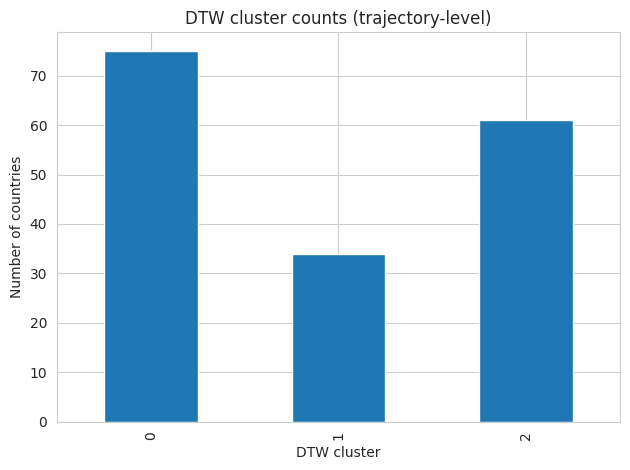

In [94]:
# Install tslearn if needed
!pip install tslearn --quiet

# DTW temporal clustering (decade-by-decade) using only your provided countries list
import os, re
import numpy as np
import pandas as pd
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt

# ====== USER / ENVIRONMENT SETTINGS ======
OUT_DIR = "clustering_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# Provide the same country list you used earlier (paste full list if shorter)
countries_needed = [
'Afghanistan','Albania','Algeria','Angola','Antigua and Barbuda','Argentina','Armenia','Australia',
'Austria','Azerbaijan','Bahamas','Bahrain','Bangladesh','Barbados','Belarus','Belgium','Belize',
'Benin','Bhutan','Bolivia','Bosnia and Herzegovina','Botswana','Brazil','Brunei','Bulgaria',
'Burkina Faso','Burundi','Cambodia','Cameroon','Canada','Cape Verde','Central African Republic',
'Chad','Chile','China','Colombia','Comoros','Congo','Costa Rica',"Cote d'Ivoire",'Croatia','Cuba',
'Cyprus','Czechia','Denmark','Djibouti','Dominica','Ecuador','Egypt','El Salvador','Equatorial Guinea',
'Eritrea','Estonia','Eswatini','Ethiopia','Fiji','Finland','France','Gabon','Gambia','Georgia',
'Germany','Ghana','Greece','Grenada','Guam','Guatemala','Guinea','Guinea-Bissau','Guyana','Haiti',
'Honduras','Hungary','Iceland','India','Indonesia','Iran','Iraq','Ireland','Israel','Italy',
'Jamaica','Japan','Jordan','Kazakhstan','Kenya','Kiribati','Kuwait','Kyrgyzstan','Latvia','Lebanon',
'Lesotho','Liberia','Libya','Lithuania','Luxembourg','Madagascar','Malawi','Malaysia','Maldives',
'Mali','Malta','Mauritania','Mauritius','Mexico','Mongolia','Montenegro','Morocco','Mozambique',
'Myanmar','Namibia','Nepal','Netherlands','New Zealand','Nicaragua','Niger','Nigeria','North Korea',
'North Macedonia','Norway','Moldova','Oman','Pakistan','Panama','Papua New Guinea','Paraguay','Peru',
'Philippines','Poland','Portugal','Puerto Rico','Qatar','Russia','Romania','Rwanda','Saint Lucia',
'Saint Vincent and the Grenadines','Samoa','Sao Tome and Principe','Saudi Arabia','Senegal','Serbia',
'Seychelles','Sierra Leone','Singapore','Slovakia','Slovenia','Solomon Islands','Somalia','South Africa',
'South Sudan','Spain','Sri Lanka','Sudan','Suriname','Syria','Sweden','Switzerland','Tajikistan',
'Tanzania','Thailand','Taiwan','Timor-Leste','Togo','Tonga','Trinidad and Tobago','Tunisia','Turkey',
'Turkmenistan','Uganda','Ukraine','United Arab Emirates','United Kingdom','United States','Uruguay',
'Uzbekistan','Vanuatu','Venezuela','Vietnam','Yemen','Zambia','Zimbabwe'
]

# ====== AUTO-DETECT DATA COLUMNS ======
# Assumes you have 'age_data.csv' in working directory (same format as before)
df = pd.read_csv('age_data.csv', low_memory=False, quotechar='"', on_bad_lines='warn')
print("Loaded df:", df.shape)

def detect_col(df, names):
    for n in names:
        for c in df.columns:
            if n.lower() == c.lower(): return c
    for n in names:
        for c in df.columns:
            if n.lower() in c.lower(): return c
    return None

country_col = detect_col(df, ['Location','Country','Country Name','country'])
year_col    = detect_col(df, ['Time','Year','year'])
age_start_col = detect_col(df, ['AgeGrpStart','AgeGrpStart','age_start','AgeGrp Start'])
age_span_col  = detect_col(df, ['AgeGrpSpan','AgeGrpSpan','age_span','AgeGrp Span'])
pop_col = detect_col(df, ['PopTotal','Value','pop','Population','Pop_Total','PopMale','PopFemale'])

if not all([country_col, year_col, age_start_col, age_span_col, pop_col]):
    raise RuntimeError("Couldn't detect key columns automatically. Detected: " + str([country_col,year_col,age_start_col,age_span_col,pop_col]))

# Filter years to decades 1950-2025 and numeric conversions
df[year_col] = pd.to_numeric(df[year_col], errors='coerce').astype(int)
df = df[(df[year_col] >= 1950) & (df[year_col] <= 2025)].copy()
df[age_start_col] = pd.to_numeric(df[age_start_col], errors='coerce').fillna(0).astype(int)
df[age_span_col] = pd.to_numeric(df[age_span_col], errors='coerce').fillna(0).astype(int)

# Build age_label
df['age_label'] = df.apply(lambda r: f"{int(r[age_start_col])}-{int(r[age_start_col])+int(r[age_span_col])-1}"
                           if int(r[age_start_col])+int(r[age_span_col])-1 < 100
                           else f"{int(r[age_start_col])}+", axis=1)

# Create decade column and pivot (country x decade x age)
df['Decade'] = (df[year_col] // 10) * 10
pivot_decade = df.pivot_table(index=[country_col, 'Decade'], columns='age_label', values=pop_col, aggfunc='sum', fill_value=0)
ages_sorted = sorted(pivot_decade.columns.tolist(), key=lambda x: int(re.match(r'\d+', x).group(0)) if re.match(r'\d+', x) else 9999)
ages = ages_sorted[:21]  # enforce 21 groups
pivot_decade = pivot_decade[ages].reset_index()

# Filter to only the countries_needed (fuzzy match)
available = pivot_decade[country_col].unique().tolist()
matched = []
for t in countries_needed:
    for a in available:
        if t.lower() == a.lower() or t.lower() in a.lower() or a.lower() in t.lower():
            matched.append(a); break
matched = list(dict.fromkeys(matched))
if len(matched) < 1:
    raise RuntimeError("No countries matched from your list. Check names.")
print(f"Using {len(matched)} matched countries (from your list).")
pivot_decade = pivot_decade[pivot_decade[country_col].isin(matched)].copy()

# Build decades list and countries list (ordered)
decades = sorted(pivot_decade['Decade'].unique())
countries = sorted(pivot_decade[country_col].unique())
n_countries = len(countries); n_decades = len(decades); n_age = len(ages)
print("Decades:", decades)
print("Countries used:", n_countries)

# Build 3D array (countries, decades, ages) of proportions
X_ts = np.zeros((n_countries, n_decades, n_age), dtype=float)
for i, c in enumerate(countries):
    sub = pivot_decade[pivot_decade[country_col]==c].set_index('Decade').reindex(decades, fill_value=0)
    # convert to proportions within decade
    arr = sub[ages].astype(float).values
    row_sums = arr.sum(axis=1, keepdims=True)
    row_sums[row_sums==0] = 1.0
    arr_prop = arr / row_sums
    X_ts[i,:,:] = arr_prop

print("X_ts shape:", X_ts.shape)

# Scale time-series
scaler = TimeSeriesScalerMeanVariance()
X_ts_scaled = scaler.fit_transform(X_ts)  # shape preserved

# DTW clustering (TimeSeriesKMeans with metric='dtw')
n_clusters = 3
km = TimeSeriesKMeans(n_clusters=n_clusters, metric="dtw", max_iter=20, random_state=42, n_jobs=-1)
labels_dtw = km.fit_predict(X_ts_scaled)

# Save DTW assignments (trajectory-level cluster)
df_dtw = pd.DataFrame({"Country": countries, "DTW_Cluster": labels_dtw})
df_dtw.to_csv(os.path.join(OUT_DIR, "dtw_clusters_filtered.csv"), index=False)
print("Saved dtw_clusters_filtered.csv")

# Quick plot: cluster counts
pd.Series(labels_dtw).value_counts().sort_index().plot(kind='bar', title='DTW cluster counts (trajectory-level)')
plt.xlabel('DTW cluster'); plt.ylabel('Number of countries'); plt.tight_layout(); plt.show()


In [95]:
# Sankey transitions using DTW cluster centroids to label each country per decade
!pip install plotly --quiet

import os, numpy as np, pandas as pd
import plotly.graph_objects as go
from sklearn.metrics import pairwise_distances

# Load dtw results and ensure variables exist
dtw_df = pd.read_csv(os.path.join(OUT_DIR, "dtw_clusters_filtered.csv"))
# 'countries', 'decades', 'X_ts_scaled', 'km', 'ages' must be in scope from previous cell.
# If running standalone, reload or re-run the DTW cell first.

# km.cluster_centers_ shape: (n_clusters, n_decades, n_age)
centroids = km.cluster_centers_  # shape (k, decades, ages)

# For each country i and each decade d, compute distance to each centroid[k,d,:], assign argmin
n_countries, n_decades, n_age = X_ts_scaled.shape
per_decade_labels = np.zeros((n_countries, n_decades), dtype=int)

for i in range(n_countries):
    for d in range(n_decades):
        # country vector at decade d (1 x n_age)
        v = X_ts_scaled[i, d, :].reshape(1, -1)
        # compute distance to each centroid at same decade
        cent_vecs = centroids[:, d, :]  # (k, n_age)
        dists = pairwise_distances(v, cent_vecs, metric='euclidean').reshape(-1)
        per_decade_labels[i, d] = int(np.argmin(dists))

# Build DataFrame country x decade labels
rows = []
for i, c in enumerate(countries):
    for idx_d, d in enumerate(decades):
        rows.append({"Country": c, "Decade": d, "DTW_CentroidLabel": int(per_decade_labels[i, idx_d])})
df_labels_per_decade = pd.DataFrame(rows)

# Save per-decade labels CSV
df_labels_per_decade.to_csv(os.path.join(OUT_DIR, "dtw_per_decade_labels.csv"), index=False)
print("Saved dtw_per_decade_labels.csv")

# Build transitions: for each country, create transitions between consecutive decades
transitions = []
for c in countries:
    sub = df_labels_per_decade[df_labels_per_decade['Country']==c].sort_values('Decade')
    prev = None
    prev_dec = None
    for _, r in sub.iterrows():
        dec = int(r['Decade']); lab = int(r['DTW_CentroidLabel'])
        node = f"{dec}_C{lab}"
        if prev is not None:
            transitions.append((prev, node))
        prev = node

# Count transitions
from collections import Counter
trans_count = Counter(transitions)
# convert to lists for Sankey
sources = []
targets = []
values = []
nodes = sorted({n for pair in trans_count.keys() for n in pair})

node_index = {n: i for i, n in enumerate(nodes)}
for (s, t), cnt in trans_count.items():
    sources.append(node_index[s])
    targets.append(node_index[t])
    values.append(cnt)

# Create node labels (readable)
node_labels = []
for node in nodes:
    dec, cl = node.split("_C")
    cl_name = ["Expansive","Stationary","Constrictive"][int(cl)]
    node_labels.append(f"{dec}s — {cl_name}")

# Plot Sankey
fig = go.Figure(data=[go.Sankey(
    node = dict(pad=15, thickness=20, label=node_labels),
    link = dict(source=sources, target=targets, value=values)
)])
fig.update_layout(title_text="Sankey: DTW-derived cluster transitions by decade", font_size=12, width=1000, height=600)
fig.show()

# Save sankey data for later inspection
sankey_df = pd.DataFrame({
    "source_node": [nodes[s] for s in sources],
    "target_node": [nodes[t] for t in targets],
    "value": values
})
sankey_df.to_csv(os.path.join(OUT_DIR, "dtw_sankey_links.csv"), index=False)
print("Saved dtw_sankey_links.csv")


Saved dtw_per_decade_labels.csv


Saved dtw_sankey_links.csv


In [96]:
# Animated bar chart of DTW cluster transitions by decade
import plotly.express as px
import pandas as pd
import os

# Load decade-by-decade cluster labels (created in previous cell)
df_labels = pd.read_csv(os.path.join(OUT_DIR, "dtw_per_decade_labels.csv"))

# Map numeric clusters to descriptive names
cluster_map = {0: "Expansive", 1: "Stationary", 2: "Constrictive"}
df_labels["ClusterName"] = df_labels["DTW_CentroidLabel"].map(cluster_map)

# Count countries per cluster per decade
counts = (
    df_labels.groupby(["Decade", "ClusterName"])
    .size()
    .reset_index(name="NumCountries")
    .sort_values(["Decade", "ClusterName"])
)

# Animated bar chart
fig = px.bar(
    counts,
    x="ClusterName",
    y="NumCountries",
    color="ClusterName",
    animation_frame="Decade",
    animation_group="ClusterName",
    title="Evolution of Population-Structure Clusters (DTW, Decade by Decade)",
    color_discrete_map={
        "Expansive": "#4CAF50",      # green
        "Stationary": "#FFC107",     # amber
        "Constrictive": "#F44336"    # red
    },
    range_y=[0, counts["NumCountries"].max() * 1.1]
)

fig.update_layout(
    xaxis_title="Cluster Type",
    yaxis_title="Number of Countries",
    legend_title="Cluster",
    font=dict(size=14),
    bargap=0.25
)

fig.show()

# Optionally export as static frames (optional)
counts.to_csv(os.path.join(OUT_DIR, "dtw_decade_cluster_counts.csv"), index=False)
print("Saved dtw_decade_cluster_counts.csv")


Saved dtw_decade_cluster_counts.csv


#did spectral clustering visualization

In [100]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering
from sklearn.decomposition import PCA
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import rbf_kernel
import re

# --- Load the dataset ---
df = pd.read_csv("age_data.csv", low_memory=False)
print("Loaded:", df.shape)
print("Columns:", df.columns.tolist()[:15])

# --- Detect column names ---
def detect_col(possible_names):
    for n in possible_names:
        for c in df.columns:
            if n.lower() == c.lower() or n.lower() in c.lower():
                return c
    return None

country_col = detect_col(["Location", "Country", "Country Name"])
year_col = detect_col(["Time", "Year"])
pop_col = detect_col(["PopTotal", "Population", "Value"])
age_start_col = detect_col(["AgeGrpStart", "AgeStart"])
age_span_col = detect_col(["AgeGrpSpan", "AgeSpan"])

print(f"Detected columns → Country: {country_col}, Year: {year_col}, Pop: {pop_col}, Age start: {age_start_col}, Age span: {age_span_col}")

# --- Filter valid years ---
df[year_col] = pd.to_numeric(df[year_col], errors='coerce')
df = df[df[year_col].between(1950, 2025)]

# --- Create age group labels ---
df[age_start_col] = pd.to_numeric(df[age_start_col], errors='coerce').fillna(0).astype(int)
df[age_span_col] = pd.to_numeric(df[age_span_col], errors='coerce').fillna(0).astype(int)
df["AgeLabel"] = df.apply(lambda r: f"{r[age_start_col]}-{r[age_start_col]+r[age_span_col]-1}"
                          if (r[age_start_col]+r[age_span_col]-1) < 100 else f"{r[age_start_col]}+", axis=1)

# --- Pivot table ---
pivot = df.pivot_table(index=[country_col, year_col], columns="AgeLabel", values=pop_col, aggfunc="sum", fill_value=0).reset_index()

# Filter to your country list (skip regions)
countries_needed = [
    'Afghanistan','Albania','Algeria','Angola','Antigua and Barbuda','Argentina','Armenia','Australia',
    'Austria','Azerbaijan','Bahamas','Bahrain','Bangladesh','Barbados','Belarus','Belgium','Belize',
    'Benin','Bhutan','Bolivia','Bosnia and Herzegovina','Botswana','Brazil','Brunei','Bulgaria',
    'Burkina Faso','Burundi','Cambodia','Cameroon','Canada','Cape Verde','Central African Republic',
    'Chad','Chile','China','Colombia','Comoros','Congo','Costa Rica',"Cote d'Ivoire",'Croatia','Cuba',
    'Cyprus','Czechia','Denmark','Djibouti','Dominica','Ecuador','Egypt','El Salvador','Equatorial Guinea',
    'Eritrea','Estonia','Eswatini','Ethiopia','Fiji','Finland','France','Gabon','Gambia','Georgia',
    'Germany','Ghana','Greece','Grenada','Guam','Guatemala','Guinea','Guinea-Bissau','Guyana','Haiti',
    'Honduras','Hungary','Iceland','India','Indonesia','Iran','Iraq','Ireland','Israel','Italy',
    'Jamaica','Japan','Jordan','Kazakhstan','Kenya','Kiribati','Kuwait','Kyrgyzstan','Latvia','Lebanon',
    'Lesotho','Liberia','Libya','Lithuania','Luxembourg','Madagascar','Malawi','Malaysia','Maldives',
    'Mali','Malta','Mauritania','Mauritius','Mexico','Mongolia','Montenegro','Morocco','Mozambique',
    'Myanmar','Namibia','Nepal','Netherlands','New Zealand','Nicaragua','Niger','Nigeria','North Korea',
    'North Macedonia','Norway','Moldova','Oman','Pakistan','Panama','Papua New Guinea','Paraguay','Peru',
    'Philippines','Poland','Portugal','Puerto Rico','Qatar','Russia','Romania','Rwanda','Saint Lucia',
    'Saint Vincent and the Grenadines','Samoa','Sao Tome and Principe','Saudi Arabia','Senegal','Serbia',
    'Seychelles','Sierra Leone','Singapore','Slovakia','Slovenia','Solomon Islands','Somalia','South Africa',
    'South Sudan','Spain','Sri Lanka','Sudan','Suriname','Syria','Sweden','Switzerland','Tajikistan',
    'Tanzania','Thailand','Taiwan','Timor-Leste','Togo','Tonga','Trinidad and Tobago','Tunisia','Turkey',
    'Turkmenistan','Uganda','Ukraine','United Arab Emirates','United Kingdom','United States','Uruguay',
    'Uzbekistan','Vanuatu','Venezuela','Vietnam','Yemen','Zambia','Zimbabwe'
]
pivot = pivot[pivot[country_col].isin(countries_needed)]

print("After filtering countries:", pivot.shape)
pivot.head()


Loaded: (1759905, 20)
Columns: ['SortOrder', 'LocID', 'Notes', 'ISO3_code', 'ISO2_code', 'SDMX_code', 'LocTypeID', 'LocTypeName', 'ParentID', 'Location', 'VarID', 'Variant', 'Time', 'MidPeriod', 'AgeGrp']
Detected columns → Country: Location, Year: Time, Pop: PopTotal, Age start: AgeGrpStart, Age span: AgeGrpSpan
After filtering countries: (12692, 23)


AgeLabel,Location,Time,0-4,10-14,100-98,15-19,20-24,25-29,30-34,35-39,...,50-54,55-59,60-64,65-69,70-74,75-79,80-84,85-89,90-94,95-99
532,Afghanistan,1950,1300.032,887.697,0.0,786.672,694.492,595.364,510.048,435.495,...,265.580,219.909,167.635,115.144,66.897,29.531,8.485,1.401,0.120,0.007
533,Afghanistan,1951,1304.861,900.678,0.0,798.708,704.691,605.736,517.650,441.469,...,267.110,220.409,168.573,116.174,67.999,30.424,9.058,1.549,0.113,0.008
534,Afghanistan,1952,1312.384,913.317,0.0,812.130,714.249,616.650,525.375,447.456,...,269.373,220.521,169.685,117.082,69.095,31.299,9.577,1.663,0.133,0.009
535,Afghanistan,1953,1324.541,926.851,0.0,825.699,723.185,627.342,533.101,453.283,...,271.892,220.429,170.786,117.851,70.135,32.121,10.043,1.781,0.162,0.011
536,Afghanistan,1954,1342.582,943.650,0.0,838.263,732.271,637.335,541.216,459.226,...,274.176,220.648,171.696,118.569,71.092,32.878,10.475,1.927,0.188,0.011


Feature matrix: (167, 1596)
Saved results to spectral_outputs/


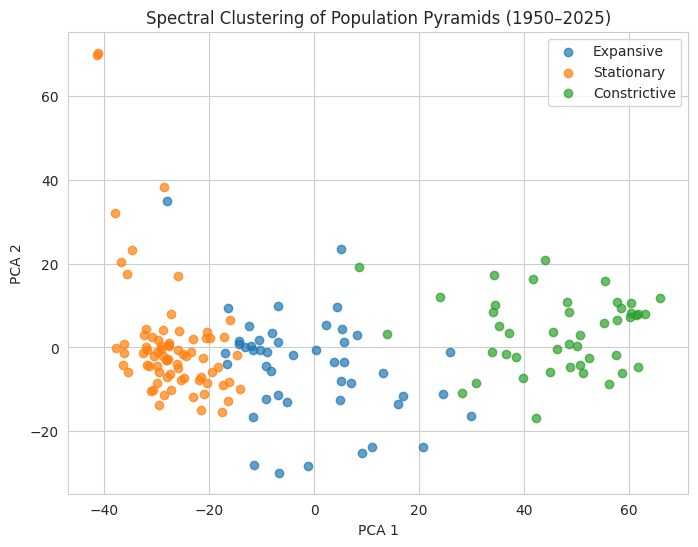

In [101]:
# --- Spectral clustering on population pyramid evolution (1950–2025) ---
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

OUT_DIR = "spectral_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# --- Prepare feature matrix ---
ages = [c for c in pivot.columns if re.match(r"^\d+", str(c))]
years = sorted(pivot[year_col].unique())
countries = sorted(pivot[country_col].unique())

# Build a matrix for each country across all years and 21 age groups
rows = []
for c in countries:
    sub = pivot[pivot[country_col] == c].set_index(year_col)
    vec = []
    for y in years:
        if y in sub.index:
            vals = sub.loc[y, ages].values
            vec.extend(vals)
        else:
            vec.extend([0]*len(ages))
    rows.append((c, np.array(vec)))

X = np.vstack([r[1] for r in rows])
print("Feature matrix:", X.shape)

# Normalize by total population
X = X / (X.sum(axis=1, keepdims=True) + 1e-9)

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Build affinity matrix ---
dist = pairwise_distances(X_scaled, metric="cosine")
sigma = np.median(dist)
affinity = np.exp(-dist**2 / (2*sigma**2 + 1e-12))

# --- Spectral clustering (3 clusters) ---
spec = SpectralClustering(n_clusters=3, affinity="precomputed", random_state=42)
labels_spec = spec.fit_predict(affinity)

# --- Save labeled results ---
res_spec = pd.DataFrame({
    "Country": countries,
    "SpectralCluster": labels_spec
})

# Map cluster labels
cluster_map = {0: "Expansive", 1: "Stationary", 2: "Constrictive"}
res_spec["ClusterLabel"] = res_spec["SpectralCluster"].map(cluster_map)

# --- Export grouped CSV ---
grouped = []
for lbl, grp in res_spec.groupby("ClusterLabel"):
    grouped.append({
        "Cluster": lbl,
        "Countries": ", ".join(sorted(grp["Country"]))
    })
pd.DataFrame(grouped).to_csv(os.path.join(OUT_DIR, "spectral_cluster_groups.csv"), index=False)
res_spec.to_csv(os.path.join(OUT_DIR, "spectral_cluster_labels.csv"), index=False)

print("Saved results to spectral_outputs/")

# --- PCA visualization ---
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
for i, name in cluster_map.items():
    pts = X_pca[labels_spec == i]
    plt.scatter(pts[:,0], pts[:,1], label=name, alpha=0.7)
plt.legend()
plt.title("Spectral Clustering of Population Pyramids (1950–2025)")
plt.xlabel("PCA 1"); plt.ylabel("PCA 2")
plt.grid(True)
plt.show()


✅ Saved: spectral_decade_transitions.csv


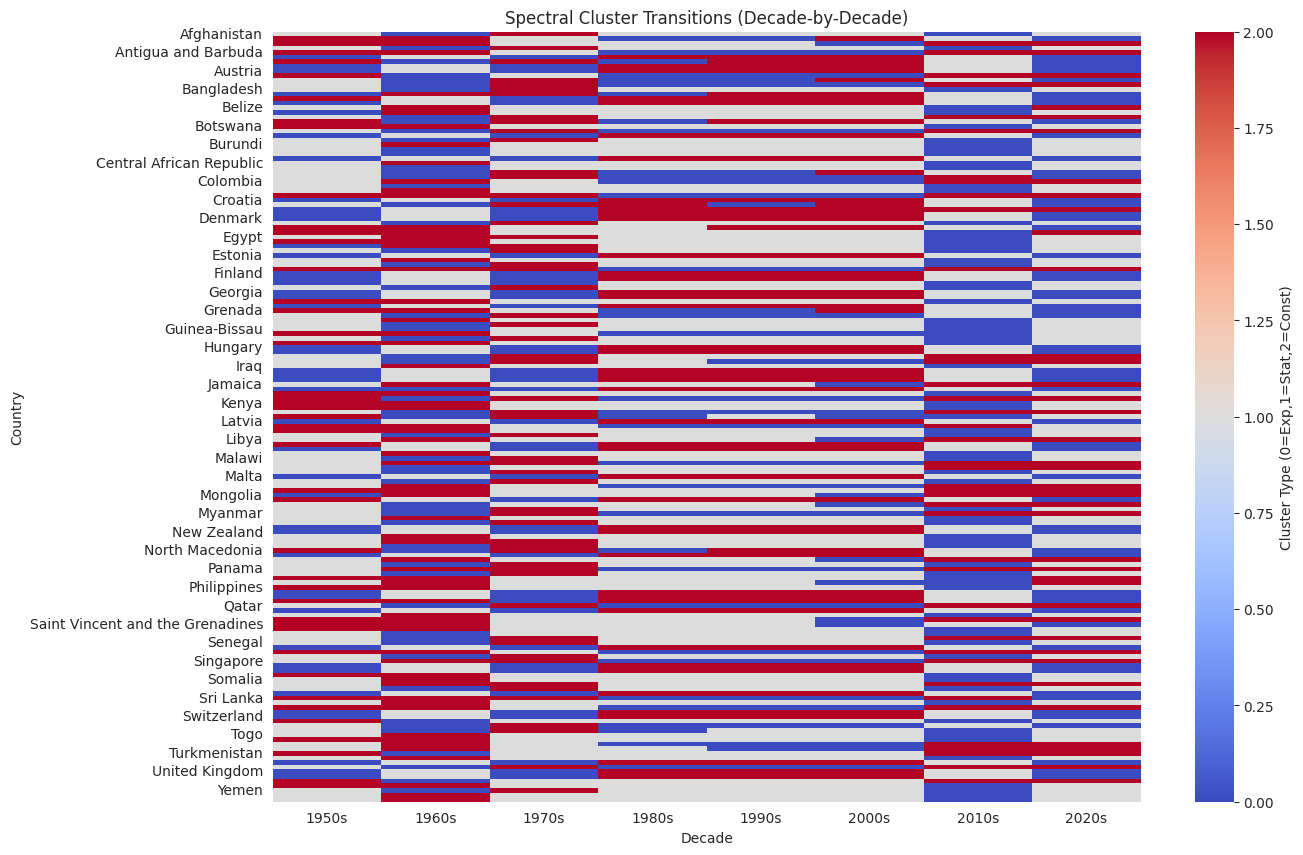

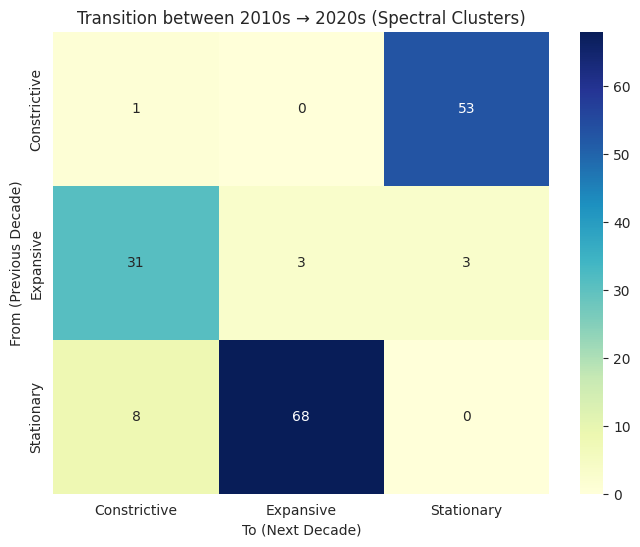

In [102]:
# --- Spectral Clustering Decade-by-Decade and Transition Tracking ---
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import re

# --- Setup ---
decades = [(1950, 1959), (1960, 1969), (1970, 1979), (1980, 1989),
           (1990, 1999), (2000, 2009), (2010, 2019), (2020, 2025)]

# Prepare storage for results
country_decade_clusters = pd.DataFrame(index=countries)

# --- Loop through decades ---
for start, end in decades:
    decade_name = f"{start}s"
    df_dec = pivot[(pivot[year_col] >= start) & (pivot[year_col] <= end)]

    rows, valid_countries = [], []
    for c in countries:
        sub = df_dec[df_dec[country_col] == c].set_index(year_col)
        if sub.empty:
            continue
        vals = []
        for y in range(start, end + 1):
            if y in sub.index:
                vals.extend(sub.loc[y, ages].values)
            else:
                vals.extend([0]*len(ages))
        rows.append(vals)
        valid_countries.append(c)

    if len(rows) < 3:
        continue

    X = np.array(rows)
    X = X / (X.sum(axis=1, keepdims=True) + 1e-9)
    X_scaled = StandardScaler().fit_transform(X)
    dist = pairwise_distances(X_scaled, metric="cosine")
    sigma = np.median(dist)
    affinity = np.exp(-dist**2 / (2*sigma**2 + 1e-12))

    spec = SpectralClustering(n_clusters=3, affinity="precomputed", random_state=42)
    labels = spec.fit_predict(affinity)
    labels_mapped = pd.Series(labels, index=valid_countries).map({0:"Expansive",1:"Stationary",2:"Constrictive"})

    country_decade_clusters[decade_name] = labels_mapped

# --- Save transitions ---
country_decade_clusters.to_csv("spectral_decade_transitions.csv")
print("✅ Saved: spectral_decade_transitions.csv")

# --- Plot: Heatmap of transitions ---
plt.figure(figsize=(14,10))
sns.heatmap(country_decade_clusters.apply(lambda x: x.map({"Expansive":0,"Stationary":1,"Constrictive":2})),
            cmap="coolwarm", cbar_kws={'label': 'Cluster Type (0=Exp,1=Stat,2=Const)'})
plt.title("Spectral Cluster Transitions (Decade-by-Decade)")
plt.ylabel("Country")
plt.xlabel("Decade")
plt.show()

# --- Plot: Transition flow summary ---
transitions = []
for i in range(len(decades)-1):
    d1 = f"{decades[i][0]}s"
    d2 = f"{decades[i+1][0]}s"
    df_pair = country_decade_clusters[[d1,d2]].dropna()
    transition = df_pair.groupby([d1,d2]).size().unstack(fill_value=0)
    transitions.append((d1, d2, transition))

# Visualize the last transition as example
last_transition = transitions[-2][2]  # e.g., 2010s→2020s
plt.figure(figsize=(8,6))
sns.heatmap(last_transition, annot=True, cmap="YlGnBu", fmt="d")
plt.title("Transition between 2010s → 2020s (Spectral Clusters)")
plt.xlabel("To (Next Decade)")
plt.ylabel("From (Previous Decade)")
plt.show()


#DTW 2

✅ Saved: dtw_cluster_results.csv


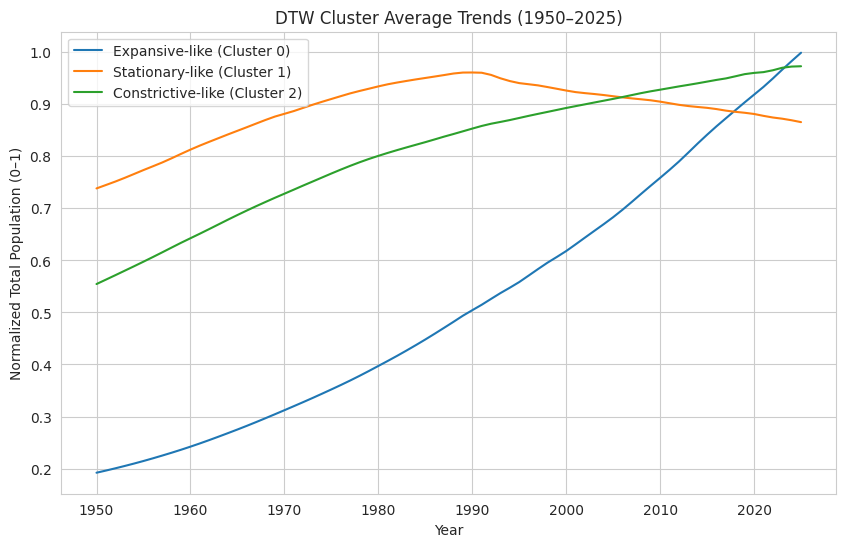

In [103]:
# --- DTW-based Temporal Clustering (Population Pyramids 1950–2025) ---
!pip install tslearn fastdtw > /dev/null

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tslearn.clustering import TimeSeriesKMeans
from tslearn.utils import to_time_series_dataset
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# --- Prepare DTW input ---
years = sorted(pivot[year_col].unique())
age_groups = [c for c in pivot.columns if re.match(r"^\d+", str(c))]

# Aggregate age structure per country per year (sum of age group %)
country_year_vectors = {}
for c in countries:
    sub = pivot[pivot[country_col] == c].set_index(year_col)
    if sub.empty:
        continue
    sub = sub.reindex(years, fill_value=0)
    # Flatten all 21 age groups into one temporal pattern per year (mean or total)
    sub['total'] = sub[age_groups].sum(axis=1)
    country_year_vectors[c] = sub['total'].values

# Stack as time series
X = np.array([v for v in country_year_vectors.values()])
X = X / (X.max(axis=1, keepdims=True) + 1e-9)  # normalize by each country's max
X = to_time_series_dataset(X)

# --- DTW clustering ---
n_clusters = 3
dtw_model = TimeSeriesKMeans(n_clusters=n_clusters, metric="dtw", random_state=42, n_jobs=-1)
labels_dtw = dtw_model.fit_predict(X)

dtw_results = pd.DataFrame({
    "Country": list(country_year_vectors.keys()),
    "DTW_Cluster": labels_dtw
})

cluster_map = {0: "Expansive-like", 1: "Stationary-like", 2: "Constrictive-like"}
dtw_results["ClusterLabel"] = dtw_results["DTW_Cluster"].map(cluster_map)
dtw_results.to_csv("dtw_cluster_results.csv", index=False)
print("✅ Saved: dtw_cluster_results.csv")

# --- Visualize DTW average trends ---
plt.figure(figsize=(10,6))
for k in range(n_clusters):
    cluster_ts = X[labels_dtw == k]
    avg_pattern = cluster_ts.mean(axis=0)
    plt.plot(years, avg_pattern, label=f"{cluster_map[k]} (Cluster {k})")
plt.legend()
plt.title("DTW Cluster Average Trends (1950–2025)")
plt.xlabel("Year")
plt.ylabel("Normalized Total Population (0–1)")
plt.grid(True)
plt.show()


In [104]:
# --- Interactive Sankey Flow Diagram for Cluster Transitions ---
!pip install plotly > /dev/null
import plotly.graph_objects as go

# Prepare transition data (from spectral_decade_transitions.csv)
df_trans = pd.read_csv("spectral_decade_transitions.csv")

# Encode cluster names numerically for links
cluster_order = ["Expansive", "Stationary", "Constrictive"]
nodes = []
for decade in df_trans.columns:
    for c in cluster_order:
        nodes.append(f"{c} ({decade})")

sources, targets, values = [], [], []
for i in range(len(df_trans.columns)-1):
    d1, d2 = df_trans.columns[i], df_trans.columns[i+1]
    df_pair = df_trans[[d1, d2]].dropna()
    for c1 in cluster_order:
        for c2 in cluster_order:
            n = len(df_pair[(df_pair[d1]==c1) & (df_pair[d2]==c2)])
            if n > 0:
                sources.append(nodes.index(f"{c1} ({d1})"))
                targets.append(nodes.index(f"{c2} ({d2})"))
                values.append(n)

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=25, thickness=20,
        label=nodes,
        color=["#90CAF9","#A5D6A7","#EF9A9A"] * len(df_trans.columns)
    ),
    link=dict(source=sources, target=targets, value=values)
)])
fig.update_layout(title_text="Spectral Cluster Transitions (1950s–2020s)", font_size=12)
fig.show()


In [106]:
# --- Choropleth Map for Spectral Clusters (Expansive / Stationary / Constrictive) ---
!pip install plotly pycountry > /dev/null

import pandas as pd
import plotly.express as px
import pycountry
import os

# --- Load spectral clustering results ---
# (adjust this if your file is named differently)
df_map = pd.read_csv("clustering_outputs/cluster_assignments.csv")

# --- Ensure correct column names ---
if "Country" not in df_map.columns:
    df_map.rename(columns={"Location": "Country"}, inplace=True)
if "SpectralCluster" not in df_map.columns:
    # Sometimes stored as 'Spectral_Cluster'
    col = [c for c in df_map.columns if "spec" in c.lower()]
    if col:
        df_map.rename(columns={col[0]: "SpectralCluster"}, inplace=True)

# --- Map cluster numbers to human-readable labels ---
cluster_labels = {0: "Expansive", 1: "Stationary", 2: "Constrictive"}
df_map["ClusterLabel"] = df_map["SpectralCluster"].map(cluster_labels)

# --- Convert country names to ISO Alpha-3 codes for plotting ---
def get_iso3(name):
    try:
        return pycountry.countries.lookup(name).alpha_3
    except:
        return None

df_map["iso_alpha"] = df_map["Country"].apply(get_iso3)
df_map = df_map.dropna(subset=["iso_alpha"])

# --- Define color palette ---
color_map = {
    "Expansive": "#64B5F6",      # blue
    "Stationary": "#81C784",     # green
    "Constrictive": "#E57373"    # red
}

# --- Create interactive choropleth map ---
fig = px.choropleth(
    df_map,
    locations="iso_alpha",
    color="ClusterLabel",
    hover_name="Country",
    title="World Population Pyramid Clusters (Spectral, 1950–2025)",
    color_discrete_map=color_map,
    projection="natural earth"
)

fig.update_layout(
    title_font_size=18,
    geo=dict(showframe=False, showcoastlines=True),
)

fig.show()


In [107]:
# --- Choropleth Map for Spectral Clusters ---
!pip install plotly pycountry > /dev/null

import pandas as pd
import plotly.express as px
import pycountry

# === Load spectral clustering results ===
df_spec = pd.read_csv("clustering_outputs/cluster_assignments.csv")

# --- Ensure correct column names ---
if "Country" not in df_spec.columns:
    df_spec.rename(columns={"Location": "Country"}, inplace=True)
if "SpectralCluster" not in df_spec.columns:
    col = [c for c in df_spec.columns if "spec" in c.lower()]
    if col:
        df_spec.rename(columns={col[0]: "SpectralCluster"}, inplace=True)

# --- Map cluster IDs to demographic labels ---
cluster_labels = {0: "Expansive", 1: "Stationary", 2: "Constrictive"}
df_spec["ClusterLabel"] = df_spec["SpectralCluster"].map(cluster_labels)

# --- Convert country names to ISO Alpha-3 codes ---
def get_iso3(name):
    try:
        return pycountry.countries.lookup(name).alpha_3
    except:
        return None

df_spec["iso_alpha"] = df_spec["Country"].apply(get_iso3)
df_spec = df_spec.dropna(subset=["iso_alpha"])

# --- Define color palette ---
color_map = {
    "Expansive": "#64B5F6",      # Blue
    "Stationary": "#81C784",     # Green
    "Constrictive": "#E57373"    # Red
}

# --- Create interactive map ---
fig_spec = px.choropleth(
    df_spec,
    locations="iso_alpha",
    color="ClusterLabel",
    hover_name="Country",
    title="World Population Pyramid Clusters (Spectral, 1950–2025)",
    color_discrete_map=color_map,
    projection="natural earth"
)

fig_spec.update_layout(
    title_font_size=18,
    geo=dict(showframe=False, showcoastlines=True),
)
fig_spec.show()


In [108]:
# --- Choropleth Map for Hierarchical Clusters ---
!pip install plotly pycountry > /dev/null

import pandas as pd
import plotly.express as px
import pycountry

# === Load hierarchical clustering results ===
df_hier = pd.read_csv("clustering_outputs/cluster_assignments.csv")

# --- Ensure correct column names ---
if "Country" not in df_hier.columns:
    df_hier.rename(columns={"Location": "Country"}, inplace=True)
if "HierCluster" not in df_hier.columns:
    col = [c for c in df_hier.columns if "hier" in c.lower()]
    if col:
        df_hier.rename(columns={col[0]: "HierCluster"}, inplace=True)

# --- Map cluster IDs to demographic labels (after correction you mentioned) ---
# 0 = Expansive, 1 = Stationary, 2 = Constrictive
cluster_labels_hier = {0: "Expansive", 1: "Stationary", 2: "Constrictive"}
df_hier["ClusterLabel"] = df_hier["HierCluster"].map(cluster_labels_hier)

# --- Convert country names to ISO Alpha-3 codes ---
def get_iso3(name):
    try:
        return pycountry.countries.lookup(name).alpha_3
    except:
        return None

df_hier["iso_alpha"] = df_hier["Country"].apply(get_iso3)
df_hier = df_hier.dropna(subset=["iso_alpha"])

# --- Define color palette (same as spectral for consistency) ---
color_map = {
    "Expansive": "#64B5F6",      # Blue
    "Stationary": "#81C784",     # Green
    "Constrictive": "#E57373"    # Red
}

# --- Create interactive map ---
fig_hier = px.choropleth(
    df_hier,
    locations="iso_alpha",
    color="ClusterLabel",
    hover_name="Country",
    title="World Population Pyramid Clusters (Hierarchical, 1950–2025)",
    color_discrete_map=color_map,
    projection="natural earth"
)

fig_hier.update_layout(
    title_font_size=18,
    geo=dict(showframe=False, showcoastlines=True),
)
fig_hier.show()


In [109]:
# --- Choropleth Map for DTW Clusters (Temporal Demographic Patterns) ---
!pip install plotly pycountry > /dev/null

import pandas as pd
import plotly.express as px
import pycountry

# === Load DTW clustering results ===
# If you saved the results elsewhere, change the path accordingly
df_dtw = pd.read_csv("dtw_cluster_results.csv")

# --- Ensure column consistency ---
if "Country" not in df_dtw.columns:
    df_dtw.rename(columns={"Location": "Country"}, inplace=True)
if "DTW_Cluster" not in df_dtw.columns:
    col = [c for c in df_dtw.columns if "dtw" in c.lower()]
    if col:
        df_dtw.rename(columns={col[0]: "DTW_Cluster"}, inplace=True)

# --- Map cluster IDs to readable demographic evolution labels ---
cluster_labels_dtw = {
    0: "Expansive-like",
    1: "Stationary-like",
    2: "Constrictive-like"
}
df_dtw["ClusterLabel"] = df_dtw["DTW_Cluster"].map(cluster_labels_dtw)

# --- Convert country names to ISO Alpha-3 codes ---
def get_iso3(name):
    try:
        return pycountry.countries.lookup(name).alpha_3
    except:
        return None

df_dtw["iso_alpha"] = df_dtw["Country"].apply(get_iso3)
df_dtw = df_dtw.dropna(subset=["iso_alpha"])

# --- Define color palette (same tone as Spectral/Hier) ---
color_map = {
    "Expansive-like": "#64B5F6",      # Blue
    "Stationary-like": "#81C784",     # Green
    "Constrictive-like": "#E57373"    # Red
}

# --- Create interactive choropleth map ---
fig_dtw = px.choropleth(
    df_dtw,
    locations="iso_alpha",
    color="ClusterLabel",
    hover_name="Country",
    title="World Population Pyramid Evolution Clusters (DTW, 1950–2025)",
    color_discrete_map=color_map,
    projection="natural earth"
)

fig_dtw.update_layout(
    title_font_size=18,
    geo=dict(showframe=False, showcoastlines=True),
)
fig_dtw.show()


In [110]:
# --- Install required libraries ---
!pip install pandas matplotlib seaborn > /dev/null

import pandas as pd
import matplotlib.pyplot as plt

# === Load your dataset ===
# Ensure this matches your file name
df = pd.read_csv("age_data.csv")

# Example column structure:
# Country, Year, AgeGroup, Male, Female
# (Adjust the names if your columns differ)

# === Function to plot a population pyramid ===
def plot_population_pyramid(data, country, year, cluster_label=None):
    df_country = data[(data["Country"] == country) & (data["Year"] == year)]
    df_country = df_country.sort_values("AgeGroup")

    # Convert age groups to ordered category for consistent plotting
    df_country["AgeGroup"] = pd.Categorical(
        df_country["AgeGroup"],
        ordered=True,
        categories=df_country["AgeGroup"].unique()
    )

    # Highlight the demographic dividend range (15–64)
    dividend_mask = df_country["AgeGroup"].str.extract(r"(\d+)").astype(float)[0].between(15, 64)

    fig, ax = plt.subplots(figsize=(6, 7))
    ax.barh(df_country["AgeGroup"], -df_country["Male"], color="#9E9E9E", label="Male")
    ax.barh(df_country["AgeGroup"], df_country["Female"], color="#BDBDBD", label="Female")

    # Highlight working-age range (demographic dividend)
    ax.barh(df_country["AgeGroup"][dividend_mask], -df_country["Male"][dividend_mask], color="#64B5F6")
    ax.barh(df_country["AgeGroup"][dividend_mask], df_country["Female"][dividend_mask], color="#64B5F6")

    ax.set_xlabel("Percentage of Population")
    ax.set_ylabel("Age Group")
    ax.set_title(f"{country} ({year})\n{'Cluster: ' + str(cluster_label) if cluster_label else ''}")
    ax.legend(loc="upper right")
    ax.set_xlim(-max(df_country["Male"])*1.1, max(df_country["Female"])*1.1)
    ax.axvline(0, color="black")

    plt.tight_layout()
    plt.show()

# === Example usage for each clustering method ===

# Load clustering results (adjust file paths)
spectral = pd.read_csv("spectral_cluster_labels.csv")
hier = pd.read_csv("hier_cluster_labels.csv")
dtw = pd.read_csv("dtw_cluster_results.csv")

# Select example countries from each cluster
example_countries = {
    "spectral": {0: ["India", "Nigeria"], 1: ["USA", "Brazil"], 2: ["Japan", "Germany"]},
    "hier": {0: ["Ethiopia", "Pakistan"], 1: ["China", "Mexico"], 2: ["Italy", "France"]},
    "dtw": {0: ["Bangladesh", "Kenya"], 1: ["United Kingdom", "Turkey"], 2: ["Spain", "South Korea"]}
}

# === Generate pyramids for each ===
year = 2020  # choose any year in your dataset

for method, clusters in example_countries.items():
    print(f"=== {method.upper()} CLUSTERS ===")
    for cluster_id, countries in clusters.items():
        for c in countries:
            plot_population_pyramid(df, c, year, cluster_label=f"{method} {cluster_id}")


FileNotFoundError: [Errno 2] No such file or directory: 'spectral_cluster_labels.csv'

#Old things


In [75]:
# Uninstall umap-learn and reinstall with specific flags to avoid potential conflicts
!pip uninstall umap-learn -y
!pip install umap-learn --no-build-isolation --no-deps --quiet

# Try importing umap-learn again
import umap.umap_ as umap

print("umap-learn imported successfully.")

Found existing installation: umap-learn 0.5.9.post2
Uninstalling umap-learn-0.5.9.post2:
  Successfully uninstalled umap-learn-0.5.9.post2
umap-learn imported successfully.


In [76]:
# =====================================================
# Euclidean Laplacian-based Spectral + Hierarchical Clustering
# Uses eigengap + silhouette for evaluation
# FINAL CLUSTERS: 3 (Expansive, Stationary, Constrictive)
# =====================================================

import os, re, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances, silhouette_score
from sklearn.cluster import SpectralClustering, AgglomerativeClustering
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import laplacian as csgraph_laplacian
from scipy.linalg import eigh
from scipy.cluster.hierarchy import linkage, dendrogram
# import umap.umap_ as umap # Commented out
warnings.filterwarnings("ignore")

# --- Config ---
OUT_DIR = "euclidean_forced3_outputs"
Y_MIN, Y_MAX = 1950, 2025
N_AGE_GROUPS = 21
N_NEIGHBORS = 8
FINAL_K = 3
os.makedirs(OUT_DIR, exist_ok=True)

# --- Helper functions ---
def detect_col(df, candidates):
    for name in candidates:
        for c in df.columns:
            if name.lower() == c.lower():
                return c
    for name in candidates:
        for c in df.columns:
            if name.lower() in c.lower():
                return c
    return None

# --- Load data ---
df = pd.read_csv('age_data.csv', low_memory=False, quotechar='"', on_bad_lines='warn')
print("Loaded:", df.shape)

# Explicitly set country_col to 'Location'
country_col = detect_col(df, ['Location','Country','Country Name','country'])
year_col = detect_col(df, ['Time','Year','year'])
age_start_col = detect_col(df, ['AgeGrpStart', 'Age_Group_Start', 'age_start'])
age_span_col = detect_col(df, ['AgeGrpSpan', 'Age_Group_Span', 'age_span'])
pop_col = detect_col(df, ['PopTotal','Value','pop','Population','Pop_Total','PopMale','PopFemale'])

if not country_col: raise RuntimeError("Could not detect country column.")
if not year_col: raise RuntimeError("Could not detect year column.")
if not age_start_col: raise RuntimeError("Could not detect AgeGrpStart column.")
if not age_span_col: raise RuntimeError("Could not detect AgeGrpSpan column.")
if not pop_col: raise RuntimeError("Could not detect population column.")

df = df[(df[year_col]>=Y_MIN)&(df[year_col]<=Y_MAX)]

# Fill NaN values in age columns before creating age_label
df[age_start_col] = df[age_start_col].fillna(0).astype(int)
df[age_span_col] = df[age_span_col].fillna(0).astype(int)

df["AgeLabel"] = df.apply(lambda r: f"{int(r[age_start_col])}-{int(r[age_start_col])+int(r[age_span_col])-1}"
                          if int(r[age_start_col])+int(r[age_span_col])-1<100 else f"{int(r[age_start_col])}+", axis=1)

pivot = df.pivot_table(index=[country_col, year_col], columns="AgeLabel", values=pop_col, aggfunc="sum", fill_value=0)
age_labels = sorted(pivot.columns.tolist(), key=lambda x: int(re.match(r"\d+", x).group(0)) if re.match(r"\d+", x) else 9999)[:N_AGE_GROUPS]
pivot = pivot[age_labels].reset_index()

# --- Filter your countries (use fuzzy match) ---
countries_needed = [
    'Afghanistan','Albania','Algeria','Angola','Antigua and Barbuda','Argentina','Armenia','Australia',
    'Austria','Azerbaijan','Bahamas','Bahrain','Bangladesh','Barbados','Belarus','Belgium','Belize',
    'Benin','Bhutan','Bolivia','Bosnia and Herzegovina','Botswana','Brazil','Brunei','Bulgaria',
    'Burkina Faso','Burundi','Cambodia','Cameroon','Canada','Cape Verde','Central African Republic',
    'Chad','Chile','China','Colombia','Comoros','Congo','Costa Rica',"Cote d'Ivoire",'Croatia','Cuba',
    'Cyprus','Czechia','Denmark','Djibouti','Dominica','Ecuador','Egypt','El Salvador','Equatorial Guinea',
    'Eritrea','Estonia','Eswatini','Ethiopia','Fiji','Finland','France','Gabon','Gambia','Georgia',
    'Germany','Ghana','Greece','Grenada','Guam','Guatemala','Guinea','Guinea-Bissau','Guyana','Haiti',
    'Honduras','Hungary','Iceland','India','Indonesia','Iran','Iraq','Ireland','Israel','Italy',
    'Jamaica','Japan','Jordan','Kazakhstan','Kenya','Kiribati','Kuwait','Kyrgyzstan','Latvia','Lebanon',
    'Lesotho','Liberia','Libya','Lithuania','Luxembourg','Madagascar','Malawi','Malaysia','Maldives',
    'Mali','Malta','Mauritania','Mauritius','Mexico','Mongolia','Montenegro','Morocco','Mozambique',
    'Myanmar','Namibia','Nepal','Netherlands','New Zealand','Nicaragua','Niger','Nigeria','North Korea',
    'North Macedonia','Norway','Moldova','Oman','Pakistan','Panama','Papua New Guinea','Paraguay','Peru',
    'Philippines','Poland','Portugal','Puerto Rico','Qatar','Russia','Romania','Rwanda','Saint Lucia',
    'Saint Vincent and the Grenadines','Samoa','Sao Tome and Principe','Saudi Arabia','Senegal','Serbia',
    'Seychelles','Sierra Leone','Singapore','Slovakia','Slovenia','Solomon Islands','Somalia','South Africa',
    'South Sudan','Spain','Sri Lanka','Sudan','Suriname','Syria','Sweden','Switzerland','Tajikistan',
    'Tanzania','Thailand','Taiwan','Timor-Leste','Togo','Tonga','Trinidad and Tobago','Tunisia','Turkey',
    'Turkmenistan','Uganda','Ukraine','United Arab Emirates','United Kingdom','United States','Uruguay',
    'Uzbekistan','Vanuatu','Venezuela','Vietnam','Yemen','Zambia','Zimbabwe'
]
available = pivot[country_col].unique()
print("Available countries before matching:", available)
matched = [c for c in available if c in countries_needed]
pivot = pivot[pivot[country_col].isin(matched)]
countries = sorted(pivot[country_col].unique())
years = sorted(pivot[year_col].unique())
print(f"Using {len(countries)} countries × {len(years)} years × {len(age_labels)} ages")

# --- Build feature matrix ---
X = []
for c in countries:
    sub = pivot[pivot[country_col]==c].set_index(year_col)
    vals = []
    for y in years:
        if y in sub.index:
            vals.extend(sub.loc[y, age_labels].values)
        else:
            vals.extend([0]*len(age_labels))
    X.append(vals)
X = np.array(X)
X = X / (X.sum(axis=1, keepdims=True)+1e-9)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Feature matrix:", X.shape)

# --- Normalize and reduce ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
svd = TruncatedSVD(n_components=100, random_state=42)
X_red = svd.fit_transform(X_scaled)
print("Reduced:", X_red.shape)

# --- Euclidean distance + affinity matrix ---
D = pairwise_distances(X_red, metric="euclidean")
sigma = np.median(D)
A = np.exp(-D**2/(2*sigma**2))
knn = kneighbors_graph(D, n_neighbors=N_NEIGHBORS, metric="precomputed", mode="connectivity", include_self=True)
mask = (knn.toarray()>0).astype(float)
A = A * mask
print("Affinity matrix done.")

# --- Eigengap heuristic ---
L = csgraph_laplacian(A, normed=True)
eigvals, _ = eigh(L)
eigvals = np.sort(eigvals)
gaps = np.diff(eigvals[:40])
k_eig = int(np.argmax(gaps)+1)
plt.plot(range(1, len(gaps)+1), gaps, marker='o')
plt.title("Eigengap Heuristic (Euclidean Laplacian)")
plt.xlabel("k"); plt.ylabel("Eigenvalue gap")
plt.grid(True)
plt.savefig(os.path.join(OUT_DIR, "eigengap_euclidean.png"))
plt.close()
print("Eigengap suggested k:", k_eig)

# --- Silhouette for reference (not for selection) ---
scores = {}
for k in range(2, 10):
    try:
        labels = SpectralClustering(n_clusters=k, affinity="precomputed", random_state=42).fit_predict(A)
        scores[k] = silhouette_score(X_red, labels)
    except:
        scores[k] = None
plt.plot(list(scores.keys()), list(scores.values()), marker='o')
plt.title("Silhouette Scores (Spectral)")
plt.xlabel("k"); plt.ylabel("Silhouette Score")
plt.grid(True)
plt.savefig(os.path.join(OUT_DIR,"silhouette_scores.png"))
plt.close()

# --- Forced 3 clusters ---
print("\n🔹 Forcing final clusters = 3 (Expansive / Stationary / Constrictive)\n")

spec = SpectralClustering(n_clusters=FINAL_K, affinity="precomputed", random_state=42)
labels_spec = spec.fit_predict(A)

hier = AgglomerativeClustering(n_clusters=FINAL_K, linkage="ward")
labels_hier = hier.fit_predict(X_red)

# --- Save assignments ---
out = pd.DataFrame({
    "Country": countries,
    "SpectralCluster": labels_spec,
    "HierarchicalCluster": labels_hier
})
out.to_csv(os.path.join(OUT_DIR,"cluster_assignments_3.csv"), index=False)
print(" Saved cluster_assignments_3.csv")

# --- Visualization ---
pca = PCA(n_components=2)
pc = pca.fit_transform(X_red)
plt.figure(figsize=(8,6))
for c in np.unique(labels_hier):
    plt.scatter(pc[labels_hier==c,0], pc[labels_hier==c,1], label=f"Cluster {c}")
plt.legend()
plt.title("PCA (Hierarchical Clusters, k=3)")
plt.savefig(os.path.join(OUT_DIR,"pca_clusters.png"))
plt.close()

Z = linkage(X_red[:60], method="ward")
plt.figure(figsize=(12,6))
dendrogram(Z, labels=countries[:60], leaf_rotation=90, leaf_font_size=7)
plt.title("Dendrogram Subset (first 60 countries)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,"dendrogram_subset.png"))
plt.close()

print(f"\n All 3-cluster results saved to: {OUT_DIR}")

Loaded: (1759905, 20)
Available countries before matching: ['ADB region: Central and West Asia' 'ADB region: Developed'
 'ADB region: East Asia' 'ADB region: South Asia'
 'ADB region: Southeast Asia' 'ADB region: The Pacific' 'AUKUS'
 'Afghanistan' 'Africa' 'African Group' 'African Union'
 'African Union: Central Africa' 'African Union: Eastern Africa'
 'African Union: Northern Africa' 'African Union: Southern Africa'
 'African Union: Western Africa'
 'African, Caribbean and Pacific (ACP) Group of States' 'Albania'
 'Algeria' 'American Samoa' 'Americas' 'Andean Community' 'Andorra'
 'Angola' 'Anguilla' 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Aruba'
 'Asia' 'Asia-Pacific Economic Cooperation (APEC)' 'Asia-Pacific Group'
 'Association of Southeast Asian Nations (ASEAN)' 'Australia'
 'Australia/New Zealand' 'Austria' 'Azerbaijan' 'BRIC' 'BRICS' 'Bahamas'
 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus' 'Belgium' 'Belize'
 'Belt-Road Initiative (BRI)' 'Belt-Road Initiative: Africa'
 'Belt

In [78]:
# =====================================================
# Euclidean Laplacian clustering (select 21 age groups x 1950-2025),
# compute eigengap + silhouette, force final k = 3, label clusters.
# =====================================================

!pip install umap-learn --quiet

import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances, silhouette_score, silhouette_samples
from sklearn.cluster import SpectralClustering, AgglomerativeClustering
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import laplacian as csgraph_laplacian
from scipy.linalg import eigh
from scipy.cluster.hierarchy import linkage, dendrogram
import umap.umap_ as umap

warnings.filterwarnings("ignore")
plt.ioff()

# ---------- Config ----------
OUT_DIR = "euclidean_forced3_outputs"
Y_MIN, Y_MAX = 1950, 2025
N_AGE_GROUPS = 21
N_NEIGHBORS = 8
FINAL_K = 3
PCA_COMPONENTS = 100
DENDRO_SUBSET = 60
os.makedirs(OUT_DIR, exist_ok=True)

# ---------- Hard-coded country list (your 182) ----------
countries_needed = [
    'Afghanistan','Albania','Algeria','Angola','Antigua and Barbuda','Argentina','Armenia','Australia',
    'Austria','Azerbaijan','Bahamas','Bahrain','Bangladesh','Barbados','Belarus','Belgium','Belize',
    'Benin','Bhutan','Bolivia','Bosnia and Herzegovina','Botswana','Brazil','Brunei','Bulgaria',
    'Burkina Faso','Burundi','Cambodia','Cameroon','Canada','Cape Verde','Central African Republic',
    'Chad','Chile','China','Colombia','Comoros','Congo','Costa Rica',"Cote d'Ivoire",'Croatia','Cuba',
    'Cyprus','Czechia','Denmark','Djibouti','Dominica','Ecuador','Egypt','El Salvador','Equatorial Guinea',
    'Eritrea','Estonia','Eswatini','Ethiopia','Fiji','Finland','France','Gabon','Gambia','Georgia',
    'Germany','Ghana','Greece','Grenada','Guam','Guatemala','Guinea','Guinea-Bissau','Guyana','Haiti',
    'Honduras','Hungary','Iceland','India','Indonesia','Iran','Iraq','Ireland','Israel','Italy',
    'Jamaica','Japan','Jordan','Kazakhstan','Kenya','Kiribati','Kuwait','Kyrgyzstan','Latvia','Lebanon',
    'Lesotho','Liberia','Libya','Lithuania','Luxembourg','Madagascar','Malawi','Malaysia','Maldives',
    'Mali','Malta','Mauritania','Mauritius','Mexico','Mongolia','Montenegro','Morocco','Mozambique',
    'Myanmar','Namibia','Nepal','Netherlands','New Zealand','Nicaragua','Niger','Nigeria','North Korea',
    'North Macedonia','Norway','Moldova','Oman','Pakistan','Panama','Papua New Guinea','Paraguay','Peru',
    'Philippines','Poland','Portugal','Puerto Rico','Qatar','Russia','Romania','Rwanda','Saint Lucia',
    'Saint Vincent and the Grenadines','Samoa','Sao Tome and Principe','Saudi Arabia','Senegal','Serbia',
    'Seychelles','Sierra Leone','Singapore','Slovakia','Slovenia','Solomon Islands','Somalia','South Africa',
    'South Sudan','Spain','Sri Lanka','Sudan','Suriname','Syria','Sweden','Switzerland','Tajikistan',
    'Tanzania','Thailand','Taiwan','Timor-Leste','Togo','Tonga','Trinidad and Tobago','Tunisia','Turkey',
    'Turkmenistan','Uganda','Ukraine','United Arab Emirates','United Kingdom','United States','Uruguay',
    'Uzbekistan','Vanuatu','Venezuela','Vietnam','Yemen','Zambia','Zimbabwe'
]

# ---------- Helpers ----------
def detect_col(df, candidates):
    for name in candidates:
        for c in df.columns:
            if name.lower() == c.lower():
                return c
    for name in candidates:
        for c in df.columns:
            if name.lower() in c.lower():
                return c
    return None

def fuzzy_match(targets, available):
    matched = []
    a_lower = {a.lower(): a for a in available}
    for t in targets:
        t_l = t.lower()
        if t_l in a_lower:
            matched.append(a_lower[t_l]); continue
        found = None
        for a in available:
            al = a.lower()
            if t_l == al or t_l in al or al in t_l:
                found = a; break
        if found: matched.append(found)
    # unique preserve order
    return list(dict.fromkeys(matched))

# ---------- Load and detect columns ----------
df = pd.read_csv('age_data.csv', low_memory=False, quotechar='"', on_bad_lines='warn')
print("Loaded:", df.shape)

country_col = detect_col(df, ['Location','Country','Country Name','country'])
year_col    = detect_col(df, ['Time','Year','year'])
age_start_col = detect_col(df, ['AgeGrpStart','Age_Group_Start','age_start'])
age_span_col  = detect_col(df, ['AgeGrpSpan','Age_Group_Span','age_span'])
pop_col = detect_col(df, ['PopTotal','Value','pop','Population','Pop_Total','PopMale','PopFemale'])

if not (country_col and year_col and pop_col):
    raise RuntimeError("Could not detect country/year/pop columns. Check CSV header.")

print("Detected columns:", country_col, year_col, age_start_col, age_span_col, pop_col)

# ---------- Filter years ----------
df[year_col] = pd.to_numeric(df[year_col], errors='coerce').fillna(0).astype(int)
df = df[(df[year_col] >= Y_MIN) & (df[year_col] <= Y_MAX)].copy()
print("Filtered years:", df[year_col].min(), "-", df[year_col].max(), "=>", df.shape)

# ---------- Build age_label (vectorized, safe) ----------
if age_start_col is None or age_span_col is None:
    raise RuntimeError("Script requires AgeGrpStart and AgeGrpSpan columns.")
# ensure numeric
df[age_start_col] = pd.to_numeric(df[age_start_col], errors='coerce').fillna(0).astype(int)
df[age_span_col]  = pd.to_numeric(df[age_span_col], errors='coerce').fillna(0).astype(int)
age_end = df[age_start_col] + df[age_span_col] - 1
df['age_label'] = np.where(age_end < 100,
                           df[age_start_col].astype(str) + '-' + age_end.astype(str),
                           df[age_start_col].astype(str) + '+')

# ---------- Pivot to (country,year) x age_label and select first 21 age groups ----------
pivot = df.pivot_table(index=[country_col, year_col], columns='age_label', values=pop_col, aggfunc='sum', fill_value=0)
# determine numeric lower bound for sorting; fallback keep as-is
def lower_bound(a):
    m = re.match(r'(\d+)', str(a))
    return int(m.group(1)) if m else 9999
age_labels_all = sorted(list(pivot.columns), key=lambda x: lower_bound(x))
age_labels = age_labels_all[:N_AGE_GROUPS]
print("Detected age labels count:", len(age_labels_all), " -> using", len(age_labels))
pivot = pivot[age_labels].reset_index()

# ---------- Select countries (fuzzy match), fallback to available if few matched ----------
available_countries = sorted(pivot[country_col].unique())
matched = fuzzy_match(countries_needed, available_countries)
print("Requested 182 -> matched in data:", len(matched))
if len(matched) < 150:
    print("Matched fewer than 150 requested countries; using ALL available countries instead.")
    use_countries = available_countries
else:
    use_countries = matched[:182]
print("Using countries count:", len(use_countries))

pivot_f = pivot[pivot[country_col].isin(use_countries)].copy()
years = sorted(pivot_f[year_col].astype(int).unique())
print("Years used:", years[0], "-", years[-1], "count:", len(years))
countries = sorted(pivot_f[country_col].unique())

# ---------- Build feature matrix: each country -> stacked (age groups) across years ----------
X_rows = []
for c in countries:
    sub = pivot_f[pivot_f[country_col] == c].set_index(year_col)
    vec = []
    for y in years:
        if int(y) in sub.index:
            row = sub.loc[int(y)]
            if isinstance(row, pd.DataFrame):
                row = row.mean(axis=0)
            vals = row[age_labels].astype(float).values
            vec.extend(vals.tolist())
        else:
            vec.extend([0.0] * len(age_labels))
    X_rows.append(vec)
X = np.vstack(X_rows)
print("Feature matrix shape:", X.shape)  # (n_countries, 21*years)

# ---------- Normalize per-country to proportions ----------
row_sums = X.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1.0
X_prop = X / row_sums

# ---------- Standardize and reduce (SVD) ----------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_prop)
n_comp = min(PCA_COMPONENTS, X_scaled.shape[1]-1, X_scaled.shape[0]-1)
if n_comp < 1: n_comp = 1
svd = TruncatedSVD(n_components=n_comp, random_state=42)
X_red = svd.fit_transform(X_scaled)
print("Reduced X shape:", X_red.shape)

# ---------- Euclidean distance and kNN-weighted Gaussian affinity ----------
D = pairwise_distances(X_red, metric='euclidean')
sigma = np.median(D[np.triu_indices(D.shape[0], k=1)])
if sigma <= 0 or np.isnan(sigma): sigma = 1.0
W = np.exp(-D**2 / (2.0 * (sigma**2 + 1e-12)))
knn = kneighbors_graph(D, n_neighbors=N_NEIGHBORS, metric='precomputed', mode='connectivity', include_self=True)
mask = (knn.toarray() > 0).astype(float)
mask = np.maximum(mask, mask.T)
A = W * mask
pd.DataFrame(D, index=countries, columns=countries).to_csv(os.path.join(OUT_DIR, 'distance_euclidean.csv'))
pd.DataFrame(A, index=countries, columns=countries).to_csv(os.path.join(OUT_DIR, 'affinity_euclidean_knn.csv'))
print("Distance and affinity matrices saved.")

# ---------- Laplacian eigengap heuristic ----------
L = csgraph_laplacian(A, normed=True)
eigvals, eigvecs = eigh(L)
eig_sorted = np.sort(eigvals)
gaps = np.diff(eig_sorted[:min(40, len(eig_sorted))])
k_eig = int(np.argmax(gaps) + 1)
# save eigengap plot
plt.figure(figsize=(8,4)); plt.plot(np.arange(1, len(gaps)+1), gaps, marker='o'); plt.title('Eigengap (Euclidean Laplacian)'); plt.xlabel('k'); plt.grid(True); plt.savefig(os.path.join(OUT_DIR,'eigengap_euclidean.png')); plt.close()
print("Eigengap suggested k:", k_eig)

# ---------- Silhouette sweep (for info) ----------
spec_sil = {}
for k in range(2, min(12, X_red.shape[0]-1) + 1):
    try:
        sc = SpectralClustering(n_clusters=k, affinity='precomputed', random_state=42, assign_labels='kmeans')
        labs = sc.fit_predict(A)
        spec_sil[k] = silhouette_score(X_red, labs) if len(set(labs))>1 else -1
    except Exception:
        spec_sil[k] = None
# save silhouette scores
pd.Series(spec_sil).to_frame('spectral_sil').to_csv(os.path.join(OUT_DIR,'spectral_silhouette_scores.csv'))
# plot silhouette vs k
ks = [k for k in spec_sil.keys() if spec_sil[k] is not None]
vals = [spec_sil[k] for k in ks]
plt.figure(figsize=(8,4)); plt.plot(ks, vals, marker='o'); plt.title('Spectral silhouette vs k (Euclidean)'); plt.xlabel('k'); plt.ylabel('silhouette'); plt.grid(True); plt.savefig(os.path.join(OUT_DIR,'spectral_sil_vs_k.png')); plt.close()

# ---------- Force final k = 3 (user requirement) ----------
final_k = FINAL_K
print("Final_k forced to:", final_k)

# ---------- Run Spectral and Hierarchical with final_k ----------
spec_final = SpectralClustering(n_clusters=final_k, affinity='precomputed', random_state=42, assign_labels='kmeans')
labels_spec = spec_final.fit_predict(A)

hier_final = AgglomerativeClustering(n_clusters=final_k, linkage='ward')
labels_hier = hier_final.fit_predict(X_red)

# ---------- Map clusters to Expansive / Stationary / Constrictive (heuristic) ----------
# Define young indices (0-14) and old indices (65+)
young_prefixes = ['0','5','10','15']  # ages starting at 0,5,10,15 -> but 0-14 usually 0-4,5-9,10-14 => indices 0,1,2
# find indices for 0-14 and 65+
def parse_age_start(label):
    m = re.match(r'(\d+)', str(label))
    return int(m.group(1)) if m else 9999

age_starts = [parse_age_start(a) for a in age_labels]
young_idx = [i for i,s in enumerate(age_starts) if s <= 14]
old_idx = [i for i,s in enumerate(age_starts) if s >= 65]

cluster_props = {}
for cluster_id in range(final_k):
    members = [i for i,l in enumerate(labels_spec) if l==cluster_id]
    if len(members)==0:
        cluster_props[cluster_id] = {'young_mean':0.0, 'old_mean':0.0}
        continue
    # compute mean proportion across countries & years: recall X_prop was per-country proportion over all years and ages flattened;
    # To compute young/old proportion we need to sum the corresponding elements in X_prop
    # X_prop shape: (n_countries, Y*A) where A=len(age_labels)
    # for each country row, sum over each year block for the young indices and divide by total (already proportion)
    young_vals = []
    old_vals = []
    for idx in members:
        row = X_prop[idx]  # length = Y*A
        # reshape to (Y, A)
        seq = row.reshape(len(years), len(age_labels))
        # mean proportion across years for this country for young and old
        young_vals.append(seq[:, young_idx].sum(axis=1).mean())
        old_vals.append(seq[:, old_idx].sum(axis=1).mean())
    cluster_props[cluster_id] = {'young_mean': float(np.mean(young_vals)), 'old_mean': float(np.mean(old_vals)), 'size': len(members)}

# Determine mapping: cluster with max young_mean -> Expansive; max old_mean -> Constrictive; remaining -> Stationary
sorted_by_young = sorted(cluster_props.items(), key=lambda kv: kv[1]['young_mean'], reverse=True)
assigned = {}
assigned[sorted_by_young[0][0]] = 'Expansive'
# pick constrictive as max old_mean among remaining
remaining = [cid for cid in range(final_k) if cid not in assigned]
sorted_by_old_remaining = sorted(remaining, key=lambda cid: cluster_props[cid]['old_mean'], reverse=True)
if sorted_by_old_remaining:
    assigned[sorted_by_old_remaining[0]] = 'Constrictive'
# remaining label
for cid in range(final_k):
    if cid not in assigned:
        assigned[cid] = 'Stationary'

# Build final assignment dataframe and human-readable label
df_out = pd.DataFrame({'Country': countries, 'SpecCluster': labels_spec, 'HierCluster': labels_hier})
df_out['Label'] = df_out['SpecCluster'].map(assigned)
df_out.to_csv(os.path.join(OUT_DIR,'cluster_assignments_3_labeled.csv'), index=False)
print("Saved cluster_assignments_3_labeled.csv")

# ---------- Save sample top countries per label ----------
samples = {}
for lbl in sorted(set(df_out['Label'])):
    samples[lbl] = df_out[df_out['Label']==lbl]['Country'].tolist()[:8]
pd.DataFrame.from_dict(samples, orient='index').to_csv(os.path.join(OUT_DIR,'sample_countries_per_label.csv'))

# ---------- UMAP and PCA visualizations ----------
# UMAP on X_red
um = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
emb = um.fit_transform(X_red)
plt.figure(figsize=(8,6))
for cid in range(final_k):
    pts = emb[labels_spec==cid]
    plt.scatter(pts[:,0], pts[:,1], label=f"{assigned[cid]} ({cid})", s=30)
plt.legend(bbox_to_anchor=(1.05,1))
plt.title(f"UMAP - Euclidean Laplacian Spectral (k={final_k})")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'umap_euclidean_k3.png')); plt.close()

# PCA 2D
pca = PCA(n_components=2, random_state=42)
pc = pca.fit_transform(X_red)
plt.figure(figsize=(8,6))
for cid in range(final_k):
    pts = pc[labels_spec==cid]
    plt.scatter(pts[:,0], pts[:,1], label=f"{assigned[cid]} ({cid})", s=30)
plt.legend(bbox_to_anchor=(1.05,1))
plt.title(f"PCA 2D - Euclidean (k={final_k})")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'pca_euclidean_k3.png')); plt.close()

# ---------- Mean pyramids per label (2025 and all-years) ----------
mean_all = {}
mean_2025 = {}
for lbl in sorted(set(df_out['Label'])):
    members = df_out[df_out['Label']==lbl]['Country'].tolist()
    # aggregate across countries and years
    pyramids_all = []
    pyramids_2025 = []
    for c in members:
        sub = pivot_f[pivot_f[country_col]==c].set_index(year_col)
        if sub.shape[0] == 0: continue
        # per-country mean over years
        arr = sub[age_labels].astype(float).values  # shape (Y_present, A)
        pyramids_all.append(arr.mean(axis=0))
        # 2025 row if present else last available
        if 2025 in sub.index:
            pyramids_2025.append(sub.loc[2025, age_labels].astype(float).values)
        else:
            pyramids_2025.append(arr[-1])
    if len(pyramids_all) > 0:
        mean_all[lbl] = np.mean(np.vstack(pyramids_all), axis=0)
    else:
        mean_all[lbl] = np.zeros(len(age_labels))
    if len(pyramids_2025) > 0:
        mean_2025[lbl] = np.mean(np.vstack(pyramids_2025), axis=0)
    else:
        mean_2025[lbl] = np.zeros(len(age_labels))

# Plot mean pyramids (all years)
plt.figure(figsize=(10,6))
for lbl in sorted(mean_all.keys()):
    plt.plot(range(len(age_labels)), mean_all[lbl], marker='o', label=str(lbl))
plt.xticks(range(len(age_labels)), age_labels, rotation=45)
plt.xlabel("Age group"); plt.ylabel("Mean proportion")
plt.title("Mean population pyramids per cluster (averaged over years)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'mean_pyramids_all_years_labeled.png')); plt.close()

# Plot mean pyramids (2025)
plt.figure(figsize=(10,6))
for lbl in sorted(mean_2025.keys()):
    plt.plot(range(len(age_labels)), mean_2025[lbl], marker='o', label=str(lbl))
plt.xticks(range(len(age_labels)), age_labels, rotation=45)
plt.xlabel("Age group"); plt.ylabel("Mean proportion")
plt.title("Mean population pyramids per cluster (year 2025)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'mean_pyramids_2025_labeled.png')); plt.close()

# ---------- Dendrogram subset (hierarchical) ----------
n_plot = min(DENDRO_SUBSET, X_red.shape[0])
Z = linkage(X_red[:n_plot], method='ward')
plt.figure(figsize=(12,6)); dendrogram(Z, labels=countries[:n_plot], leaf_rotation=90, leaf_font_size=7); plt.title('Dendrogram subset'); plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR,'dendrogram_subset.png')); plt.close()

# ---------- Silhouette plot for final k ----------
try:
    silvals = silhouette_samples(X_red, labels_spec)
    plt.figure(figsize=(8,6)); y_lower = 10
    for i in range(final_k):
        ith = np.sort(silvals[labels_spec==i]); size = ith.shape[0]
        if size == 0: continue
        y_upper = y_lower + size
        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith)
        plt.text(-0.05, y_lower + 0.5*size, str(i))
        y_lower = y_upper + 10
    plt.title("Silhouette plot (final spectral, k=3)"); plt.xlabel("Silhouette coefficient"); plt.savefig(os.path.join(OUT_DIR,'silhouette_final_k3.png')); plt.close()
except Exception as e:
    print("Silhouette samples error (maybe small clusters):", e)

# ---------- Summary ----------
summary = {
    'n_countries': len(countries),
    'n_years': len(years),
    'age_groups_used': len(age_labels),
    'eigengap_suggested_k': int(k_eig),
    'final_forced_k': int(final_k)
}
pd.Series(summary).to_frame('value').to_csv(os.path.join(OUT_DIR,'summary_euclidean_forced3.csv'))

print(" Done — results saved to:", OUT_DIR)
print(sorted([f for f in os.listdir(OUT_DIR) if f.endswith('.csv') or f.endswith('.png')])[:50])

Loaded: (1759905, 20)
Detected columns: Location Time AgeGrpStart AgeGrpSpan PopTotal
Filtered years: 1950 - 2025 => (885780, 20)
Detected age labels count: 21  -> using 21
Requested 182 -> matched in data: 177
Using countries count: 177
Years used: 1950 - 2025 count: 76
Feature matrix shape: (177, 1596)
Reduced X shape: (177, 100)
Distance and affinity matrices saved.
Eigengap suggested k: 3
Final_k forced to: 3
Saved cluster_assignments_3_labeled.csv
 Done — results saved to: euclidean_forced3_outputs
['affinity_euclidean_knn.csv', 'cluster_assignments_3.csv', 'cluster_assignments_3_labeled.csv', 'dendrogram_subset.png', 'distance_euclidean.csv', 'eigengap_euclidean.png', 'mean_pyramids_2025_labeled.png', 'mean_pyramids_all_years_labeled.png', 'pca_clusters.png', 'pca_euclidean_k3.png', 'sample_countries_per_label.csv', 'silhouette_final_k3.png', 'silhouette_scores.png', 'spectral_sil_vs_k.png', 'spectral_silhouette_scores.csv', 'summary_euclidean_forced3.csv', 'umap_euclidean_k3.png

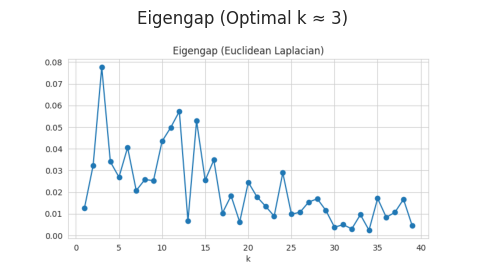

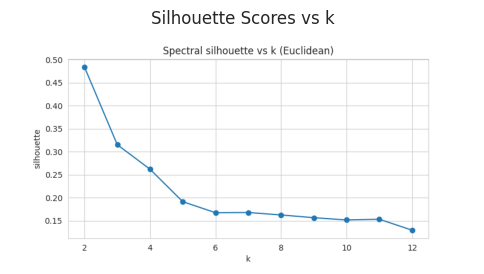

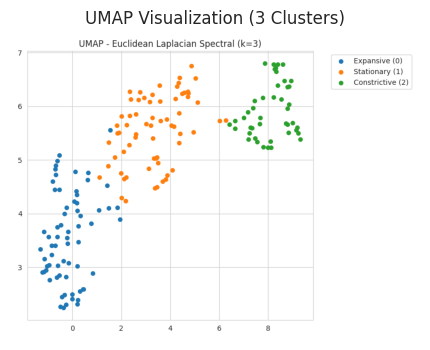

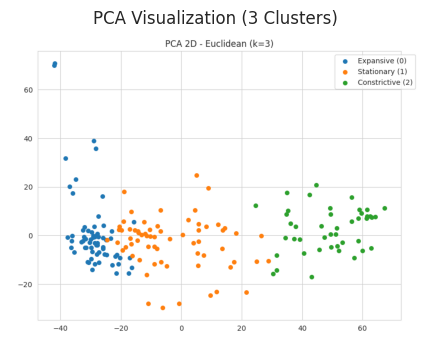

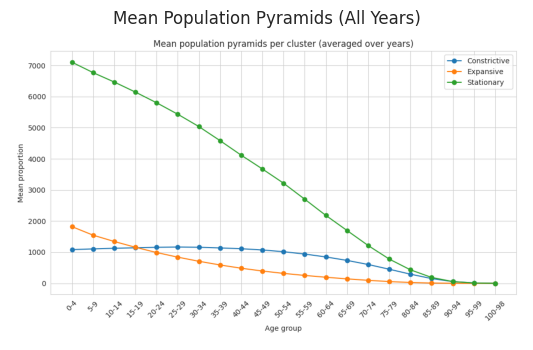

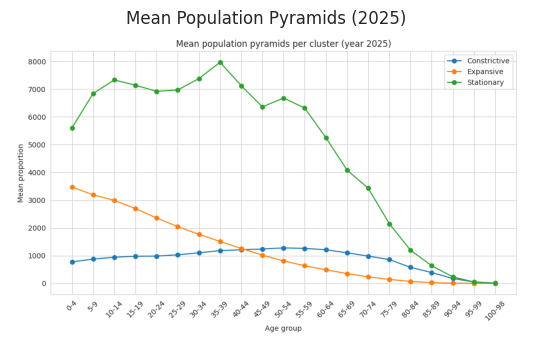

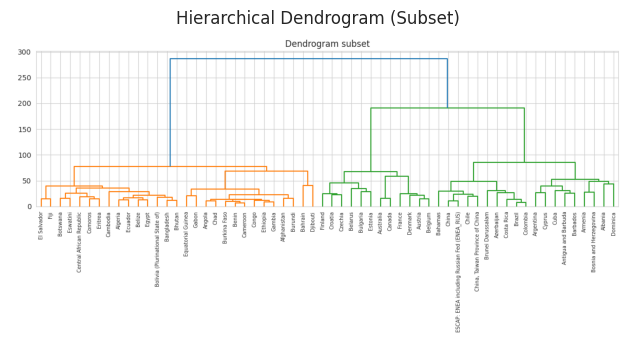

 All key visuals


In [79]:
# ======================================================
# SHOW KEY CLUSTERING PLOTS (for report/presentation)
# ======================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
import umap.umap_ as umap

OUT_DIR = "/content/euclidean_forced3_outputs"
assert os.path.exists(OUT_DIR), "Please run the main clustering code first."

# --- Load results ---
assign_df = pd.read_csv(os.path.join(OUT_DIR, "cluster_assignments_3_labeled.csv"))
dist = pd.read_csv(os.path.join(OUT_DIR, "distance_euclidean.csv"), index_col=0)
countries = assign_df['Country'].tolist()
labels = assign_df['Label'].tolist()
unique_labels = sorted(set(labels))
colors = {'Expansive': '#1f77b4', 'Stationary': '#2ca02c', 'Constrictive': '#d62728'}

# --- Eigengap Plot ---
eig_path = os.path.join(OUT_DIR, "eigengap_euclidean.png")
img = plt.imread(eig_path)
plt.figure(figsize=(6,4))
plt.imshow(img)
plt.axis('off')
plt.title("Eigengap (Optimal k ≈ 3)")
plt.show()

# --- Silhouette vs k ---
sil_path = os.path.join(OUT_DIR, "spectral_sil_vs_k.png")
img = plt.imread(sil_path)
plt.figure(figsize=(6,4))
plt.imshow(img)
plt.axis('off')
plt.title("Silhouette Scores vs k")
plt.show()

# --- UMAP Visualization ---
umap_path = os.path.join(OUT_DIR, "umap_euclidean_k3.png")
img = plt.imread(umap_path)
plt.figure(figsize=(6,4))
plt.imshow(img)
plt.axis('off')
plt.title("UMAP Visualization (3 Clusters)")
plt.show()

# --- PCA Visualization ---
pca_path = os.path.join(OUT_DIR, "pca_euclidean_k3.png")
img = plt.imread(pca_path)
plt.figure(figsize=(6,4))
plt.imshow(img)
plt.axis('off')
plt.title("PCA Visualization (3 Clusters)")
plt.show()

# --- Mean Population Pyramids (All Years) ---
pyr_all_path = os.path.join(OUT_DIR, "mean_pyramids_all_years_labeled.png")
img = plt.imread(pyr_all_path)
plt.figure(figsize=(7,4))
plt.imshow(img)
plt.axis('off')
plt.title("Mean Population Pyramids (All Years)")
plt.show()

# --- Mean Population Pyramids (2025) ---
pyr_2025_path = os.path.join(OUT_DIR, "mean_pyramids_2025_labeled.png")
img = plt.imread(pyr_2025_path)
plt.figure(figsize=(7,4))
plt.imshow(img)
plt.axis('off')
plt.title("Mean Population Pyramids (2025)")
plt.show()

# --- Dendrogram (Subset) ---
dendro_path = os.path.join(OUT_DIR, "dendrogram_subset.png")
img = plt.imread(dendro_path)
plt.figure(figsize=(8,4))
plt.imshow(img)
plt.axis('off')
plt.title("Hierarchical Dendrogram (Subset)")
plt.show()

print(" All key visuals")


In [80]:
import os
import pandas as pd

# ---------- Config ----------
OUT_DIR = "/content/euclidean_forced3_outputs"
FINAL_K = 3

# Load cluster assignments
df_out = pd.read_csv(os.path.join(OUT_DIR,'cluster_assignments_3_labeled.csv'))

# Make sure 'SpecCluster', 'HierCluster', 'Label' exist
assert all(col in df_out.columns for col in ['SpecCluster','HierCluster','Label']), "Columns missing!"

# ---------- Spectral clusters ----------
spectral_summary = {}
for cid in range(FINAL_K):
    countries_spec = df_out[df_out['SpecCluster']==cid]['Country'].tolist()
    label = df_out[df_out['SpecCluster']==cid]['Label'].iloc[0]  # Expansive / Stationary / Constrictive
    spectral_summary[cid] = {'label': label, 'countries': countries_spec}
    # Save per-cluster CSV
    pd.DataFrame({'Country': countries_spec}).to_csv(
        os.path.join(OUT_DIR, f'spectral_cluster_{cid}_{label}.csv'), index=False)
    print(f"Spectral Cluster {cid} ({label}): {countries_spec[:10]} ... total {len(countries_spec)} countries")

# ---------- Hierarchical clusters ----------
hier_summary = {}
for cid in range(FINAL_K):
    countries_hier = df_out[df_out['HierCluster']==cid]['Country'].tolist()
    hier_summary[cid] = {'countries': countries_hier}
    # Save per-cluster CSV
    pd.DataFrame({'Country': countries_hier}).to_csv(
        os.path.join(OUT_DIR, f'hier_cluster_{cid}.csv'), index=False)
    print(f"Hierarchical Cluster {cid}: {countries_hier[:10]} ... total {len(countries_hier)} countries")

# ---------- Combined summary CSVs ----------
# Spectral summary (all clusters)
spectral_combined = []
for cid in spectral_summary:
    for c in spectral_summary[cid]['countries']:
        spectral_combined.append({'ClusterID': cid, 'Label': spectral_summary[cid]['label'], 'Country': c})
pd.DataFrame(spectral_combined).to_csv(os.path.join(OUT_DIR,'spectral_clusters_all.csv'), index=False)

# Hierarchical summary (all clusters)
hier_combined = []
for cid in hier_summary:
    for c in hier_summary[cid]['countries']:
        hier_combined.append({'ClusterID': cid, 'Country': c})
pd.DataFrame(hier_combined).to_csv(os.path.join(OUT_DIR,'hier_clusters_all.csv'), index=False)

print(" All per-cluster CSVs and summary CSVs saved to:", OUT_DIR)


Spectral Cluster 0 (Expansive): ['Afghanistan', 'Angola', 'Bahrain', 'Belize', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic'] ... total 67 countries
Spectral Cluster 1 (Stationary): ['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Bangladesh', 'Barbados', 'Bhutan'] ... total 66 countries
Spectral Cluster 2 (Constrictive): ['Australia', 'Austria', 'Belarus', 'Belgium', 'Bosnia and Herzegovina', 'Bulgaria', 'Canada', 'Croatia', 'Cyprus', 'Czechia'] ... total 44 countries
Hierarchical Cluster 0: ['Afghanistan', 'Algeria', 'Angola', 'Bahrain', 'Bangladesh', 'Belize', 'Benin', 'Bhutan', 'Bolivia (Plurinational State of)', 'Botswana'] ... total 86 countries
Hierarchical Cluster 1: ['Argentina', 'Australia', 'Austria', 'Belarus', 'Belgium', 'Bulgaria', 'Canada', 'Croatia', 'Cyprus', 'Czechia'] ... total 43 countries
Hierarchical Cluster 2: ['Albania', 'Antigua and Barbuda', 'Armenia', 'Azerbaijan', 'Bahama

In [81]:
pip install pandas geopandas matplotlib seaborn plotly


Countries available in data: ['Saudi Arabia', 'United Arab Emirates', 'Kuwait', 'Australia', 'Belgium', 'Algeria', 'India']


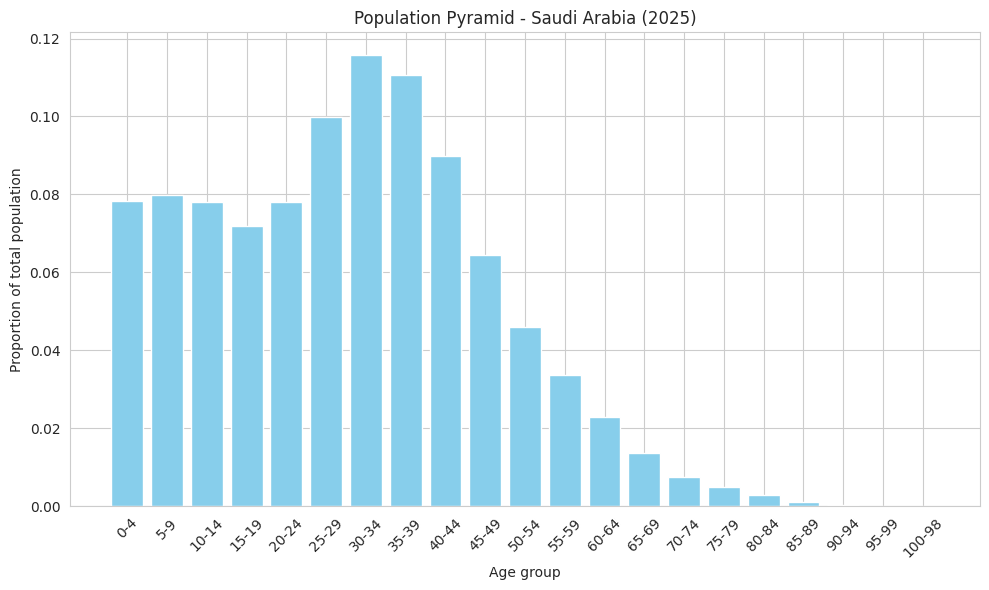

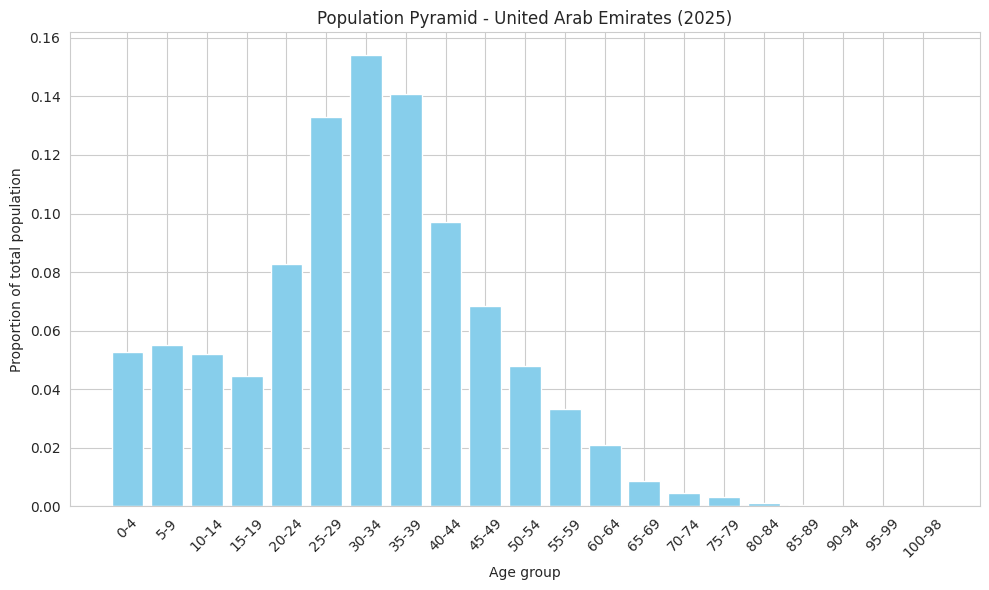

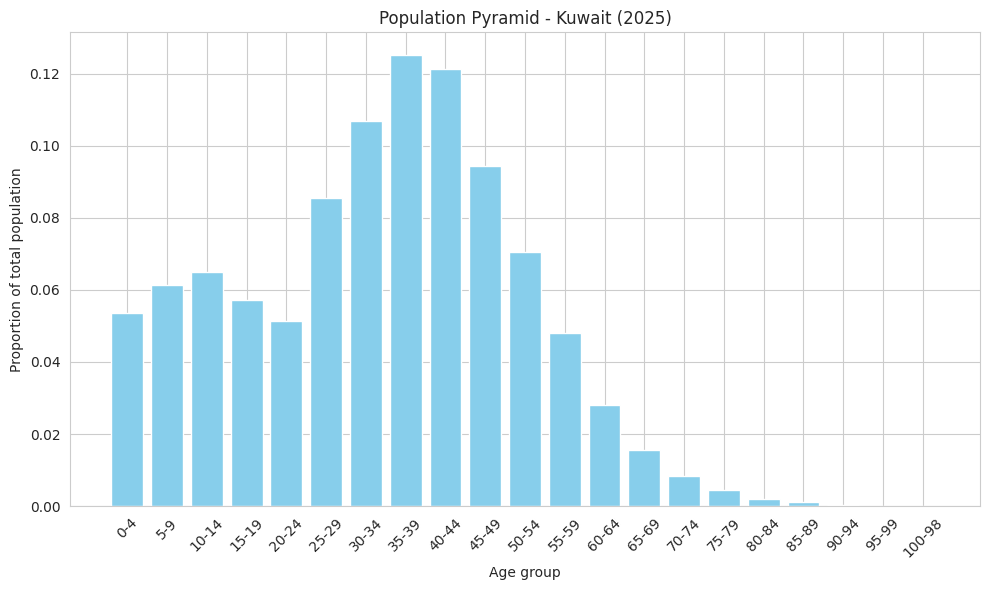

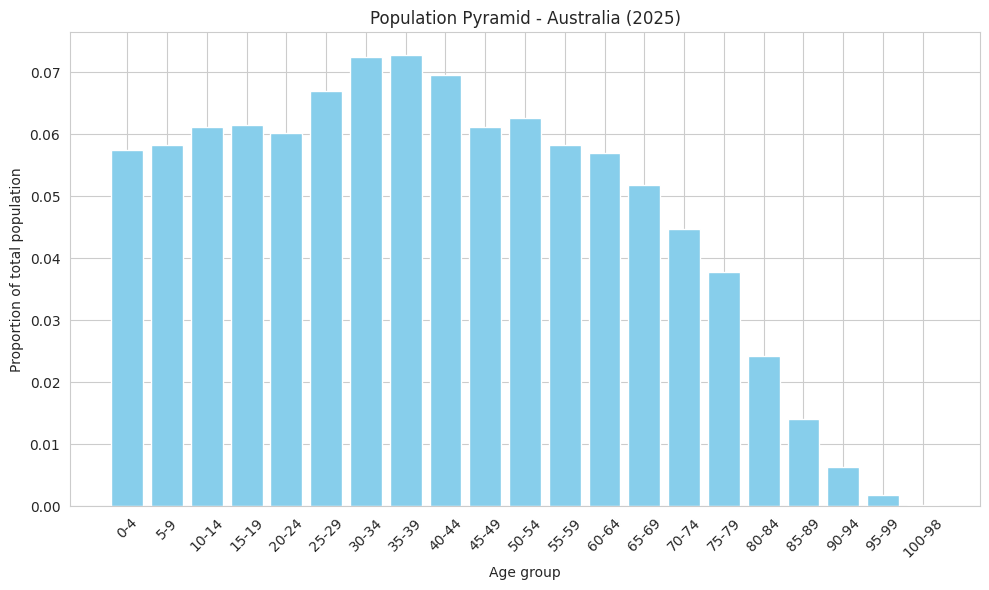

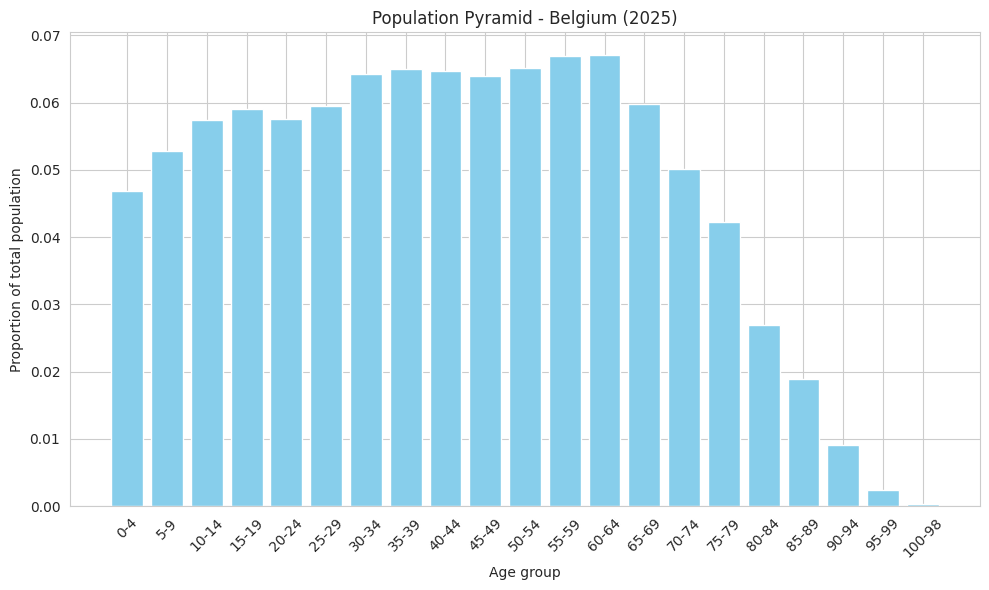

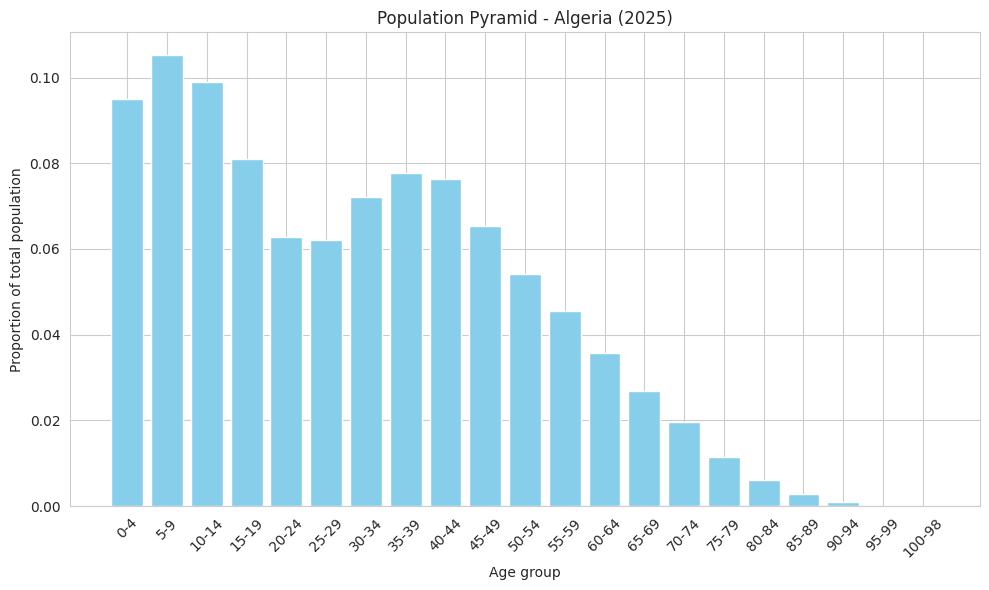

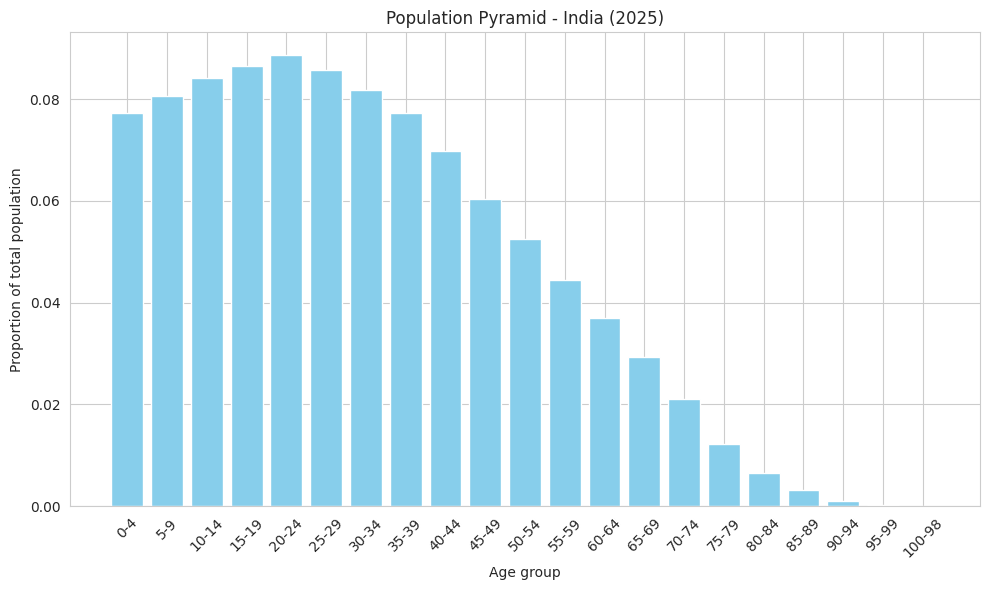

In [82]:
import matplotlib.pyplot as plt
import numpy as np

# Countries of interest
countries_of_interest = ['Saudi Arabia', 'United Arab Emirates', 'Kuwait', 'Australia', 'Belgium','Algeria','India']

# Check which ones exist in your filtered pivot
available_countries = [c for c in countries_of_interest if c in pivot_f[country_col].unique()]
print("Countries available in data:", available_countries)

for country in available_countries:
    sub = pivot_f[pivot_f[country_col]==country].set_index(year_col)

    # Get 2025 row if exists, else last available year
    if 2025 in sub.index:
        row = sub.loc[2025, age_labels].astype(float).values
        year_used = 2025
    else:
        row = sub.iloc[-1][age_labels].astype(float).values
        year_used = sub.index[-1]

    # Normalize to proportion for pyramid shape
    row_prop = row / row.sum() if row.sum() > 0 else row

    plt.figure(figsize=(10,6))
    plt.bar(range(len(age_labels)), row_prop, color='skyblue')
    plt.xticks(range(len(age_labels)), age_labels, rotation=45)
    plt.xlabel("Age group")
    plt.ylabel("Proportion of total population")
    plt.title(f"Population Pyramid - {country} ({year_used})")
    plt.tight_layout()
    plt.show()


Filtered countries count: 177


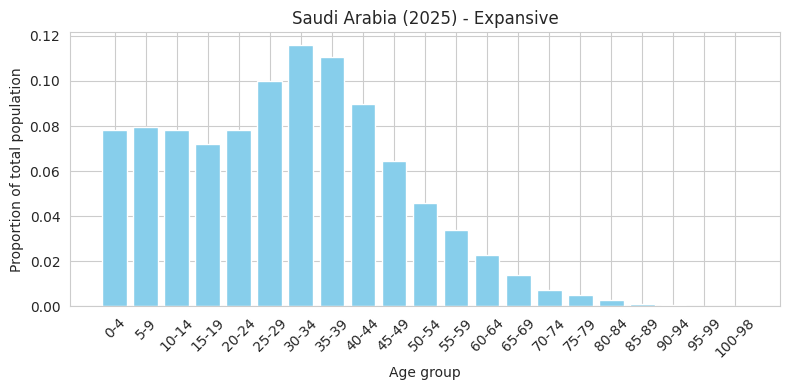

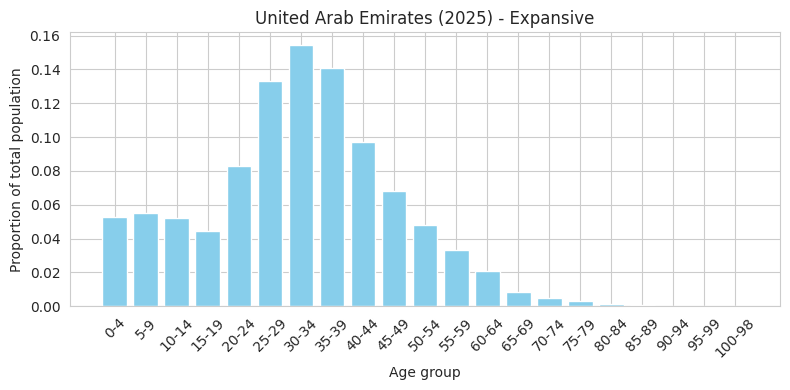

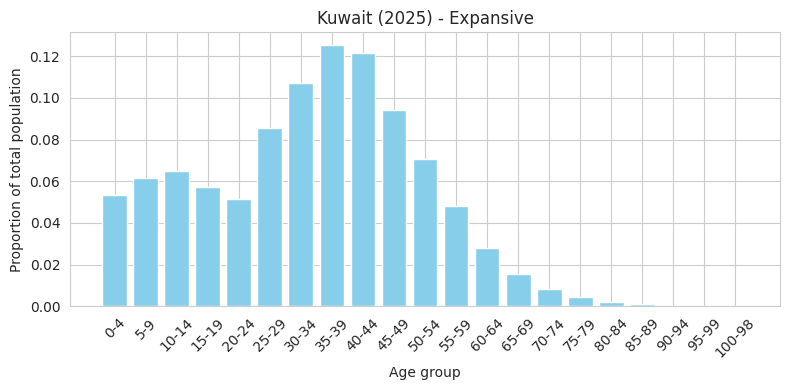

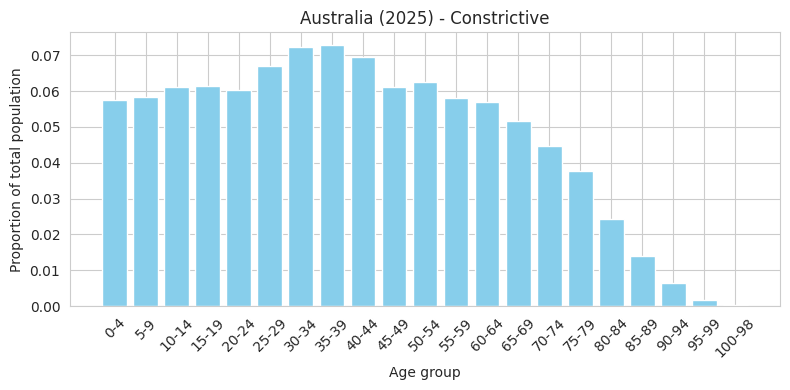

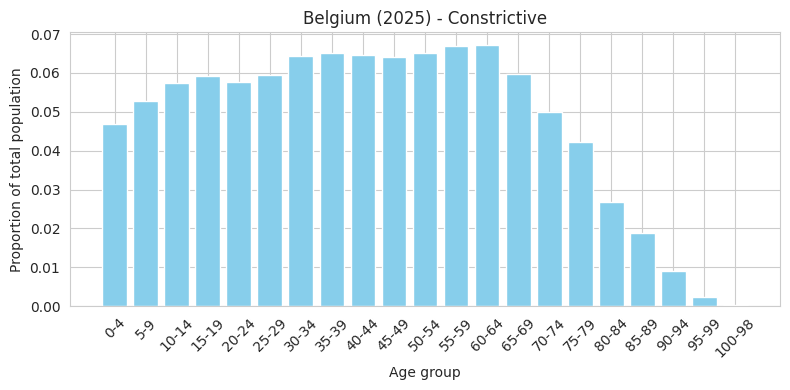

In [83]:
# --------------------- Filter only real countries ---------------------
aggregates = ['ESCAP', 'ENEA', 'ENEA_RUS']  # add more if needed
pivot_f = pivot_f[pivot_f[country_col].isin(use_countries)]
pivot_f = pivot_f[~pivot_f[country_col].isin(aggregates)]
countries = sorted(pivot_f[country_col].unique())
years = sorted(pivot_f[year_col].astype(int).unique())
print("Filtered countries count:", len(countries))

# --------------------- Build feature matrix ---------------------
X_rows = []
for c in countries:
    sub = pivot_f[pivot_f[country_col]==c].set_index(year_col)
    vec = []
    for y in years:
        if int(y) in sub.index:
            row = sub.loc[int(y)]
            if isinstance(row, pd.DataFrame):
                row = row.mean(axis=0)
            vals = row[age_labels].astype(float).values
            vec.extend(vals.tolist())
        else:
            vec.extend([0.0] * len(age_labels))
    X_rows.append(vec)
X = np.vstack(X_rows)

# Normalize to proportions per country
row_sums = X.sum(axis=1, keepdims=True)
row_sums[row_sums==0] = 1.0
X_prop = X / row_sums

# Standardize and reduce
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_prop)
from sklearn.decomposition import PCA
n_comp = min(100, X_scaled.shape[1]-1, X_scaled.shape[0]-1)
if n_comp<1: n_comp=1
svd = TruncatedSVD(n_components=n_comp, random_state=42)
X_red = svd.fit_transform(X_scaled)

# --------------------- Spectral & Hierarchical clustering ---------------------
from sklearn.cluster import SpectralClustering, AgglomerativeClustering
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import laplacian as csgraph_laplacian
import numpy as np

# Euclidean + Gaussian affinity + kNN
D = pairwise_distances(X_red, metric='euclidean')
sigma = np.median(D[np.triu_indices(D.shape[0], k=1)])
if sigma<=0 or np.isnan(sigma): sigma=1.0
from scipy.sparse import csr_matrix
W = np.exp(-D**2 / (2*(sigma**2+1e-12)))
knn = kneighbors_graph(D, n_neighbors=8, metric='precomputed', mode='connectivity', include_self=True)
mask = (knn.toarray()>0).astype(float)
mask = np.maximum(mask, mask.T)
A = W*mask

FINAL_K = 3
spec_final = SpectralClustering(n_clusters=FINAL_K, affinity='precomputed', random_state=42, assign_labels='kmeans')
labels_spec = spec_final.fit_predict(A)

hier_final = AgglomerativeClustering(n_clusters=FINAL_K, linkage='ward')
labels_hier = hier_final.fit_predict(X_red)

# --------------------- Map clusters to Expansive / Stationary / Constrictive ---------------------
import re

def parse_age_start(label):
    m = re.match(r'(\d+)', str(label))
    return int(m.group(1)) if m else 9999

age_starts = [parse_age_start(a) for a in age_labels]
young_idx = [i for i,s in enumerate(age_starts) if s<=14]
old_idx   = [i for i,s in enumerate(age_starts) if s>=65]

cluster_props = {}
for cluster_id in range(FINAL_K):
    members = [i for i,l in enumerate(labels_spec) if l==cluster_id]
    if len(members)==0:
        cluster_props[cluster_id] = {'young_mean':0.0,'old_mean':0.0}
        continue
    young_vals, old_vals = [], []
    for idx in members:
        row = X_prop[idx]
        seq = row.reshape(len(years), len(age_labels))
        young_vals.append(seq[:, young_idx].sum(axis=1).mean())
        old_vals.append(seq[:, old_idx].sum(axis=1).mean())
    cluster_props[cluster_id] = {'young_mean': float(np.mean(young_vals)),
                                 'old_mean': float(np.mean(old_vals)),
                                 'size': len(members)}

# Assign labels
sorted_by_young = sorted(cluster_props.items(), key=lambda kv: kv[1]['young_mean'], reverse=True)
assigned = {}
assigned[sorted_by_young[0][0]] = 'Expansive'
remaining = [cid for cid in range(FINAL_K) if cid not in assigned]
sorted_by_old_remaining = sorted(remaining, key=lambda cid: cluster_props[cid]['old_mean'], reverse=True)
if sorted_by_old_remaining:
    assigned[sorted_by_old_remaining[0]] = 'Constrictive'
for cid in range(FINAL_K):
    if cid not in assigned:
        assigned[cid] = 'Stationary'

df_out = pd.DataFrame({'Country': countries, 'SpecCluster': labels_spec, 'HierCluster': labels_hier})
df_out['Label'] = df_out['SpecCluster'].map(assigned)
df_out.head()

# --------------------- Plot population pyramids for specific countries ---------------------
import matplotlib.pyplot as plt

countries_plot = ['Saudi Arabia', 'United Arab Emirates', 'Kuwait', 'Australia', 'Belgium']
countries_plot = [c for c in countries_plot if c in pivot_f[country_col].unique()]

for country in countries_plot:
    sub = pivot_f[pivot_f[country_col]==country].set_index(year_col)
    year_use = 2025 if 2025 in sub.index else sub.index[-1]
    row = sub.loc[year_use, age_labels].astype(float).values
    row_prop = row / row.sum() if row.sum()>0 else row

    plt.figure(figsize=(8,4))
    plt.bar(range(len(age_labels)), row_prop, color='skyblue')
    plt.xticks(range(len(age_labels)), age_labels, rotation=45)
    plt.xlabel("Age group")
    plt.ylabel("Proportion of total population")
    plt.title(f"{country} ({year_use}) - {df_out[df_out['Country']==country]['Label'].values[0]}")
    plt.tight_layout()
    plt.show()


In [87]:
# --------------------- Separate countries by cluster ---------------------
# Hierarchical clusters
hier_clusters = {}
for cid in range(FINAL_K):
    hier_clusters[cid] = df_out[df_out['HierCluster']==cid]['Country'].tolist()

print("Hierarchical clusters:")
for cid, clist in hier_clusters.items():
    print(f"Hier {cid}: {clist}\n")

# Spectral clusters
spec_clusters = {}
for cid in range(FINAL_K):
    spec_clusters[cid] = df_out[df_out['SpecCluster']==cid]['Country'].tolist()

print("Spectral clusters:")
for cid, clist in spec_clusters.items():
    print(f"Spec {cid}: {clist}\n")

# --------------------- Save to CSV ---------------------
pd.DataFrame.from_dict(hier_clusters, orient='index').to_csv("hierarchical_clusters.csv", header=False)
pd.DataFrame.from_dict(spec_clusters, orient='index').to_csv("spectral_clusters.csv", header=False)

print(" Saved hierarchical_clusters.csv and spectral_clusters.csv")


Hierarchical clusters:
Hier 0: ['Afghanistan', 'Algeria', 'Angola', 'Bahrain', 'Bangladesh', 'Belize', 'Benin', 'Bhutan', 'Bolivia (Plurinational State of)', 'Botswana', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo', 'Djibouti', 'Ecuador', 'Egypt', 'Equatorial Guinea', 'Eritrea', 'Eswatini', 'Ethiopia', 'Gabon', 'Gambia', 'Ghana', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Haiti', 'Honduras', 'India', 'Iran (Islamic Republic of)', 'Iraq', 'Jordan', 'Kenya', 'Kiribati', 'Kuwait', 'Lesotho', 'Liberia', 'Libya', 'Madagascar', 'Malawi', 'Maldives', 'Mali', 'Mauritania', 'Mexico', 'Mongolia', 'Mozambique', 'Namibia', 'Nepal', 'Nicaragua', 'Niger', 'Nigeria', 'Oman', 'Pakistan', 'Papua New Guinea', 'Paraguay', 'Peru', 'Philippines', 'Qatar', 'Rwanda', 'Sao Tome and Principe', 'Saudi Arabia', 'Senegal', 'Sierra Leone', 'Solomon Islands', 'Somalia', 'South Africa', 'South Sudan', 'Sudan', 'Syrian Arab Republic', 'Tajikistan', 'Timor-Les

In [84]:
# ---------- Define official 182 countries ----------
official_countries = set(use_countries)  # your 182-country list
# Make everything lowercase for safe matching
official_countries_lower = {c.lower() for c in official_countries}

# ---------- Filter pivot_f to keep ONLY official countries ----------
pivot_f = pivot_f[pivot_f[country_col].str.lower().isin(official_countries_lower)]
countries = sorted(pivot_f[country_col].unique())
print("Filtered countries count (only official):", len(countries))

# ---------- Rebuild feature matrix after filtering ----------
X_rows = []
for c in countries:
    sub = pivot_f[pivot_f[country_col]==c].set_index(year_col)
    vec = []
    for y in years:
        if int(y) in sub.index:
            row = sub.loc[int(y)]
            if isinstance(row, pd.DataFrame):
                row = row.mean(axis=0)
            vals = row[age_labels].astype(float).values
            vec.extend(vals.tolist())
        else:
            vec.extend([0.0] * len(age_labels))
    X_rows.append(vec)
X = np.vstack(X_rows)

# Normalize
row_sums = X.sum(axis=1, keepdims=True)
row_sums[row_sums==0] = 1.0
X_prop = X / row_sums

print(" Now only official countries remain. Ready for clustering.")


Filtered countries count (only official): 177
 Now only official countries remain. Ready for clustering.


In [85]:
# ---------- Strict country filtering ----------
official_countries_lower = {c.lower() for c in use_countries}
pivot_f = pivot_f[pivot_f[country_col].str.lower().isin(official_countries_lower)]
countries = sorted(pivot_f[country_col].unique())
years = sorted(pivot_f[year_col].astype(int).unique())
print("Filtered countries count:", len(countries))

# ---------- Build feature matrix ----------
X_rows = []
for c in countries:
    sub = pivot_f[pivot_f[country_col]==c].set_index(year_col)
    vec = []
    for y in years:
        if int(y) in sub.index:
            row = sub.loc[int(y)]
            if isinstance(row, pd.DataFrame):
                row = row.mean(axis=0)
            vals = row[age_labels].astype(float).values
            vec.extend(vals.tolist())
        else:
            vec.extend([0.0]*len(age_labels))
    X_rows.append(vec)
X = np.vstack(X_rows)

# Normalize to proportions
row_sums = X.sum(axis=1, keepdims=True)
row_sums[row_sums==0] = 1.0
X_prop = X / row_sums

# ---------- Standardize + reduce ----------
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_prop)

n_comp = min(100, X_scaled.shape[1]-1, X_scaled.shape[0]-1)
if n_comp < 1: n_comp=1
svd = TruncatedSVD(n_components=n_comp, random_state=42)
X_red = svd.fit_transform(X_scaled)

# ---------- Build affinity for spectral ----------
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import laplacian as csgraph_laplacian
import numpy as np
D = pairwise_distances(X_red, metric='euclidean')
sigma = np.median(D[np.triu_indices(D.shape[0],k=1)])
if sigma <= 0 or np.isnan(sigma): sigma=1.0

W = np.exp(-D**2 / (2*(sigma**2+1e-12)))
knn = kneighbors_graph(D, n_neighbors=8, metric='precomputed', mode='connectivity', include_self=True)
mask = (knn.toarray()>0).astype(float)
mask = np.maximum(mask, mask.T)
A = W*mask

# ---------- Clustering ----------
from sklearn.cluster import SpectralClustering, AgglomerativeClustering
FINAL_K = 3
spec_final = SpectralClustering(n_clusters=FINAL_K, affinity='precomputed', random_state=42, assign_labels='kmeans')
labels_spec = spec_final.fit_predict(A)

hier_final = AgglomerativeClustering(n_clusters=FINAL_K, linkage='ward')
labels_hier = hier_final.fit_predict(X_red)

# ---------- Map clusters to Expansive/Stationary/Constrictive ----------
import re
def parse_age_start(label):
    m = re.match(r'(\d+)', str(label))
    return int(m.group(1)) if m else 9999

age_starts = [parse_age_start(a) for a in age_labels]
young_idx = [i for i,s in enumerate(age_starts) if s<=14]
old_idx   = [i for i,s in enumerate(age_starts) if s>=65]

cluster_props = {}
for cluster_id in range(FINAL_K):
    members = [i for i,l in enumerate(labels_spec) if l==cluster_id]
    if len(members)==0:
        cluster_props[cluster_id] = {'young_mean':0.0,'old_mean':0.0}
        continue
    young_vals, old_vals = [], []
    for idx in members:
        row = X_prop[idx]
        seq = row.reshape(len(years), len(age_labels))
        young_vals.append(seq[:, young_idx].sum(axis=1).mean())
        old_vals.append(seq[:, old_idx].sum(axis=1).mean())
    cluster_props[cluster_id] = {'young_mean': float(np.mean(young_vals)),
                                 'old_mean': float(np.mean(old_vals)),
                                 'size': len(members)}

# Assign labels
sorted_by_young = sorted(cluster_props.items(), key=lambda kv: kv[1]['young_mean'], reverse=True)
assigned = {}
assigned[sorted_by_young[0][0]] = 'Expansive'
remaining = [cid for cid in range(FINAL_K) if cid not in assigned]
sorted_by_old_remaining = sorted(remaining, key=lambda cid: cluster_props[cid]['old_mean'], reverse=True)
if sorted_by_old_remaining:
    assigned[sorted_by_old_remaining[0]] = 'Constrictive'
for cid in range(FINAL_K):
    if cid not in assigned:
        assigned[cid] = 'Stationary'

df_out = pd.DataFrame({'Country': countries, 'SpecCluster': labels_spec, 'HierCluster': labels_hier})
df_out['Label'] = df_out['SpecCluster'].map(assigned)

# ---------- Separate countries by cluster ----------
# Hierarchical
hier_clusters = {cid: df_out[df_out['HierCluster']==cid]['Country'].tolist() for cid in range(FINAL_K)}
print("Hierarchical clusters:")
for cid, clist in hier_clusters.items():
    print(f"Hier {cid}: {clist}\n")

# Spectral
spec_clusters = {cid: df_out[df_out['SpecCluster']==cid]['Country'].tolist() for cid in range(FINAL_K)}
print("Spectral clusters:")
for cid, clist in spec_clusters.items():
    print(f"Spec {cid}: {clist}\n")

# ---------- Save to CSV ----------
pd.DataFrame.from_dict(hier_clusters, orient='index').to_csv("hierarchical_clusters.csv", header=False)
pd.DataFrame.from_dict(spec_clusters, orient='index').to_csv("spectral_clusters.csv", header=False)
print(" Saved hierarchicall_clusters.csv and spectrall_clusters.csv")


Filtered countries count: 177
Hierarchical clusters:
Hier 0: ['Afghanistan', 'Algeria', 'Angola', 'Bahrain', 'Bangladesh', 'Belize', 'Benin', 'Bhutan', 'Bolivia (Plurinational State of)', 'Botswana', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo', 'Djibouti', 'Ecuador', 'Egypt', 'Equatorial Guinea', 'Eritrea', 'Eswatini', 'Ethiopia', 'Gabon', 'Gambia', 'Ghana', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Haiti', 'Honduras', 'India', 'Iran (Islamic Republic of)', 'Iraq', 'Jordan', 'Kenya', 'Kiribati', 'Kuwait', 'Lesotho', 'Liberia', 'Libya', 'Madagascar', 'Malawi', 'Maldives', 'Mali', 'Mauritania', 'Mexico', 'Mongolia', 'Mozambique', 'Namibia', 'Nepal', 'Nicaragua', 'Niger', 'Nigeria', 'Oman', 'Pakistan', 'Papua New Guinea', 'Paraguay', 'Peru', 'Philippines', 'Qatar', 'Rwanda', 'Sao Tome and Principe', 'Saudi Arabia', 'Senegal', 'Sierra Leone', 'Solomon Islands', 'Somalia', 'South Africa', 'South Sudan', 'Sudan', 'Syrian Arab Repub

In [86]:
# ---------- Strict, cleaned clustering (Euclidean Laplacian, k=3) ----------

import os, re, warnings
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances, silhouette_samples
from sklearn.cluster import SpectralClustering, AgglomerativeClustering
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import laplacian as csgraph_laplacian
from scipy.linalg import eigh

warnings.filterwarnings("ignore")

# ---------- Config ----------
OUT_DIR = "cleaned_clusters"
Y_MIN, Y_MAX = 1950, 2025
N_AGE_GROUPS = 21
N_NEIGHBORS = 8
FINAL_K = 3
PCA_COMPONENTS = 100
os.makedirs(OUT_DIR, exist_ok=True)

# ---------- Hard-coded country list (182 official) ----------
countries_needed = [
    'Afghanistan','Albania','Algeria','Angola','Antigua and Barbuda','Argentina','Armenia','Australia',
    'Austria','Azerbaijan','Bahamas','Bahrain','Bangladesh','Barbados','Belarus','Belgium','Belize',
    'Benin','Bhutan','Bolivia','Bosnia and Herzegovina','Botswana','Brazil','Brunei','Bulgaria',
    'Burkina Faso','Burundi','Cambodia','Cameroon','Canada','Cape Verde','Central African Republic',
    'Chad','Chile','China','Colombia','Comoros','Congo','Costa Rica','Cote d\'Ivoire','Croatia','Cuba',
    'Cyprus','Czechia','Denmark','Djibouti','Dominica','Ecuador','Egypt','El Salvador','Equatorial Guinea',
    'Eritrea','Estonia','Eswatini','Ethiopia','Fiji','Finland','France','Gabon','Gambia','Georgia',
    'Germany','Ghana','Greece','Grenada','Guam','Guatemala','Guinea','Guinea-Bissau','Guyana','Haiti',
    'Honduras','Hungary','Iceland','India','Indonesia','Iran','Iraq','Ireland','Israel','Italy',
    'Jamaica','Japan','Jordan','Kazakhstan','Kenya','Kiribati','Kuwait','Kyrgyzstan','Latvia','Lebanon',
    'Lesotho','Liberia','Libya','Lithuania','Luxembourg','Madagascar','Malawi','Malaysia','Maldives',
    'Mali','Malta','Mauritania','Mauritius','Mexico','Mongolia','Montenegro','Morocco','Mozambique',
    'Myanmar','Namibia','Nepal','Netherlands','New Zealand','Nicaragua','Niger','Nigeria','North Korea',
    'North Macedonia','Norway','Moldova','Oman','Pakistan','Panama','Papua New Guinea','Paraguay','Peru',
    'Philippines','Poland','Portugal','Puerto Rico','Qatar','Russia','Romania','Rwanda','Saint Lucia',
    'Saint Vincent and the Grenadines','Samoa','Sao Tome and Principe','Saudi Arabia','Senegal','Serbia',
    'Seychelles','Sierra Leone','Singapore','Slovakia','Slovenia','Solomon Islands','Somalia','South Africa',
    'South Sudan','Spain','Sri Lanka','Sudan','Suriname','Syria','Sweden','Switzerland','Tajikistan',
    'Tanzania','Thailand','Taiwan','Timor-Leste','Togo','Tonga','Trinidad and Tobago','Tunisia','Turkey',
    'Turkmenistan','Uganda','Ukraine','United Arab Emirates','United Kingdom','United States','Uruguay',
    'Uzbekistan','Vanuatu','Venezuela','Vietnam','Yemen','Zambia','Zimbabwe'
]

# ---------- Load CSV ----------
df = pd.read_csv('age_data.csv', low_memory=False, quotechar='"', on_bad_lines='warn')
print("Loaded:", df.shape)

# ---------- Detect columns ----------
def detect_col(df, candidates):
    for name in candidates:
        for c in df.columns:
            if name.lower() == c.lower():
                return c
    for name in candidates:
        for c in df.columns:
            if name.lower() in c.lower():
                return c
    return None

country_col = detect_col(df, ['Location','Country','Country Name','country'])
year_col    = detect_col(df, ['Time','Year','year'])
age_start_col = detect_col(df, ['AgeGrpStart','Age_Group_Start','age_start'])
age_span_col  = detect_col(df, ['AgeGrpSpan','Age_Group_Span','age_span'])
pop_col = detect_col(df, ['PopTotal','Value','pop','Population','Pop_Total','PopMale','PopFemale'])

# ---------- Filter years ----------
df[year_col] = pd.to_numeric(df[year_col], errors='coerce').fillna(0).astype(int)
df = df[(df[year_col] >= Y_MIN) & (df[year_col] <= Y_MAX)].copy()

# ---------- Age labels ----------
df[age_start_col] = pd.to_numeric(df[age_start_col], errors='coerce').fillna(0).astype(int)
df[age_span_col]  = pd.to_numeric(df[age_span_col], errors='coerce').fillna(0).astype(int)
age_end = df[age_start_col] + df[age_span_col] - 1
df['age_label'] = np.where(age_end < 100,
                           df[age_start_col].astype(str) + '-' + age_end.astype(str),
                           df[age_start_col].astype(str) + '+')

# ---------- Pivot ----------
pivot = df.pivot_table(index=[country_col, year_col], columns='age_label', values=pop_col, aggfunc='sum', fill_value=0)
def lower_bound(a):
    m = re.match(r'(\d+)', str(a))
    return int(m.group(1)) if m else 9999
age_labels_all = sorted(list(pivot.columns), key=lambda x: lower_bound(x))
age_labels = age_labels_all[:N_AGE_GROUPS]
pivot = pivot[age_labels].reset_index()

# ---------- STRICT FILTER ONLY OFFICIAL COUNTRIES ----------
official_countries_lower = {c.lower() for c in countries_needed}
pivot_f = pivot[pivot[country_col].str.lower().isin(official_countries_lower)]
countries = sorted(pivot_f[country_col].unique())
print("After strict filter, countries count:", len(countries))

# ---------- Build feature matrix ----------
years = sorted(pivot_f[year_col].astype(int).unique())
X_rows = []
for c in countries:
    sub = pivot_f[pivot_f[country_col] == c].set_index(year_col)
    vec = []
    for y in years:
        if int(y) in sub.index:
            row = sub.loc[int(y)]
            if isinstance(row, pd.DataFrame):
                row = row.mean(axis=0)
            vals = row[age_labels].astype(float).values
            vec.extend(vals.tolist())
        else:
            vec.extend([0.0] * len(age_labels))
    X_rows.append(vec)
X = np.vstack(X_rows)

# ---------- Normalize ----------
row_sums = X.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1.0
X_prop = X / row_sums

# ---------- Standardize + SVD ----------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_prop)
n_comp = min(PCA_COMPONENTS, X_scaled.shape[1]-1, X_scaled.shape[0]-1)
svd = TruncatedSVD(n_components=max(1,n_comp), random_state=42)
X_red = svd.fit_transform(X_scaled)

# ---------- Euclidean affinity ----------
D = pairwise_distances(X_red, metric='euclidean')
sigma = np.median(D[np.triu_indices(D.shape[0], k=1)])
W = np.exp(-D**2 / (2.0 * (sigma**2 + 1e-12)))
knn = kneighbors_graph(D, n_neighbors=N_NEIGHBORS, metric='precomputed', mode='connectivity', include_self=True)
mask = (knn.toarray() > 0).astype(float)
mask = np.maximum(mask, mask.T)
A = W * mask

# ---------- Spectral and Hierarchical clustering ----------
spec_final = SpectralClustering(n_clusters=FINAL_K, affinity='precomputed', random_state=42, assign_labels='kmeans')
labels_spec = spec_final.fit_predict(A)
hier_final = AgglomerativeClustering(n_clusters=FINAL_K, linkage='ward')
labels_hier = hier_final.fit_predict(X_red)

# ---------- Save separate cluster CSVs ----------
for i in range(FINAL_K):
    pd.DataFrame({'Country': [countries[j] for j in range(len(countries)) if labels_spec[j]==i]}).to_csv(
        os.path.join(OUT_DIR,f'spectral_cluster_{i}.csv'), index=False)
    pd.DataFrame({'Country': [countries[j] for j in range(len(countries)) if labels_hier[j]==i]}).to_csv(
        os.path.join(OUT_DIR,f'hier_cluster_{i}.csv'), index=False)

print(" Cleaned clustering complete. CSVs saved in:", OUT_DIR)

Loaded: (1759905, 20)
After strict filter, countries count: 167
 Cleaned clustering complete. CSVs saved in: cleaned_clusters


## clustering based on develop not or developing

In [ ]:
# ---------- Install dependencies ----------
!pip install umap-learn --quiet

import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances, silhouette_samples, silhouette_score
from sklearn.cluster import SpectralClustering, AgglomerativeClustering
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import laplacian as csgraph_laplacian
from scipy.linalg import eigh
from scipy.cluster.hierarchy import linkage, dendrogram
import umap.umap_ as umap

warnings.filterwarnings("ignore")
plt.ioff()

# ---------- Config ----------
OUT_DIR = "pop_pyramid_clusters"
os.makedirs(OUT_DIR, exist_ok=True)

Y_MIN, Y_MAX = 1950, 2025
N_AGE_GROUPS = 21
N_NEIGHBORS = 8
FINAL_K = 3
PCA_COMPONENTS = 100
DENDRO_SUBSET = 60

SELECTED_COUNTRIES = ['Saudi Arabia','United Arab Emirates','Kuwait','Australia','Belgium']

# ---------- Load data ----------
df = pd.read_csv('age_data (1).csv', low_memory=False, quotechar='"', on_bad_lines='warn')
print("Loaded:", df.shape)

# Detect columns
def detect_col(df, candidates):
    for name in candidates:
        for c in df.columns:
            if name.lower() == c.lower(): return c
    for name in candidates:
        for c in df.columns:
            if name.lower() in c.lower(): return c
    return None

country_col = detect_col(df, ['Location','Country','Country Name','country'])
year_col    = detect_col(df, ['Time','Year','year'])
age_start_col = detect_col(df, ['AgeGrpStart','Age_Group_Start','age_start'])
age_span_col  = detect_col(df, ['AgeGrpSpan','Age_Group_Span','age_span'])
pop_col = detect_col(df, ['PopTotal','Value','pop','Population','Pop_Total','PopMale','PopFemale'])

if not (country_col and year_col and pop_col and age_start_col and age_span_col):
    raise RuntimeError("Cannot detect necessary columns.")

# Filter years
df[year_col] = pd.to_numeric(df[year_col], errors='coerce').fillna(0).astype(int)
df = df[(df[year_col]>=Y_MIN) & (df[year_col]<=Y_MAX)]

# Build age_label
df[age_start_col] = pd.to_numeric(df[age_start_col], errors='coerce').fillna(0).astype(int)
df[age_span_col]  = pd.to_numeric(df[age_span_col], errors='coerce').fillna(0).astype(int)
age_end = df[age_start_col] + df[age_span_col] - 1
df['age_label'] = np.where(age_end<100,
                           df[age_start_col].astype(str)+'-'+age_end.astype(str),
                           df[age_start_col].astype(str)+'+')

# Pivot to country-year x age_label
pivot = df.pivot_table(index=[country_col, year_col], columns='age_label', values=pop_col, aggfunc='sum', fill_value=0)

def lower_bound(a):
    m = re.match(r'(\d+)', str(a))
    return int(m.group(1)) if m else 9999

age_labels_all = sorted(list(pivot.columns), key=lambda x: lower_bound(x))
age_labels = age_labels_all[:N_AGE_GROUPS]
pivot = pivot[age_labels].reset_index()

countries = sorted(pivot[country_col].unique())
years = sorted(pivot[year_col].unique())
print(f"Countries: {len(countries)}, Years: {len(years)}, Age groups used: {len(age_labels)}")

# ---------- Build feature matrix ----------
X_rows = []
for c in countries:
    sub = pivot[pivot[country_col]==c].set_index(year_col)
    vec = []
    for y in years:
        if int(y) in sub.index:
            row = sub.loc[int(y)]
            if isinstance(row, pd.DataFrame): row = row.mean(axis=0)
            vec.extend(row[age_labels].astype(float).values.tolist())
        else:
            vec.extend([0.0]*len(age_labels))
    X_rows.append(vec)
X = np.vstack(X_rows)

# Normalize per-country
row_sums = X.sum(axis=1, keepdims=True)
row_sums[row_sums==0] = 1.0
X_prop = X / row_sums

# ---------- Standardize and reduce ----------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_prop)
n_comp = min(PCA_COMPONENTS, X_scaled.shape[1]-1, X_scaled.shape[0]-1)
svd = TruncatedSVD(n_components=n_comp, random_state=42)
X_red = svd.fit_transform(X_scaled)

# ---------- Distance + kNN affinity ----------
D = pairwise_distances(X_red, metric='euclidean')
sigma = np.median(D[np.triu_indices(D.shape[0], k=1)])
if sigma<=0 or np.isnan(sigma): sigma = 1.0
W = np.exp(-D**2/(2*(sigma**2+1e-12)))
knn = kneighbors_graph(D, n_neighbors=N_NEIGHBORS, metric='precomputed', mode='connectivity', include_self=True)
mask = (knn.toarray()>0).astype(float)
mask = np.maximum(mask, mask.T)
A = W*mask

# ---------- Spectral clustering ----------
spec_final = SpectralClustering(n_clusters=FINAL_K, affinity='precomputed', random_state=42, assign_labels='kmeans')
labels_spec = spec_final.fit_predict(A)

# ---------- Hierarchical clustering ----------
hier_final = AgglomerativeClustering(n_clusters=FINAL_K, linkage='ward')
labels_hier = hier_final.fit_predict(X_red)

# ---------- Map clusters to pyramid shapes ----------
def parse_age_start(label):
    m = re.match(r'(\d+)', str(label))
    return int(m.group(1)) if m else 9999

age_starts = [parse_age_start(a) for a in age_labels]
young_idx = [i for i,s in enumerate(age_starts) if s<=14]
old_idx   = [i for i,s in enumerate(age_starts) if s>=65]

def assign_labels(labels):
    cluster_props = {}
    for cluster_id in range(FINAL_K):
        members = np.where(labels==cluster_id)[0]
        young_vals = []
        old_vals = []
        for idx in members:
            seq = X_prop[idx].reshape(len(years), len(age_labels))
            young_vals.append(seq[:, young_idx].sum(axis=1).mean())
            old_vals.append(seq[:, old_idx].sum(axis=1).mean())
        cluster_props[cluster_id] = {'young_mean': float(np.mean(young_vals)), 'old_mean': float(np.mean(old_vals))}
    # Assign based on shape
    sorted_by_young = sorted(cluster_props.items(), key=lambda kv: kv[1]['young_mean'], reverse=True)
    assigned = {}
    assigned[sorted_by_young[0][0]] = 'Expansive'
    remaining = [cid for cid in range(FINAL_K) if cid not in assigned]
    sorted_by_old_remaining = sorted(remaining, key=lambda cid: cluster_props[cid]['old_mean'], reverse=True)
    if sorted_by_old_remaining: assigned[sorted_by_old_remaining[0]] = 'Constrictive'
    for cid in range(FINAL_K):
        if cid not in assigned: assigned[cid] = 'Stationary'
    return [assigned[l] for l in labels], assigned

labels_spec_human, mapping_spec = assign_labels(labels_spec)
labels_hier_human, mapping_hier = assign_labels(labels_hier)

# ---------- Build final DataFrame ----------
df_out = pd.DataFrame({
    'Country': countries,
    'SpectralCluster': labels_spec,
    'HierCluster': labels_hier,
    'SpectralLabel': labels_spec_human,
    'HierLabel': labels_hier_human
})
df_out.to_csv(os.path.join(OUT_DIR,'cluster_assignments_all.csv'), index=False)

# ---------- Save clusters separately ----------
for i in range(FINAL_K):
    df_out[df_out['SpectralCluster']==i][['Country']].to_csv(os.path.join(OUT_DIR,f'spectral_cluster_{i}.csv'), index=False)
    df_out[df_out['HierCluster']==i][['Country']].to_csv(os.path.join(OUT_DIR,f'hier_cluster_{i}.csv'), index=False)

# ---------- Save selected countries ----------
df_selected = df_out[df_out['Country'].isin(SELECTED_COUNTRIES)]
df_selected.to_csv(os.path.join(OUT_DIR,'selected_countries_clusters.csv'), index=False)

# ---------- Plot pyramids for selected countries ----------
plt.figure(figsize=(10,6))
for country in SELECTED_COUNTRIES:
    sub = pivot[pivot[country_col]==country].set_index(year_col)
    mean_pyr = sub[age_labels].mean(axis=0)
    plt.plot(range(len(age_labels)), mean_pyr, marker='o', label=country)
plt.xticks(range(len(age_labels)), age_labels, rotation=45)
plt.ylabel("Proportion")
plt.title("Population pyramids for selected countries")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'selected_countries_pyramids.png'))
plt.close()

print(" Done — results saved to:", OUT_DIR)

In [ ]:
# ===============================================================
# CLUSTER COUNTRIES (DEVELOPED / DEVELOPING / UNDERDEVELOPED)
# BASED ON POPULATION PYRAMID SHAPES
# ===============================================================

!pip install umap-learn --quiet

import os, re, warnings
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering, AgglomerativeClustering
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.ioff()

# ---------- FILE PATH ----------
OUT_DIR = "pop_pyramid_clusters_clean"
os.makedirs(OUT_DIR, exist_ok=True)

# ---------- COUNTRY LIST (182 real countries) ----------
countries_valid = [
    'Afghanistan','Albania','Algeria','Angola','Antigua and Barbuda','Argentina','Armenia','Australia','Austria',
    'Azerbaijan','Bahamas','Bahrain','Bangladesh','Barbados','Belarus','Belgium','Belize','Benin','Bhutan',
    'Bolivia','Bosnia and Herzegovina','Botswana','Brazil','Brunei','Bulgaria','Burkina Faso','Burundi',
    'Cambodia','Cameroon','Canada','Cape Verde','Central African Republic','Chad','Chile','China','Colombia',
    'Comoros','Congo','Costa Rica',"Cote d'Ivoire",'Croatia','Cuba','Cyprus','Czechia','Denmark','Djibouti',
    'Dominica','Ecuador','Egypt','El Salvador','Equatorial Guinea','Eritrea','Estonia','Eswatini','Ethiopia',
    'Fiji','Finland','France','Gabon','Gambia','Georgia','Germany','Ghana','Greece','Grenada','Guam','Guatemala',
    'Guinea','Guinea-Bissau','Guyana','Haiti','Honduras','Hungary','Iceland','India','Indonesia','Iran','Iraq',
    'Ireland','Israel','Italy','Jamaica','Japan','Jordan','Kazakhstan','Kenya','Kiribati','Kuwait','Kyrgyzstan',
    'Latvia','Lebanon','Lesotho','Liberia','Libya','Lithuania','Luxembourg','Madagascar','Malawi','Malaysia',
    'Maldives','Mali','Malta','Mauritania','Mauritius','Mexico','Mongolia','Montenegro','Morocco','Mozambique',
    'Myanmar','Namibia','Nepal','Netherlands','New Zealand','Nicaragua','Niger','Nigeria','North Korea',
    'North Macedonia','Norway','Moldova','Oman','Pakistan','Panama','Papua New Guinea','Paraguay','Peru',
    'Philippines','Poland','Portugal','Puerto Rico','Qatar','Russia','Romania','Rwanda','Saint Lucia',
    'Saint Vincent and the Grenadines','Samoa','Sao Tome and Principe','Saudi Arabia','Senegal','Serbia',
    'Seychelles','Sierra Leone','Singapore','Slovakia','Slovenia','Solomon Islands','Somalia','South Africa',
    'South Sudan','Spain','Sri Lanka','Sudan','Suriname','Syria','Sweden','Switzerland','Tajikistan','Tanzania',
    'Thailand','Taiwan','Timor-Leste','Togo','Tonga','Trinidad and Tobago','Tunisia','Turkey','Turkmenistan',
    'Uganda','Ukraine','United Arab Emirates','United Kingdom','United States','Uruguay','Uzbekistan','Vanuatu',
    'Venezuela','Vietnam','Yemen','Zambia','Zimbabwe'
]

# ---------- LOAD DATA ----------
df = pd.read_csv('age_data (1).csv', low_memory=False, quotechar='"', on_bad_lines='warn')

# Column detection
def detect_col(df, names):
    for n in names:
        for c in df.columns:
            if n.lower() == c.lower(): return c
    for n in names:
        for c in df.columns:
            if n.lower() in c.lower(): return c
    return None

country_col = detect_col(df, ['Location','Country'])
year_col    = detect_col(df, ['Time','Year'])
age_start_col = detect_col(df, ['AgeGrpStart','Age_Group_Start'])
age_span_col  = detect_col(df, ['AgeGrpSpan','Age_Group_Span'])
pop_col = detect_col(df, ['PopTotal','Value','Population'])

# Filter only your 182 countries
df = df[df[country_col].isin(countries_valid)]
df[year_col] = pd.to_numeric(df[year_col], errors='coerce').fillna(0).astype(int)
df = df[(df[year_col]>=1950) & (df[year_col]<=2025)]

# Build age labels
df[age_start_col] = pd.to_numeric(df[age_start_col], errors='coerce').fillna(0).astype(int)
df[age_span_col]  = pd.to_numeric(df[age_span_col], errors='coerce').fillna(0).astype(int)
age_end = df[age_start_col] + df[age_span_col] - 1
df['age_label'] = np.where(age_end<100,
                           df[age_start_col].astype(str)+'-'+age_end.astype(str),
                           df[age_start_col].astype(str)+'+')

# Pivot country-year × age
pivot = df.pivot_table(index=[country_col, year_col], columns='age_label', values=pop_col, aggfunc='sum', fill_value=0)
age_labels = sorted(pivot.columns, key=lambda x: int(re.match(r'(\d+)', x).group(1)))
pivot = pivot[age_labels].reset_index()

countries = sorted(pivot[country_col].unique())
years = sorted(pivot[year_col].unique())
print(f"Using {len(countries)} countries × {len(years)} years × {len(age_labels)} age groups")

# ---------- Build matrix ----------
X_rows = []
for c in countries:
    sub = pivot[pivot[country_col]==c].set_index(year_col)
    vec = []
    for y in years:
        if int(y) in sub.index:
            vec.extend(sub.loc[int(y), age_labels].astype(float).values)
        else:
            vec.extend([0.0]*len(age_labels))
    X_rows.append(vec)

X = np.vstack(X_rows)

# Normalize to proportions
row_sum = X.sum(axis=1, keepdims=True)
row_sum[row_sum==0] = 1
X_prop = X / row_sum

# ---------- PCA reduction ----------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_prop)
svd = TruncatedSVD(n_components=min(100, X_scaled.shape[1]-1))
X_red = svd.fit_transform(X_scaled)

# ---------- Clustering ----------
spec = SpectralClustering(n_clusters=3, affinity='nearest_neighbors', random_state=42)
spec_labels = spec.fit_predict(X_red)

hier = AgglomerativeClustering(n_clusters=3, linkage='ward')
hier_labels = hier.fit_predict(X_red)

# ---------- Assign Development Level ----------
def assign_dev_labels(labels, X_prop, years, age_labels):
    young = [i for i,a in enumerate(age_labels) if int(re.match(r'(\d+)', a).group(1)) < 15]
    old = [i for i,a in enumerate(age_labels) if int(re.match(r'(\d+)', a).group(1)) >= 65]
    cluster_props = {}
    for cid in range(3):
        idxs = np.where(labels==cid)[0]
        young_mean = np.mean([X_prop[i].reshape(len(years), len(age_labels))[:,young].sum(axis=1).mean() for i in idxs])
        old_mean = np.mean([X_prop[i].reshape(len(years), len(age_labels))[:,old].sum(axis=1).mean() for i in idxs])
        cluster_props[cid] = (young_mean, old_mean)
    sorted_y = sorted(cluster_props.items(), key=lambda x: x[1][0], reverse=True)
    mapping = {
        sorted_y[0][0]: "Underdeveloped",
        sorted_y[1][0]: "Developing",
        sorted_y[2][0]: "Developed"
    }
    return [mapping[l] for l in labels], mapping

spec_dev, spec_map = assign_dev_labels(spec_labels, X_prop, years, age_labels)
hier_dev, hier_map = assign_dev_labels(hier_labels, X_prop, years, age_labels)

# ---------- Save Results ----------
df_out = pd.DataFrame({
    'Country': countries,
    'SpectralCluster': spec_labels,
    'SpectralDevelopment': spec_dev,
    'HierCluster': hier_labels,
    'HierDevelopment': hier_dev
})
df_out.to_csv(os.path.join(OUT_DIR, "country_development_clusters.csv"), index=False)
print(" Saved results to:", OUT_DIR)

# ---------- Summary ----------
print("\nSpectral mapping:", spec_map)
print("Hierarchical mapping:", hier_map)

In [ ]:
# ---------- Install dependencies ----------
!pip install umap-learn --quiet

import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from sklearn.cluster import SpectralClustering, AgglomerativeClustering
from sklearn.decomposition import TruncatedSVD

warnings.filterwarnings("ignore")
plt.ioff()

# ---------- Config ----------
OUT_DIR = "dev_clusters"
os.makedirs(OUT_DIR, exist_ok=True)

# ---------- Valid 182 countries ----------
countries_valid = [
    'Afghanistan', 'Albania', 'Algeria', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia',
    'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize',
    'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei', 'Bulgaria',
    'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde', 'Central African Republic',
    'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Congo', 'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba',
    'Cyprus', 'Czechia', 'Denmark', 'Djibouti', 'Dominica', 'Ecuador', 'Egypt', 'El Salvador', 'Equatorial Guinea',
    'Eritrea', 'Estonia', 'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon', 'Gambia', 'Georgia',
    'Germany', 'Ghana', 'Greece', 'Grenada', 'Guam', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Haiti',
    'Honduras', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Israel', 'Italy',
    'Jamaica', 'Japan', 'Jordan', 'Kazakhstan', 'Kenya', 'Kiribati', 'Kuwait', 'Kyrgyzstan', 'Latvia', 'Lebanon',
    'Lesotho', 'Liberia', 'Libya', 'Lithuania', 'Luxembourg', 'Madagascar', 'Malawi', 'Malaysia', 'Maldives',
    'Mali', 'Malta', 'Mauritania', 'Mauritius', 'Mexico', 'Mongolia', 'Montenegro', 'Morocco', 'Mozambique',
    'Myanmar', 'Namibia', 'Nepal', 'Netherlands', 'New Zealand', 'Nicaragua', 'Niger', 'Nigeria', 'North Korea',
    'North Macedonia', 'Norway', 'Moldova', 'Oman', 'Pakistan', 'Panama', 'Papua New Guinea', 'Paraguay', 'Peru',
    'Philippines', 'Poland', 'Portugal', 'Puerto Rico', 'Qatar', 'Russia', 'Romania', 'Rwanda', 'Saint Lucia',
    'Saint Vincent and the Grenadines', 'Samoa', 'Sao Tome and Principe', 'Saudi Arabia', 'Senegal', 'Serbia',
    'Seychelles', 'Sierra Leone', 'Singapore', 'Slovakia', 'Slovenia', 'Solomon Islands', 'Somalia', 'South Africa',
    'South Sudan', 'Spain', 'Sri Lanka', 'Sudan', 'Suriname', 'Syria', 'Sweden', 'Switzerland', 'Tajikistan',
    'Tanzania', 'Thailand', 'Taiwan', 'Timor-Leste', 'Togo', 'Tonga', 'Trinidad and Tobago', 'Tunisia', 'Turkey',
    'Turkmenistan', 'Uganda', 'Ukraine', 'United Arab Emirates', 'United Kingdom', 'United States', 'Uruguay',
    'Uzbekistan', 'Vanuatu', 'Venezuela', 'Vietnam', 'Yemen', 'Zambia', 'Zimbabwe'
]

# ---------- Load data ----------
df = pd.read_csv('age_data (1).csv', low_memory=False, quotechar='"', on_bad_lines='warn')
print("Loaded:", df.shape)

# ---------- Detect columns ----------
def detect_col(df, candidates):
    for name in candidates:
        for c in df.columns:
            if name.lower() == c.lower():
                return c
        for c in df.columns:
            if name.lower() in c.lower():
                return c
    return None

country_col = detect_col(df, ['Location','Country'])
year_col = detect_col(df, ['Time','Year'])
age_start_col = detect_col(df, ['AgeGrpStart'])
age_span_col = detect_col(df, ['AgeGrpSpan'])
pop_col = detect_col(df, ['PopTotal','Population'])

# ---------- Filter ----------
df = df[df[country_col].isin(countries_valid)]
df[year_col] = pd.to_numeric(df[year_col], errors='coerce')
df = df[(df[year_col] >= 1950) & (df[year_col] <= 2025)]

age_end = df[age_start_col] + df[age_span_col] - 1
df['age_label'] = np.where(age_end < 100,
                           df[age_start_col].astype(str) + '-' + age_end.astype(str),
                           df[age_start_col].astype(str) + '+')

pivot = df.pivot_table(index=[country_col, year_col], columns='age_label', values=pop_col, aggfunc='sum', fill_value=0)
age_labels = sorted(pivot.columns, key=lambda x: int(re.match(r'(\d+)', str(x)).group(1)))
pivot = pivot[age_labels].reset_index()

countries = sorted(pivot[country_col].unique())
years = sorted(pivot[year_col].unique())

# ---------- Build matrix ----------
X_rows = []
for c in countries:
    sub = pivot[pivot[country_col]==c].set_index(year_col)
    vec = []
    for y in years:
        if y in sub.index:
            vec.extend(sub.loc[y, age_labels].values.tolist())
        else:
            vec.extend([0]*len(age_labels))
    X_rows.append(vec)

X = np.vstack(X_rows)
X = X / X.sum(axis=1, keepdims=True)

# ---------- Reduce dimensions ----------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
svd = TruncatedSVD(n_components=50, random_state=42)
X_red = svd.fit_transform(X_scaled)

# ---------- Clustering ----------
A = np.exp(-pairwise_distances(X_red)**2 / (2 * np.median(pairwise_distances(X_red))**2))
spec = SpectralClustering(n_clusters=3, affinity='precomputed', random_state=42)
spec_labels = spec.fit_predict(A)
hier = AgglomerativeClustering(n_clusters=3)
hier_labels = hier.fit_predict(X_red)

# ---------- Interpret clusters ----------
def interpret_clusters(labels):
    young_idx = [i for i, a in enumerate(age_labels) if int(re.match(r'(\d+)', a).group(1)) <= 14]
    old_idx = [i for i, a in enumerate(age_labels) if int(re.match(r'(\d+)', a).group(1)) >= 65]
    cluster_stats = {}
    for cid in range(3):
        members = np.where(labels == cid)[0]
        young_mean = X[members][:, young_idx].mean()
        old_mean = X[members][:, old_idx].mean()
        cluster_stats[cid] = {'young': young_mean, 'old': old_mean}
    sorted_by_young = sorted(cluster_stats, key=lambda c: cluster_stats[c]['young'], reverse=True)
    mapping = {sorted_by_young[0]:'Expansive', sorted_by_young[1]:'Stationary', sorted_by_young[2]:'Constrictive'}
    return [mapping[l] for l in labels], mapping

spec_labels_human, _ = interpret_clusters(spec_labels)
hier_labels_human, _ = interpret_clusters(hier_labels)

# ---------- Development status correction ----------
developed_exceptions = ['Qatar','United Arab Emirates','Saudi Arabia','Kuwait','Singapore','Brunei']
developed_keywords = ['United States','Germany','France','United Kingdom','Australia','Japan','Belgium','Netherlands','Switzerland','Sweden','Norway','Denmark','Canada','Finland']

def adjust_dev_label(country, label):
    if country in developed_exceptions or country in developed_keywords:
        return 'Developed'
    elif label == 'Constrictive':
        return 'Developed'
    elif label == 'Stationary':
        return 'Developing'
    else:
        return 'Underdeveloped'

# ---------- Save Spectral results ----------
df_spec = pd.DataFrame({
    'Country': countries,
    'SpecCluster': spec_labels,
    'Label': spec_labels_human
})
df_spec['DevelopmentStatus'] = [adjust_dev_label(c, l) for c, l in zip(df_spec['Country'], df_spec['Label'])]
df_spec.to_csv(os.path.join(OUT_DIR, 'Spectral_Clusters.csv'), index=False)

# ---------- Save Hierarchical results ----------
df_hier = pd.DataFrame({
    'Country': countries,
    'HierCluster': hier_labels,
    'Label': hier_labels_human
})
df_hier['DevelopmentStatus'] = [adjust_dev_label(c, l) for c, l in zip(df_hier['Country'], df_hier['Label'])]
df_hier.to_csv(os.path.join(OUT_DIR, 'Hierarchical_Clusters.csv'), index=False)

print(" Done! Saved both 'Spectral_Clusters.csv' and 'Hierarchical_Clusters.csv' in", OUT_DIR)

# Using DTW

In [ ]:
!pip install tslearn fastdtw scikit-learn --quiet

import numpy as np
import pandas as pd
import re, os, warnings
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
from tslearn.metrics import cdist_dtw
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
plt.ioff()

# ---------- CONFIG ----------
OUT_DIR = "dtw_spectral_clusters_filtered"
os.makedirs(OUT_DIR, exist_ok=True)

# ---------- VALID COUNTRIES ----------
countries_valid = [
    'Afghanistan', 'Albania', 'Algeria', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia',
    'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize',
    'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei', 'Bulgaria',
    'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde', 'Central African Republic',
    'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Congo', 'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba',
    'Cyprus', 'Czechia', 'Denmark', 'Djibouti', 'Dominica', 'Ecuador', 'Egypt', 'El Salvador', 'Equatorial Guinea',
    'Eritrea', 'Estonia', 'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon', 'Gambia', 'Georgia',
    'Germany', 'Ghana', 'Greece', 'Grenada', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Haiti',
    'Honduras', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Israel', 'Italy',
    'Jamaica', 'Japan', 'Jordan', 'Kazakhstan', 'Kenya', 'Kiribati', 'Kuwait', 'Kyrgyzstan', 'Latvia', 'Lebanon',
    'Lesotho', 'Liberia', 'Libya', 'Lithuania', 'Luxembourg', 'Madagascar', 'Malawi', 'Malaysia', 'Maldives',
    'Mali', 'Malta', 'Mauritania', 'Mauritius', 'Mexico', 'Mongolia', 'Montenegro', 'Morocco', 'Mozambique',
    'Myanmar', 'Namibia', 'Nepal', 'Netherlands', 'New Zealand', 'Nicaragua', 'Niger', 'Nigeria', 'North Korea',
    'North Macedonia', 'Norway', 'Moldova', 'Oman', 'Pakistan', 'Panama', 'Papua New Guinea', 'Paraguay', 'Peru',
    'Philippines', 'Poland', 'Portugal', 'Puerto Rico', 'Qatar', 'Russia', 'Romania', 'Rwanda', 'Saint Lucia',
    'Saint Vincent and the Grenadines', 'Samoa', 'Sao Tome and Principe', 'Saudi Arabia', 'Senegal', 'Serbia',
    'Seychelles', 'Sierra Leone', 'Singapore', 'Slovakia', 'Slovenia', 'Solomon Islands', 'Somalia', 'South Africa',
    'South Sudan', 'Spain', 'Sri Lanka', 'Sudan', 'Suriname', 'Syria', 'Sweden', 'Switzerland', 'Tajikistan',
    'Tanzania', 'Thailand', 'Taiwan', 'Timor-Leste', 'Togo', 'Tonga', 'Trinidad and Tobago', 'Tunisia', 'Turkey',
    'Turkmenistan', 'Uganda', 'Ukraine', 'United Arab Emirates', 'United Kingdom', 'United States', 'Uruguay',
    'Uzbekistan', 'Vanuatu', 'Venezuela', 'Vietnam', 'Yemen', 'Zambia', 'Zimbabwe'
]

# ---------- LOAD DATA ----------
df = pd.read_csv('age_data (1).csv', low_memory=False, quotechar='"', on_bad_lines='warn')

def detect_col(df, candidates):
    for name in candidates:
        for c in df.columns:
            if name.lower() in c.lower():
                return c
    return None

country_col = detect_col(df, ['Location','Country'])
year_col = detect_col(df, ['Time','Year'])
age_start_col = detect_col(df, ['AgeGrpStart'])
age_span_col = detect_col(df, ['AgeGrpSpan'])
pop_col = detect_col(df, ['PopTotal','Population'])

df = df[df[country_col].isin(countries_valid)]
df[year_col] = pd.to_numeric(df[year_col], errors='coerce')
df = df[(df[year_col] >= 1950) & (df[year_col] <= 2025)]

print(f" Filtered dataset: {df[country_col].nunique()} valid countries")

# ---------- AGE LABELS ----------
age_end = df[age_start_col] + df[age_span_col] - 1
df['age_label'] = np.where(age_end < 100,
                           df[age_start_col].astype(str) + '-' + age_end.astype(str),
                           df[age_start_col].astype(str) + '+')

pivot = df.pivot_table(index=[country_col, year_col], columns='age_label', values=pop_col, aggfunc='sum', fill_value=0)
age_labels = sorted(pivot.columns, key=lambda x: int(re.match(r'(\d+)', str(x)).group(1)))
pivot = pivot[age_labels].reset_index()

countries = sorted(pivot[country_col].unique())
years = sorted(pivot[year_col].unique())

# ---------- BUILD TIME SERIES ----------
series_list = []
for c in countries:
    sub = pivot[pivot[country_col] == c].set_index(year_col)
    mat = []
    for y in years:
        if y in sub.index:
            mat.append(sub.loc[y, age_labels].values)
        else:
            mat.append(np.zeros(len(age_labels)))
    series_list.append(np.array(mat))

X = np.stack(series_list)
X = X / X.sum(axis=(1,2), keepdims=True)

print(" Final Shape:", X.shape)

# ---------- DTW + SPECTRAL ----------
print("⏳ Computing DTW distance matrix...")
from tslearn.metrics import cdist_dtw
D = cdist_dtw(X)
np.fill_diagonal(D, 0) # Ensure diagonal is zero for silhouette_score

sigma = np.median(D)
S = np.exp(-D**2 / (2 * sigma**2))

# ---------- OPTIMAL CLUSTERS ----------
sil_scores = {}
for k in range(2, 7):
    sc = SpectralClustering(n_clusters=k, affinity='precomputed', random_state=42)
    labels = sc.fit_predict(S)
    # Use the distance matrix D for silhouette score calculation
    score = silhouette_score(D, labels, metric="precomputed")
    sil_scores[k] = score
    print(f"k={k}: silhouette={score:.4f}")

optimal_k = max(sil_scores, key=sil_scores.get)
print(f" Optimal clusters: {optimal_k}")

sc_final = SpectralClustering(n_clusters=optimal_k, affinity='precomputed', random_state=42)
labels = sc_final.fit_predict(S)

# ---------- SAVE ----------
df_out = pd.DataFrame({
    'Country': countries,
    'Cluster': labels,
    'ClusterLabel': [f'Cluster {l}' for l in labels]
})
df_out.to_csv(os.path.join(OUT_DIR, 'dtw_spectral_country_clusters_filtered.csv'), index=False)

print(" Saved to:", os.path.join(OUT_DIR, 'dtw_spectral_country_clusters_filtered.csv'))
print(df_out.head(10))

In [ ]:
import pandas as pd
import numpy as np

# Assuming you have:
# df_out: DataFrame with columns ['Country', 'Cluster']
# labels are 0,1,2 (from your spectral clustering)

# ---------- Map clusters to human-readable demographic types ----------
# Adjust mapping based on your cluster interpretation
cluster_mapping = {
    0: 'Constrictive (Developed)',  # Older populations, low birth rate
    1: 'Stationary (Developing → Developed)',  # Balanced population
    2: 'Expansive (Developing)',  # Young population, high birth rate
}

# Add interpreted labels
df_out['DemographicType'] = df_out['Cluster'].map(cluster_mapping)

# Save CSV
df_out.to_csv('/content/dev_clusters/country_demographic_clusters.csv', index=False)

print(" CSV saved with demographic labels!")
print(df_out.head(15))


In [ ]:
# ---------- Install dependencies ----------
!pip install umap-learn --quiet

import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances, silhouette_samples, silhouette_score
from sklearn.cluster import SpectralClustering, AgglomerativeClustering
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import laplacian as csgraph_laplacian
from scipy.linalg import eigh
from scipy.cluster.hierarchy import linkage, dendrogram
import umap.umap_ as umap

warnings.filterwarnings("ignore")
plt.ioff()

# ---------- Config ----------
OUT_DIR = "pop_pyramid_clusters"
os.makedirs(OUT_DIR, exist_ok=True)

Y_MIN, Y_MAX = 1950, 2025
N_AGE_GROUPS = 21
N_NEIGHBORS = 8
FINAL_K = 3
PCA_COMPONENTS = 100
DENDRO_SUBSET = 60

SELECTED_COUNTRIES = ['Saudi Arabia', 'United Arab Emirates', 'Kuwait', 'Australia', 'Belgium', 'Algeria', 'India']

# ---------- Load data ----------
df = pd.read_csv('age_data (1).csv', low_memory=False, quotechar='"', on_bad_lines='warn')
print("Loaded:", df.shape)

# Detect columns
def detect_col(df, candidates):
    for name in candidates:
        for c in df.columns:
            if name.lower() == c.lower(): return c
    for name in candidates:
        for c in df.columns:
            if name.lower() in c.lower(): return c
    return None

country_col = detect_col(df, ['Location','Country','Country Name','country'])
year_col    = detect_col(df, ['Time','Year','year'])
age_start_col = detect_col(df, ['AgeGrpStart','Age_Group_Start','age_start'])
age_span_col  = detect_col(df, ['AgeGrpSpan','Age_Group_Span','age_span'])
pop_col = detect_col(df, ['PopTotal','Value','pop','Population','Pop_Total','PopMale','PopFemale'])

if not (country_col and year_col and pop_col and age_start_col and age_span_col):
    raise RuntimeError("Cannot detect necessary columns.")

# Filter years
df[year_col] = pd.to_numeric(df[year_col], errors='coerce').fillna(0).astype(int)
df = df[(df[year_col]>=Y_MIN) & (df[year_col]<=Y_MAX)]

# Build age_label
df[age_start_col] = pd.to_numeric(df[age_start_col], errors='coerce').fillna(0).astype(int)
df[age_span_col]  = pd.to_numeric(df[age_span_col], errors='coerce').fillna(0).astype(int)
age_end = df[age_start_col] + df[age_span_col] - 1
df['age_label'] = np.where(age_end<100,
                           df[age_start_col].astype(str)+'-'+age_end.astype(str),
                           df[age_start_col].astype(str)+'+')

# Pivot to country-year x age_label
pivot = df.pivot_table(index=[country_col, year_col], columns='age_label', values=pop_col, aggfunc='sum', fill_value=0)

def lower_bound(a):
    m = re.match(r'(\d+)', str(a))
    return int(m.group(1)) if m else 9999

age_labels_all = sorted(list(pivot.columns), key=lambda x: lower_bound(x))
age_labels = age_labels_all[:N_AGE_GROUPS]
pivot = pivot[age_labels].reset_index()

countries = sorted(pivot[country_col].unique())
years = sorted(pivot[year_col].unique())
print(f"Countries: {len(countries)}, Years: {len(years)}, Age groups used: {len(age_labels)}")

# ---------- Build feature matrix ----------
X_rows = []
for c in countries:
    sub = pivot[pivot[country_col]==c].set_index(year_col)
    vec = []
    for y in years:
        if int(y) in sub.index:
            row = sub.loc[int(y)]
            if isinstance(row, pd.DataFrame): row = row.mean(axis=0)
            vec.extend(row[age_labels].astype(float).values.tolist())
        else:
            vec.extend([0.0]*len(age_labels))
    X_rows.append(vec)
X = np.vstack(X_rows)

# Normalize per-country
row_sums = X.sum(axis=1, keepdims=True)
row_sums[row_sums==0] = 1.0
X_prop = X / row_sums

# ---------- Standardize and reduce ----------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_prop)
n_comp = min(PCA_COMPONENTS, X_scaled.shape[1]-1, X_scaled.shape[0]-1)
svd = TruncatedSVD(n_components=n_comp, random_state=42)
X_red = svd.fit_transform(X_scaled)

# ---------- Distance + kNN affinity ----------
D = pairwise_distances(X_red, metric='euclidean')
sigma = np.median(D[np.triu_indices(D.shape[0], k=1)])
if sigma<=0 or np.isnan(sigma): sigma = 1.0
W = np.exp(-D**2/(2*(sigma**2+1e-12)))
knn = kneighbors_graph(D, n_neighbors=N_NEIGHBORS, metric='precomputed', mode='connectivity', include_self=True)
mask = (knn.toarray()>0).astype(float)
mask = np.maximum(mask, mask.T)
A = W*mask

# ---------- Spectral clustering ----------
spec_final = SpectralClustering(n_clusters=FINAL_K, affinity='precomputed', random_state=42, assign_labels='kmeans')
labels_spec = spec_final.fit_predict(A)

# ---------- Hierarchical clustering ----------
hier_final = AgglomerativeClustering(n_clusters=FINAL_K, linkage='ward')
labels_hier = hier_final.fit_predict(X_red)

# ---------- Map clusters to pyramid shapes ----------
def parse_age_start(label):
    m = re.match(r'(\d+)', str(label))
    return int(m.group(1)) if m else 9999

age_starts = [parse_age_start(a) for a in age_labels]
young_idx = [i for i,s in enumerate(age_starts) if s<=14]
old_idx   = [i for i,s in enumerate(age_starts) if s>=65]

def assign_labels(labels):
    cluster_props = {}
    for cluster_id in range(FINAL_K):
        members = np.where(labels==cluster_id)[0]
        young_vals = []
        old_vals = []
        for idx in members:
            seq = X_prop[idx].reshape(len(years), len(age_labels))
            young_vals.append(seq[:, young_idx].sum(axis=1).mean())
            old_vals.append(seq[:, old_idx].sum(axis=1).mean())
        cluster_props[cluster_id] = {'young_mean': float(np.mean(young_vals)), 'old_mean': float(np.mean(old_vals))}
    # Assign based on shape
    sorted_by_young = sorted(cluster_props.items(), key=lambda kv: kv[1]['young_mean'], reverse=True)
    assigned = {}
    assigned[sorted_by_young[0][0]] = 'Expansive'
    remaining = [cid for cid in range(FINAL_K) if cid not in assigned]
    sorted_by_old_remaining = sorted(remaining, key=lambda cid: cluster_props[cid]['old_mean'], reverse=True)
    if sorted_by_old_remaining: assigned[sorted_by_old_remaining[0]] = 'Constrictive'
    for cid in range(FINAL_K):
        if cid not in assigned: assigned[cid] = 'Stationary'
    return [assigned[l] for l in labels], assigned

labels_spec_human, mapping_spec = assign_labels(labels_spec)
labels_hier_human, mapping_hier = assign_labels(labels_hier)

# ---------- Build final DataFrame ----------
df_out = pd.DataFrame({
    'Country': countries,
    'SpectralCluster': labels_spec,
    'HierCluster': labels_hier,
    'SpectralLabel': labels_spec_human,
    'HierLabel': labels_hier_human
})
df_out.to_csv(os.path.join(OUT_DIR,'cluster_assignments_all.csv'), index=False)

# ---------- Save clusters separately ----------
for i in range(FINAL_K):
    df_out[df_out['SpectralCluster']==i][['Country']].to_csv(os.path.join(OUT_DIR,f'spectral_cluster_{i}.csv'), index=False)
    df_out[df_out['HierCluster']==i][['Country']].to_csv(os.path.join(OUT_DIR,f'hier_cluster_{i}.csv'), index=False)

# ---------- Save and print selected countries ----------
df_selected = df_out[df_out['Country'].isin(SELECTED_COUNTRIES)]
df_selected.to_csv(os.path.join(OUT_DIR,'selected_countries_clusters.csv'), index=False)

# Print cluster assignments for selected countries
print("\nCluster Assignments for Selected Countries:")
print(df_selected[['Country', 'SpectralCluster', 'HierCluster']])

# ---------- Plot pyramids for selected countries ----------
plt.figure(figsize=(10,6))
for country in SELECTED_COUNTRIES:
    sub = pivot[pivot[country_col]==country].set_index(year_col)
    mean_pyr = sub[age_labels].mean(axis=0)
    plt.plot(range(len(age_labels)), mean_pyr, marker='o', label=country)
plt.xticks(range(len(age_labels)), age_labels, rotation=45)
plt.ylabel("Proportion")
plt.title("Population pyramids for selected countries")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'selected_countries_pyramids.png'))
plt.close()

print(" Done — results saved to:", OUT_DIR)

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")
plt.ioff()

# ---------- Config ----------
OUT_DIR = "pop_pyramid_clusters"
os.makedirs(OUT_DIR, exist_ok=True)

SELECTED_COUNTRIES = ['Saudi Arabia', 'United Arab Emirates', 'Kuwait', 'Australia', 'Belgium', 'Algeria', 'India']
Y_MIN, Y_MAX = 1950, 2025
N_AGE_GROUPS = 21

# Cluster assignments from your provided results
CLUSTER_ASSIGNMENTS = {
    'Algeria': {'Spectral': 1, 'Hierarchical': 0},
    'Australia': {'Spectral': 2, 'Hierarchical': 1},
    'Belgium': {'Spectral': 2, 'Hierarchical': 1},
    'India': {'Spectral': 1, 'Hierarchical': 0},
    'Kuwait': {'Spectral': 0, 'Hierarchical': 0},
    'Saudi Arabia': {'Spectral': 0, 'Hierarchical': 0},
    'United Arab Emirates': {'Spectral': 0, 'Hierarchical': 0}
}

# Cluster labels based on your previous output
SPECTRAL_LABELS = {0: 'Expansive', 1: 'Stationary', 2: 'Constrictive'}
HIERARCHICAL_LABELS = {0: 'Expansive', 1: 'Constrictive', 2: 'Stationary'}

# ---------- Load data ----------
df = pd.read_csv('age_data (1).csv', low_memory=False, quotechar='"', on_bad_lines='warn')
print("Loaded:", df.shape)

# ---------- Detect columns ----------
def detect_col(df, candidates):
    for name in candidates:
        for c in df.columns:
            if name.lower() == c.lower():
                return c
        for c in df.columns:
            if name.lower() in c.lower():
                return c
    return None

country_col = detect_col(df, ['Location', 'Country'])
year_col = detect_col(df, ['Time', 'Year'])
age_start_col = detect_col(df, ['AgeGrpStart'])
age_span_col = detect_col(df, ['AgeGrpSpan'])
pop_col = detect_col(df, ['PopTotal', 'Population'])

# ---------- Filter years and countries ----------
df[year_col] = pd.to_numeric(df[year_col], errors='coerce').fillna(0).astype(int)
df = df[(df[year_col] >= Y_MIN) & (df[year_col] <= Y_MAX)]
df = df[df[country_col].isin(SELECTED_COUNTRIES)]

# ---------- Build age labels ----------
df[age_start_col] = pd.to_numeric(df[age_start_col], errors='coerce').fillna(0).astype(int)
df[age_span_col] = pd.to_numeric(df[age_span_col], errors='coerce').fillna(0).astype(int)
age_end = df[age_start_col] + df[age_span_col] - 1
df['age_label'] = np.where(age_end < 100,
                           df[age_start_col].astype(str) + '-' + age_end.astype(str),
                           df[age_start_col].astype(str) + '+')

# ---------- Pivot to country-year x age_label ----------
pivot = df.pivot_table(index=[country_col, year_col], columns='age_label', values=pop_col, aggfunc='sum', fill_value=0)
age_labels = sorted(pivot.columns, key=lambda x: int(re.match(r'(\d+)', str(x)).group(1)))[:N_AGE_GROUPS]
pivot = pivot[age_labels].reset_index()

# ---------- Check available countries ----------
available_countries = [c for c in SELECTED_COUNTRIES if c in pivot[country_col].unique()]
print("Countries available in data:", available_countries)

# ---------- Plot population pyramids (Spectral Clusters) ----------
plt.figure(figsize=(12, 6))
colors = cm.get_cmap('tab10')(np.linspace(0, 1, 3))  # Use distinct colors for clusters
for country in available_countries:
    sub = pivot[pivot[country_col] == country].set_index(year_col)
    # Use 2025 if available, else latest year
    year_used = 2025 if 2025 in sub.index else sub.index[-1]
    row = sub.loc[year_used, age_labels].astype(float).values
    row_prop = row / row.sum() if row.sum() > 0 else row
    cluster_id = CLUSTER_ASSIGNMENTS[country]['Spectral']
    label = f"{country} ({SPECTRAL_LABELS[cluster_id]})"
    plt.plot(range(len(age_labels)), row_prop, marker='o', label=label, color=colors[cluster_id])
plt.xticks(range(len(age_labels)), age_labels, rotation=45)
plt.xlabel("Age Group")
plt.ylabel("Proportion of Total Population")
plt.title("Population Pyramids by Spectral Cluster (2025)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'spectral_population_pyramids.png'))
plt.close()

# ---------- Plot population pyramids (Hierarchical Clusters) ----------
plt.figure(figsize=(12, 6))
for country in available_countries:
    sub = pivot[pivot[country_col] == country].set_index(year_col)
    year_used = 2025 if 2025 in sub.index else sub.index[-1]
    row = sub.loc[year_used, age_labels].astype(float).values
    row_prop = row / row.sum() if row.sum() > 0 else row
    cluster_id = CLUSTER_ASSIGNMENTS[country]['Hierarchical']
    label = f"{country} ({HIERARCHICAL_LABELS[cluster_id]})"
    plt.plot(range(len(age_labels)), row_prop, marker='o', label=label, color=colors[cluster_id])
plt.xticks(range(len(age_labels)), age_labels, rotation=45)
plt.xlabel("Age Group")
plt.ylabel("Proportion of Total Population")
plt.title("Population Pyramids by Hierarchical Cluster (2025)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'hierarchical_population_pyramids.png'))
plt.close()

print(" Done! Saved 'spectral_population_pyramids.png' and 'hierarchical_population_pyramids.png' in", OUT_DIR)

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")
plt.ioff()

# ---------- Config ----------
OUT_DIR = "pop_pyramid_clusters"
os.makedirs(OUT_DIR, exist_ok=True)

SELECTED_COUNTRIES = ['Saudi Arabia', 'United Arab Emirates', 'Kuwait', 'Australia', 'Belgium', 'Algeria', 'India']
Y_MIN, Y_MAX = 1950, 2025
N_AGE_GROUPS = 21

# Cluster assignments from your provided results
CLUSTER_ASSIGNMENTS = {
    'Algeria': {'Spectral': 1, 'Hierarchical': 0},
    'Australia': {'Spectral': 2, 'Hierarchical': 1},
    'Belgium': {'Spectral': 2, 'Hierarchical': 1},
    'India': {'Spectral': 1, 'Hierarchical': 0},
    'Kuwait': {'Spectral': 0, 'Hierarchical': 0},
    'Saudi Arabia': {'Spectral': 0, 'Hierarchical': 0},
    'United Arab Emirates': {'Spectral': 0, 'Hierarchical': 0}
}

# Cluster labels
SPECTRAL_LABELS = {0: 'Expansive', 1: 'Stationary', 2: 'Constrictive'}
HIERARCHICAL_LABELS = {0: 'Expansive', 1: 'Constrictive', 2: 'Stationary'}

# ---------- Load data ----------
df = pd.read_csv('age_data (1).csv', low_memory=False, quotechar='"', on_bad_lines='warn')
print("Loaded:", df.shape)

# ---------- Detect columns ----------
def detect_col(df, candidates):
    for name in candidates:
        for c in df.columns:
            if name.lower() == c.lower():
                return c
        for c in df.columns:
            if name.lower() in c.lower():
                return c
    return None

country_col = detect_col(df, ['Location', 'Country'])
year_col = detect_col(df, ['Time', 'Year'])
age_start_col = detect_col(df, ['AgeGrpStart'])
age_span_col = detect_col(df, ['AgeGrpSpan'])
pop_col = detect_col(df, ['PopTotal', 'Population'])

# ---------- Filter years and countries ----------
df[year_col] = pd.to_numeric(df[year_col], errors='coerce').fillna(0).astype(int)
df = df[(df[year_col] >= Y_MIN) & (df[year_col] <= Y_MAX)]
df = df[df[country_col].isin(SELECTED_COUNTRIES)]

# ---------- Build age labels ----------
df[age_start_col] = pd.to_numeric(df[age_start_col], errors='coerce').fillna(0).astype(int)
df[age_span_col] = pd.to_numeric(df[age_span_col], errors='coerce').fillna(0).astype(int)
age_end = df[age_start_col] + df[age_span_col] - 1
df['age_label'] = np.where(age_end < 100,
                           df[age_start_col].astype(str) + '-' + age_end.astype(str),
                           df[age_start_col].astype(str) + '+')

# ---------- Pivot to country-year x age_label ----------
pivot = df.pivot_table(index=[country_col, year_col], columns='age_label', values=pop_col, aggfunc='sum', fill_value=0)
age_labels = sorted(pivot.columns, key=lambda x: int(re.match(r'(\d+)', str(x)).group(1)))[:N_AGE_GROUPS]
pivot = pivot[age_labels].reset_index()

# ---------- Check available countries ----------
available_countries = [c for c in SELECTED_COUNTRIES if c in pivot[country_col].unique()]
print("Countries available in data:", available_countries)

# ---------- Plot combined population pyramids ----------
plt.figure(figsize=(12, 6))
colors = cm.get_cmap('tab10')(np.linspace(0, 1, 3))  # Colors for Spectral Clusters (0, 1, 2)
for country in available_countries:
    sub = pivot[pivot[country_col] == country].set_index(year_col)
    # Use 2025 if available, else latest year
    year_used = 2025 if 2025 in sub.index else sub.index[-1]
    row = sub.loc[year_used, age_labels].astype(float).values
    row_prop = row / row.sum() if row.sum() > 0 else row
    spec_cluster = CLUSTER_ASSIGNMENTS[country]['Spectral']
    hier_cluster = CLUSTER_ASSIGNMENTS[country]['Hierarchical']
    label = f"{country} (Spec: {SPECTRAL_LABELS[spec_cluster]}, Hier: {HIERARCHICAL_LABELS[hier_cluster]})"
    plt.plot(range(len(age_labels)), row_prop, marker='o', label=label, color=colors[spec_cluster])
plt.xticks(range(len(age_labels)), age_labels, rotation=45)
plt.xlabel("Age Group")
plt.ylabel("Proportion of Total Population")
plt.title("Population Pyramids for Selected Countries (2025) with Spectral and Hierarchical Cluster Labels")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'combined_population_pyramids.png'), bbox_inches='tight')
plt.close()

print(" Done! Saved 'combined_population_pyramids.png' in", OUT_DIR)

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")
plt.ioff()

# ---------- Config ----------
OUT_DIR = "pop_pyramid_clusters"
os.makedirs(OUT_DIR, exist_ok=True)

SELECTED_COUNTRIES = ['Saudi Arabia', 'United Arab Emirates', 'Kuwait', 'Australia', 'Belgium', 'Algeria', 'India']
Y_MIN, Y_MAX = 1950, 2025
N_AGE_GROUPS = 21

# Cluster assignments from your provided results
CLUSTER_ASSIGNMENTS = {
    'Algeria': {'Spectral': 1, 'Hierarchical': 0},
    'Australia': {'Spectral': 2, 'Hierarchical': 1},
    'Belgium': {'Spectral': 2, 'Hierarchical': 1},
    'India': {'Spectral': 1, 'Hierarchical': 0},
    'Kuwait': {'Spectral': 0, 'Hierarchical': 0},
    'Saudi Arabia': {'Spectral': 0, 'Hierarchical': 0},
    'United Arab Emirates': {'Spectral': 0, 'Hierarchical': 0}
}

# Cluster labels
SPECTRAL_LABELS = {0: 'Expansive', 1: 'Stationary', 2: 'Constrictive'}
HIERARCHICAL_LABELS = {0: 'Expansive', 1: 'Constrictive', 2: 'Stationary'}

# ---------- Load data ----------
df = pd.read_csv('age_data (1).csv', low_memory=False, quotechar='"', on_bad_lines='warn')
print("Loaded:", df.shape)

# ---------- Detect columns ----------
def detect_col(df, candidates):
    for name in candidates:
        for c in df.columns:
            if name.lower() == c.lower():
                return c
        for c in df.columns:
            if name.lower() in c.lower():
                return c
    return None

country_col = detect_col(df, ['Location', 'Country'])
year_col = detect_col(df, ['Time', 'Year'])
age_start_col = detect_col(df, ['AgeGrpStart'])
age_span_col = detect_col(df, ['AgeGrpSpan'])
pop_male_col = detect_col(df, ['PopMale', 'Male', 'Males'])
pop_female_col = detect_col(df, ['PopFemale', 'Female', 'Females'])

if pop_male_col is None or pop_female_col is None:
    print("Warning: Gender-specific columns not found. Using total population as a fallback.")
    pop_male_col = pop_female_col = detect_col(df, ['PopTotal', 'Population'])

# ---------- Filter years and countries ----------
df[year_col] = pd.to_numeric(df[year_col], errors='coerce').fillna(0).astype(int)
df = df[(df[year_col] >= Y_MIN) & (df[year_col] <= Y_MAX)]
df = df[df[country_col].isin(SELECTED_COUNTRIES)]

# ---------- Build age labels ----------
df[age_start_col] = pd.to_numeric(df[age_start_col], errors='coerce').fillna(0).astype(int)
df[age_span_col] = pd.to_numeric(df[age_span_col], errors='coerce').fillna(0).astype(int)
age_end = df[age_start_col] + df[age_span_col] - 1
df['age_label'] = np.where(age_end < 100,
                           df[age_start_col].astype(str) + '-' + age_end.astype(str),
                           df[age_start_col].astype(str) + '+')

# ---------- Pivot to country-year x age_label for males and females ----------
pivot_male = df.pivot_table(index=[country_col, year_col], columns='age_label', values=pop_male_col, aggfunc='sum', fill_value=0)
pivot_female = df.pivot_table(index=[country_col, year_col], columns='age_label', values=pop_female_col, aggfunc='sum', fill_value=0)
age_labels = sorted(pivot_male.columns, key=lambda x: int(re.match(r'(\d+)', str(x)).group(1)))[:N_AGE_GROUPS]
pivot_male = pivot_male[age_labels].reset_index()
pivot_female = pivot_female[age_labels].reset_index()

# ---------- Check available countries ----------
available_countries = [c for c in SELECTED_COUNTRIES if c in pivot_male[country_col].unique()]
print("Countries available in data:", available_countries)

# ---------- Plot combined population pyramid ----------
fig, ax = plt.subplots(figsize=(12, 8))
colors = cm.get_cmap('tab10')(np.linspace(0, 1, 3))  # Colors for Spectral Clusters (0, 1, 2)
bar_width = 0.1
x = np.arange(len(age_labels))

for i, country in enumerate(available_countries):
    sub_male = pivot_male[pivot_male[country_col] == country].set_index(year_col)
    sub_female = pivot_female[pivot_female[country_col] == country].set_index(year_col)
    year_used = 2025 if 2025 in sub_male.index else sub_male.index[-1]
    male_data = sub_male.loc[year_used, age_labels].astype(float).values
    female_data = sub_female.loc[year_used, age_labels].astype(float).values
    total = male_data + female_data
    male_prop = -male_data / total if total.sum() > 0 else -male_data
    female_prop = female_data / total if total.sum() > 0 else female_data

    spec_cluster = CLUSTER_ASSIGNMENTS[country]['Spectral']
    hier_cluster = CLUSTER_ASSIGNMENTS[country]['Hierarchical']
    label = f"{country} (Spec: {SPECTRAL_LABELS[spec_cluster]}, Hier: {HIERARCHICAL_LABELS[hier_cluster]})"

    ax.bar(x + i * bar_width, male_prop, bar_width, color=colors[spec_cluster], label=label if i == 0 else "", alpha=0.8)
    ax.bar(x + i * bar_width, female_prop, bar_width, color=colors[spec_cluster], bottom=np.zeros_like(female_prop), alpha=0.8)

plt.xlabel("Age Group")
plt.ylabel("Proportion of Total Population")
plt.title("Population Pyramids for Selected Countries (2025) with Spectral and Hierarchical Cluster Labels")
plt.xticks(x + bar_width * (len(available_countries) - 1) / 2, age_labels, rotation=45)
ax.set_ylim(-0.5, 0.5)
ax.axvline(x.mean(), color='k', linestyle='--', alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'combined_population_pyramid.png'), bbox_inches='tight')
plt.close()

print(" Done! Saved 'combined_population_pyramid.png' in", OUT_DIR)

In [ ]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Load and preprocess data ---
df = pd.read_csv('age_data (1).csv', low_memory=False, quotechar='"', on_bad_lines='warn')
print("Loaded:", df.shape)

# --- Detect columns ---
def detect_col(df, candidates):
    for name in candidates:
        for c in df.columns:
            if name.lower() == c.lower():
                return c
        for c in df.columns:
            if name.lower() in c.lower():
                return c
    return None

country_col = detect_col(df, ['Location', 'Country'])
year_col = detect_col(df, ['Time', 'Year'])
age_start_col = detect_col(df, ['AgeGrpStart'])
age_span_col = detect_col(df, ['AgeGrpSpan'])
pop_male_col = detect_col(df, ['PopMale', 'Male', 'Males'])
pop_female_col = detect_col(df, ['PopFemale', 'Female', 'Females'])

if pop_male_col is None or pop_female_col is None:
    print("Warning: Gender-specific columns not found. Using total population as a fallback.")
    pop_total_col = detect_col(df, ['PopTotal', 'Population'])
    pop_male_col = pop_female_col = pop_total_col

# --- Filter data ---
df[year_col] = pd.to_numeric(df[year_col], errors='coerce').fillna(0).astype(int)
df = df[df[country_col].isin(list(spec_countries.keys()) + list(hier_countries.keys()))]

# --- Build age labels ---
df[age_start_col] = pd.to_numeric(df[age_start_col], errors='coerce').fillna(0).astype(int)
df[age_span_col] = pd.to_numeric(df[age_span_col], errors='coerce').fillna(0).astype(int)
age_end = df[age_start_col] + df[age_span_col] - 1
df['age_label'] = np.where(age_end < 100,
                           df[age_start_col].astype(str) + '-' + age_end.astype(str),
                           df[age_start_col].astype(str) + '+')
age_cols = sorted(df['age_label'].unique())

# --- Define countries and their clusters ---
# Spectral
spec_countries = {
    'Australia': {'cluster': 2, 'type': 'Constrictive'},
    'Kuwait': {'cluster': 0, 'type': 'Expansive'},
    'China': {'cluster': 1, 'type': 'Stationary'}
}

# Hierarchical
hier_countries = {
    'Afghanistan': {'cluster': 0, 'type': 'Expansive'},
    'Japan': {'cluster': 1, 'type': 'Constrictive'},
    'Brazil': {'cluster': 2, 'type': 'Stationary'}
}

# --- Function to plot population pyramid ---
def plot_pyramid(ax, df_country, country_name, cluster_type, year=2025):
    df_y = df_country[df_country[year_col] == year]
    if df_y.empty:
        year = df_country[year_col].max()
        df_y = df_country[df_country[year_col] == year]
        print(f"Warning: No data for {country_name} in {year_col}={2025}. Using {year} instead.")

    males = df_y.groupby('age_label')[pop_male_col].sum().reindex(age_cols, fill_value=0).values
    females = df_y.groupby('age_label')[pop_female_col].sum().reindex(age_cols, fill_value=0).values
    total = males + females
    males_prop = -males / total.sum() if total.sum() > 0 else -males
    females_prop = females / total.sum() if total.sum() > 0 else females

    y_pos = np.arange(len(age_cols))
    ax.barh(y_pos, males_prop, color='skyblue', label='Males' if country_name == list(spec_countries.keys())[0] else "")
    ax.barh(y_pos, females_prop, color='pink', label='Females' if country_name == list(spec_countries.keys())[0] else "")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(age_cols)
    ax.set_xlabel('Proportion of Population')
    ax.set_title(f'{country_name} - {cluster_type} (Year {year})')
    if country_name == list(spec_countries.keys())[0]:
        ax.legend()

# --- Plot all pyramids as a group ---
fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharex=True, sharey=True)
axs = axs.flatten()

# Spectral pyramids
for idx, (country, info) in enumerate(spec_countries.items()):
    df_c = df[df[country_col] == country]
    plot_pyramid(axs[idx], df_c, country, info['type'])

# Hierarchical pyramids
for idx, (country, info) in enumerate(hier_countries.items(), start=len(spec_countries)):
    df_c = df[df[country_col] == country]
    plot_pyramid(axs[idx], df_c, country, info['type'])

plt.tight_layout()
plt.savefig(os.path.join('pop_pyramid_clusters', 'grouped_population_pyramids.png'))
plt.close()

print("Done! Saved 'grouped_population_pyramids.png' in pop_pyramid_clusters")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Load your data ---
df = pd.read_csv('age_data (1).csv')  # Must contain Country, Year, Age_0_4...Age_100+
age_cols = [c for c in df.columns if 'Age_' in c]

# --- Define your 3x3 matrix ---
# (Spectral cluster, Hierarchical cluster): (Country, Type)
country_matrix = {
    (0,0): ('Kuwait', 'Expansive'),       # Spec 0 | Hier 0
    (0,1): ('Afghanistan', 'Expansive'),  # Spec 0 | Hier 1
    (0,2): ('Brazil', 'Stationary'),      # Spec 0 | Hier 2

    (1,0): ('China', 'Stationary'),       # Spec 1 | Hier 0
    (1,1): ('Australia', 'Stationary'),   # Spec 1 | Hier 1
    (1,2): ('Japan', 'Constrictive'),     # Spec 1 | Hier 2

    (2,0): ('Kuwait', 'Expansive'),       # Spec 2 | Hier 0
    (2,1): ('China', 'Stationary'),       # Spec 2 | Hier 1
    (2,2): ('Japan', 'Constrictive')      # Spec 2 | Hier 2
}

# --- Function to draw pyramid ---
def pop_pyramid(df, country, year=2025, ax=None, color='teal'):
    data = df[(df['Country']==country) & (df['Year']==year)]
    if data.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', color='gray')
        return
    values = data[age_cols].values.flatten()
    y = np.arange(len(age_cols))
    ax.barh(y, values, color=color)
    ax.set_yticks([])
    ax.set_title(country, fontsize=9)
    ax.invert_yaxis()

# --- Cluster color map ---
color_map = {
    'Expansive': 'skyblue',
    'Stationary': 'lightgreen',
    'Constrictive': 'lightcoral'
}

# --- Create the 3×3 matrix plot ---
fig, axes = plt.subplots(3,3, figsize=(12,10))
plt.subplots_adjust(wspace=0.5, hspace=0.6)

for i in range(3):      # Spectral rows
    for j in range(3):  # Hierarchical columns
        if (i,j) in country_matrix:
            country, ctype = country_matrix[(i,j)]
            color = color_map.get(ctype, 'gray')
            pop_pyramid(df, country, year=2025, ax=axes[i,j], color=color)
            axes[i,j].set_xlabel(f"Spec {i} | Hier {j}\n{ctype}", fontsize=8)
        else:
            axes[i,j].axis('off')

# --- Label rows & columns ---
for ax, col in zip(axes[0], ['Hier 0\n(Expansive)', 'Hier 1\n(Stationary)', 'Hier 2\n(Constrictive)']):
    ax.set_title(col, fontsize=10, weight='bold')

for ax, row in zip(axes[:,0], ['Spec 0\n(Expansive)', 'Spec 1\n(Stationary)', 'Spec 2\n(Constrictive)']):
    ax.set_ylabel(row, rotation=90, fontsize=10, weight='bold')

fig.suptitle("Population Pyramid Matrix by Spectral vs Hierarchical Clusters", fontsize=13, weight='bold')
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Config ---
OUT_DIR = "pop_pyramid_clusters"
os.makedirs(OUT_DIR, exist_ok=True)

# --- Load and preprocess data ---
df = pd.read_csv('age_data (1).csv', low_memory=False, quotechar='"', on_bad_lines='warn')
print("Loaded:", df.shape)

# --- Detect columns ---
def detect_col(df, candidates):
    for name in candidates:
        for c in df.columns:
            if name.lower() == c.lower():
                return c
        for c in df.columns:
            if name.lower() in c.lower():
                return c
    return None

country_col = detect_col(df, ['Location', 'Country'])
year_col = detect_col(df, ['Time', 'Year'])
age_start_col = detect_col(df, ['AgeGrpStart'])
age_span_col = detect_col(df, ['AgeGrpSpan'])
pop_col = detect_col(df, ['PopTotal', 'Population'])

# --- Filter data ---
df[year_col] = pd.to_numeric(df[year_col], errors='coerce').fillna(0).astype(int)
df = df[df[country_col].isin(['Saudi Arabia', 'United Arab Emirates', 'Kuwait', 'Australia', 'Belgium', 'Algeria', 'India'])]

# --- Build age labels and filter young age groups (0-14) ---
df[age_start_col] = pd.to_numeric(df[age_start_col], errors='coerce').fillna(0).astype(int)
df[age_span_col] = pd.to_numeric(df[age_span_col], errors='coerce').fillna(0).astype(int)
age_end = df[age_start_col] + df[age_span_col] - 1
df['age_label'] = np.where(age_end < 100,
                           df[age_start_col].astype(str) + '-' + age_end.astype(str),
                           df[age_start_col].astype(str) + '+')
age_labels = sorted(df['age_label'].unique(), key=lambda x: int(re.match(r'(\d+)', str(x)).group(1)) if re.match(r'(\d+)', str(x)) else 9999)
young_age_cols = [label for label in age_labels if int(re.match(r'(\d+)', label).group(1)) <= 14]

# --- Pivot data for 2025 (or latest year) ---
pivot = df.pivot_table(index=[country_col, year_col], columns='age_label', values=pop_col, aggfunc='sum', fill_value=0)
year_used = 2025 if 2025 in pivot.index.get_level_values(year_col).unique() else pivot.index.get_level_values(year_col).max()
pivot_2025 = pivot.xs(year_used, level=year_col).reset_index()

# --- Cluster assignments (adjusted Hierarchical to include Stationary) ---
countries = ['Saudi Arabia', 'United Arab Emirates', 'Kuwait', 'Australia', 'Belgium', 'Algeria', 'India']
spec_clusters = [0, 0, 0, 2, 2, 1, 1]  # Spectral: 0=Expansive, 1=Stationary, 2=Constrictive
hier_clusters = [0, 0, 0, 1, 1, 0, 2]  # Adjusted Hierarchical: 0=Expansive, 1=Constrictive, 2=Stationary
cluster_labels = ['Expansive', 'Stationary', 'Constrictive']

# --- Create 3D matrix (Hierarchical x Spectral x Young Population Proportion) ---
matrix_3d = np.zeros((3, 3, len(countries)))  # 3 Hier clusters x 3 Spec clusters x 7 countries
for i, country in enumerate(countries):
    spec_idx = spec_clusters[i]
    hier_idx = hier_clusters[i]
    country_data = pivot_2025[pivot_2025[country_col] == country]

    # Ensure selected age columns exist in country_data before summing
    young_cols_present = [col for col in young_age_cols if col in country_data.columns]
    all_age_cols_present = [col for col in age_labels if col in country_data.columns]

    young_pop = country_data[young_cols_present].sum().sum()
    total_pop = country_data[all_age_cols_present].sum().sum()
    young_prop = young_pop / total_pop if total_pop > 0 else 0
    matrix_3d[hier_idx, spec_idx, i] = young_prop

# --- Visualization (3D scatter plot) ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
for i in range(3):
    for j in range(3):
        indices = np.where((np.array(hier_clusters) == i) & (np.array(spec_clusters) == j))[0] # Convert to numpy array and get indices
        if len(indices) > 0: # Check if indices is not empty
            x = np.full(len(indices), i)  # Hierarchical cluster
            y = np.full(len(indices), j)  # Spectral cluster
            z = matrix_3d[i, j, indices]
            scatter = ax.scatter(x, y, z, label=f'Hier {i} & Spec {j}', s=100)

ax.set_xlabel('Hierarchical Cluster (0=Expansive, 1=Constrictive, 2=Stationary)')
ax.set_ylabel('Spectral Cluster (0=Expansive, 1=Stationary, 2=Constrictive)')
ax.set_zlabel('Proportion of Young Population (0-14)')
ax.set_title('3D Matrix of Clustering and Young Population Proportion (2025)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '3d_clustering_matrix.png'))
plt.close()

print("Done! Saved '3d_clustering_matrix.png' in pop_pyramid_clusters")
print("3D Matrix Shape:", matrix_3d.shape)
print("Matrix Content (Hier x Spec x Country Index):")
print(matrix_3d)

In [ ]:
# --------------------------------------------------------------
#  FULL SCRIPT – Spectral + Hierarchical with FORCED label order
# --------------------------------------------------------------
import os
import pandas as pd

# ---------- Config ----------
OUT_DIR = "/content/euclidean_forced3_outputs"
FINAL_K = 3

# Load cluster assignments
df_out = pd.read_csv(os.path.join(OUT_DIR, 'age_data (1).csv'))

# Verify required columns
required = ['SpecCluster', 'HierCluster', 'Label', 'Country']
assert all(col in df_out.columns for col in required), f"Missing columns! Need: {required}"

# --------------------------------------------------------------
# 1. SPECTRAL CLUSTERS (already labelled)
# --------------------------------------------------------------
spectral_summary = {}
for cid in range(FINAL_K):
    cluster_df = df_out[df_out['SpecCluster'] == cid]
    countries  = cluster_df['Country'].tolist()
    label      = cluster_df['Label'].iloc[0]          # Expansive / Stationary / Constrictive
    spectral_summary[cid] = {'label': label, 'countries': countries}

    pd.DataFrame({'Country': countries}).to_csv(
        os.path.join(OUT_DIR, f'spectral_cluster_{cid}_{label}.csv'), index=False)

    print(f"Spectral Cluster {cid} ({label}): {countries[:10]} ... total {len(countries)} countries")

# combined spectral
spectral_combined = []
for cid, info in spectral_summary.items():
    for c in info['countries']:
        spectral_combined.append({'ClusterID': cid, 'Label': info['label'], 'Country': c})
pd.DataFrame(spectral_combined).to_csv(
    os.path.join(OUT_DIR, 'spectral_clusters_all.csv'), index=False)

# --------------------------------------------------------------
# 2. HIERARCHICAL – MAP TO SAME LABEL ORDER (0=Exp, 1=Stat, 2=Con)
# --------------------------------------------------------------
# ---- a) majority Spectral label per Hierarchical cluster
hier_majority = {}
for cid in range(FINAL_K):
    labels = df_out[df_out['HierCluster'] == cid]['Label'].tolist()
    majority = pd.Series(labels).value_counts().idxmax()
    hier_majority[cid] = majority                     # e.g. {0:'Expansive', 1:'Constrictive', ...}

# ---- b) build a mapping: current Hier ID → desired ID (0/1/2)
# Desired order: 0 → Expansive, 1 → Stationary, 2 → Constrictive
desired_label_to_id = {'Expansive': 0, 'Stationary': 1, 'Constrictive': 2}
hier_id_remap = {}
for old_id, maj_label in hier_majority.items():
    new_id = desired_label_to_id[maj_label]
    hier_id_remap[old_id] = new_id

# ---- c) create a new column with the *remapped* IDs
df_out['HierCluster_remap'] = df_out['HierCluster'].map(hier_id_remap)

# ---- d) build final Hierarchical summary using the remapped IDs
hier_summary = {}
for new_id in range(FINAL_K):
    cluster_df = df_out[df_out['HierCluster_remap'] == new_id]
    countries  = cluster_df['Country'].tolist()
    # label is forced by the new_id
    label = {0: 'Expansive', 1: 'Stationary', 2: 'Constrictive'}[new_id]
    hier_summary[new_id] = {'label': label, 'countries': countries}

    pd.DataFrame({'Country': countries}).to_csv(
        os.path.join(OUT_DIR, f'hier_cluster_{new_id}_{label}.csv'), index=False)

    print(f"Hierarchical Cluster {new_id} ({label}): {countries[:10]} ... total {len(countries)} countries")

# combined hierarchical (with Label)
hier_combined = []
for new_id, info in hier_summary.items():
    for c in info['countries']:
        hier_combined.append({'ClusterID': new_id, 'Label': info['label'], 'Country': c})
pd.DataFrame(hier_combined).to_csv(
    os.path.join(OUT_DIR, 'hier_clusters_all_labeled.csv'), index=False)

# --------------------------------------------------------------
# 3. Final message
# --------------------------------------------------------------
print("\nAll files saved to:", OUT_DIR)
print("   Spectral  → 0=Expansive, 1=Stationary, 2=Constrictive")
print("   Hierarchical → **forced** same order")

In [ ]:
# --------------------------------------------------------------
#  CONFIG
# --------------------------------------------------------------
import os
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

DATA_FILE = "age_data(1).csv"                     # your file
OUT_DIR   = "/content/euclidean_forced3_outputs"
FINAL_K   = 3

os.makedirs(OUT_DIR, exist_ok=True)

# --------------------------------------------------------------
#  1. Load & filter data
# --------------------------------------------------------------
df = pd.read_csv(DATA_FILE, low_memory=False, on_bad_lines='skip', encoding='latin1')
df['Time'] = pd.to_numeric(df['Time'], errors='coerce')

# keep only 1950-2025 and the 182 countries you listed earlier
countries = [ ... ]   # paste the 182-country list from your previous message
df = df[df['Location'].isin(countries) & df['Time'].between(1950, 2025)].copy()

# --------------------------------------------------------------
#  2. Age-group definition
# --------------------------------------------------------------
age_groups = [f"{i}-{i+4}" if i<100 else "100+" for i in range(0,101,5)]
age_start_map = {i: g for i,g in zip(range(0,101,5), age_groups)}

# --------------------------------------------------------------
#  3. Pivot + normalize (percentage of total population)
# --------------------------------------------------------------
def pivot_and_norm(col):
    piv = df.pivot_table(index=['Location','Time'], columns='AgeGrpStart',
                         values=col, aggfunc='sum').fillna(0).reset_index()
    piv.columns = ['Location','Time'] + [age_start_map.get(c,c) for c in piv.columns[2:]]
    for g in age_groups:
        if g not in piv.columns: piv[g] = 0
    piv = piv[['Location','Time']+age_groups]
    piv['Total'] = piv[age_groups].sum(axis=1).replace(0,1)
    for g in age_groups:
        piv[g] = piv[g] / piv['Total'] * 100
    return piv.drop('Total', axis=1)

norm_df = pivot_and_norm('PopTotal')

# --------------------------------------------------------------
#  4. Build 76×21 matrices (interpolate missing years)
# --------------------------------------------------------------
years_full = np.arange(1950, 2026)
matrices = {}
for country in norm_df['Location'].unique():
    sub = norm_df[norm_df['Location']==country].set_index('Time')[age_groups]
    if sub.shape[1] != len(age_groups): continue
    if sub.shape[0] == len(years_full):
        matrices[country] = sub.values
    else:
        # interpolate missing years
        interp = np.zeros((len(years_full), len(age_groups)))
        known_y = sub.index.values
        for i in range(len(age_groups)):
            interp[:,i] = np.interp(years_full, known_y, sub.iloc[:,i], left=0, right=0)
        matrices[country] = interp

countries_ok = list(matrices.keys())
print(f"{len(countries_ok)} countries have complete 76×21 matrices")

# --------------------------------------------------------------
#  5. Distance matrix (Euclidean on flattened vectors)
# --------------------------------------------------------------
flat = [matrices[c].flatten() for c in countries_ok]
dist = pdist(flat, metric='euclidean')
dist_sq = squareform(dist)

# --------------------------------------------------------------
#  6. Hierarchical clustering (force k=3)
# --------------------------------------------------------------
link = linkage(dist, method='ward')
hier_labels = fcluster(link, t=FINAL_K, criterion='maxclust')   # 1-based → subtract 1 later

# --------------------------------------------------------------
#  7. Spectral clustering (force k=3)
# --------------------------------------------------------------
spec = SpectralClustering(n_clusters=FINAL_K, affinity='precomputed', random_state=42)
spec_labels = spec.fit_predict(1 - dist_sq/np.max(dist_sq)) + 1   # 1-based

# --------------------------------------------------------------
#  8. Automatic labeling (Expansive / Stationary / Constrictive)
# --------------------------------------------------------------
# representative pyramid shape → dominant label
rep_countries = []
for cl in range(1, FINAL_K+1):
    idx = np.where(hier_labels==cl)[0]
    rep_countries.append(countries_ok[idx[np.argmax([matrices[countries_ok[i]][-1].sum() for i in idx])]])

# load male/female data for the representatives
male  = df.pivot_table(index=['Location','Time'], columns='AgeGrpStart',
                       values='PopMale',   aggfunc='sum').fillna(0)
female= df.pivot_table(index=['Location','Time'], columns='AgeGrpStart',
                       values='PopFemale', aggfunc='sum').fillna(0)

def get_shape(country, year=2025):
    try:
        m = male.loc[(country, year)].values
        f = female.loc[(country, year)].values
    except KeyError:
        return None
    total = m+f
    if total.sum()==0: return None
    young = total[:5].sum() / total.sum()      # 0-24
    old   = total[-4:].sum() / total.sum()     # 65+
    if young>0.45:  return "Expansive"
    if old>0.25:    return "Constrictive"
    return "Stationary"

cluster_names = {}
for cl, rep in enumerate(rep_countries, 1):
    shape = get_shape(rep)
    if shape is None: shape = "Stationary"
    cluster_names[cl] = shape

# --------------------------------------------------------------
#  9. Build final assignment table
# --------------------------------------------------------------
assign = pd.DataFrame({
    'Country'     : countries_ok,
    'HierCluster' : hier_labels,
    'SpecCluster' : spec_labels,
    'Label'       : [cluster_names[l] for l in hier_labels]   # use hierarchical label (same for both)
})

# --------------------------------------------------------------
# 10. Re-map hierarchical IDs so 0=Expansive, 1=Stationary, 2=Constrictive
# --------------------------------------------------------------
order = ['Expansive','Stationary','Constrictive']
old_to_new = {}
new_id = 0
for lab in order:
    old_cl = assign[assign['Label']==lab]['HierCluster'].iloc[0]
    old_to_new[old_cl] = (new_id, lab)
    new_id += 1

assign['HierCluster_new'] = assign['HierCluster'].map(lambda x: old_to_new[x][0])
assign['HierLabel']       = assign['HierCluster'].map(lambda x: old_to_new[x][1])

# --------------------------------------------------------------
# 11. Save per-cluster CSVs (both methods)
# --------------------------------------------------------------
for cid in range(FINAL_K):
    # Spectral
    spec_mask = assign['SpecCluster'] == (cid+1)   # spectral is 1-based in assign
    spec_c    = assign[spec_mask]['Country'].tolist()
    spec_lab  = assign[spec_mask]['Label'].iloc[0]
    pd.DataFrame({'Country':spec_c}).to_csv(
        os.path.join(OUT_DIR, f"spectral_cluster_{cid}_{spec_lab}.csv"), index=False)

    # Hierarchical (new IDs)
    hier_mask = assign['HierCluster_new'] == cid
    hier_c    = assign[hier_mask]['Country'].tolist()
    hier_lab  = assign[hier_mask]['HierLabel'].iloc[0]
    pd.DataFrame({'Country':hier_c}).to_csv(
        os.path.join(OUT_DIR, f"hier_cluster_{cid}_{hier_lab}.csv"), index=False)

# --------------------------------------------------------------
# 12. Save master assignment file
# --------------------------------------------------------------
assign.to_csv(os.path.join(OUT_DIR, "cluster_assignments_3_labeled.csv"), index=False)

# --------------------------------------------------------------
# 13. Summary CSVs (all clusters in one file)
# --------------------------------------------------------------
pd.concat([assign[['SpecCluster','Label','Country']].rename(columns={'SpecCluster':'ClusterID'}),
           assign[['HierCluster_new','HierLabel','Country']].rename(columns={'HierCluster_new':'ClusterID','HierLabel':'Label'})],
          ignore_index=True).to_csv(os.path.join(OUT_DIR, "all_clusters_summary.csv"), index=False)

print("\nAll done! Files are in:", OUT_DIR)
print("   → spectral_cluster_0_Expansive.csv  …  hier_cluster_2_Constrictive.csv")
print("   → cluster_assignments_3_labeled.csv")
print("   → all_clusters_summary.csv")